In [1]:
%run util.py

python version 3.12.3


['/home/afreiburger/repos/cobrakbase',
 '/home/afreiburger/repos/KBBaseModules',
 '/home/afreiburger/repos/chenry_utility_module/lib',
 '/home/afreiburger/repos/cb_annotation_ontology_api/lib',
 '/home/afreiburger/repos/KB-ModelSEEDReconstruction/lib',
 '/home/afreiburger/repos/MergeMetabolicAnnotations/lib',
 '/home/afreiburger/repos/codiffusion_bioreactor',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/afreiburger/repos/.venv/lib/python3.12/site-packages',
 '/home/afreiburger/repos']

KBBaseModules 0.0.1
modelseedpy 0.3.3
cobrakbase 0.3.1
Output files printed to:/home/afreiburger/repos/codiffusion_bioreactor/Sludge/nboutput when using KBDevUtils.output_dir


# Load BV-BRC data

## download all 16S genes from BV-BRC

### metadata

In [1]:
from json import dump, load
import requests

batch_size = 25000
count = 0
start = batch_size * count
call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})' #&http_accept=application/dna+fasta"
request = requests.get(call)
data = request.json()
metadata_16S = {} #load(open("datacache/16S_metadata.json", "r"))
while data:
    count += 1
    for gene in data:
        genomeID = gene.pop("patric_id").replace("fig|", '')
        metadata_16S.setdefault(genomeID, gene)
    if count % 5 == 0:
        dump(metadata_16S, open(f"16S_metadata{count}.json", "w"))
        metadata_16S = {}

    start += batch_size
    call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})' #&http_accept=application/dna+fasta"
    request = requests.get(call)
    data = request.json()
    print(count)

dump(metadata_16S, open(f"16S_metadata{count}.json", "w"))
metadata_16S = {}


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


In [3]:
from json import load, dump
from glob import glob
import os
mainMD = {}
for md in glob("16S_metadata*.json"):
    MD = load(open(md, 'r'))
    mainMD.update(MD)
    os.remove(md)

dump(mainMD, open("model_inputs/16S_metadata.json", "w"))

#### processing taxonomy for acquired genomes

In [156]:
mainMD = load(open("model_inputs/16S_metadata.json", "r"))
items = list(mainMD.items())

In [157]:
items[:2]

[('2364649.4.rna.62',
  {'accession': 'BMQU01000052',
   'annotation': 'PATRIC',
   'date_inserted': '2020-11-28T16:45:30.590Z',
   'date_modified': '2020-11-28T16:45:30.590Z',
   'end': 5013,
   'feature_id': 'PATRIC.2364649.4.BMQU01000052.rRNA.3472.5013.rev',
   'feature_type': 'rRNA',
   'genome_id': '2364649.4',
   'genome_name': 'Pseudomonas laurentiana strain JCM 32154',
   'location': 'complement(3472..5013)',
   'na_length': 1542,
   'na_sequence_md5': '3aa91ee3decd52a4ec32e06cd80d5ac9',
   'owner': 'PATRIC@patricbrc.org',
   'product': 'SSU rRNA ## 16S rRNA, small subunit ribosomal RNA',
   'public': True,
   'refseq_locus_tag': 'GCM10009504_r00040',
   'sequence_id': '2364649.4.con.0052',
   'start': 3472,
   'strand': '-',
   'taxon_id': 2364649,
   'segments': ['3472..5013'],
   '_version_': 1809033108441268200}),
 ('485.6304.rna.51',
  {'accession': '485.6304.con.0053',
   'annotation': 'PATRIC',
   'date_inserted': '2020-02-04T09:53:47.854Z',
   'date_modified': '2020-02-

In [ ]:
for geneID, contents in mainMD.items():
    

### sequences

In [4]:
from json import dump, load
import requests

batch_size = 25000
count = 0
start = batch_size * count
call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})&http_accept=application/dna+fasta'
request = requests.get(call)
Fasta16S = {} #load(open("Fasta16S.json", "r"))
data = request.text.strip() #.json()
while data:
    count += 1
    lines = data.split("\n")
    for line in lines:
        if line.startswith(">"):
            genomeID = line[1:]
            Fasta16S.setdefault(genomeID, "")
        else:
            Fasta16S[genomeID] += line
    if count % 5 == 0:
        dump(Fasta16S, open(f"Fasta16S{count}.json", "w"))
        Fasta16S = {}

    start += batch_size
    call = f'https://www.bv-brc.org/api/genome_feature/?and(eq(annotation,PATRIC),eq(feature_type,"rRNA"),eq(product,"16S"))&limit({batch_size},{start})&http_accept=application/dna+fasta'
    request = requests.get(call)
    data = request.text.strip() #.json()
    # display(metadata_16S)
    # break
    print(count)

dump(Fasta16S, open(f"Fasta16S{count}.json", "w"))
Fasta16S = {}

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


In [5]:
from json import load, dump
from glob import glob
import os
mainFasta = {}
for fasta in glob("Fasta*.json"):
    fa = load(open(fasta, 'r'))
    mainFasta.update(fa)
    os.remove(fasta)

dump(mainFasta, open("model_inputs/BV_BRC_16S.json", "w"))

In [4]:
from json import dump
import hashlib

new_md5_seq, md5_ID = {}, {}
for ID, seq in mainFasta.items():
    md5 = hashlib.md5(seq.encode('utf-8')).hexdigest()
    new_md5_seq[md5] = seq
    md5_ID[md5] = ID
dump(new_md5_seq, open("model_inputs/16S_md5_seq.json", 'w'), indent=2)
dump(md5_ID, open("model_inputs/16S_md5_ID.json", 'w'), indent=2)

In [7]:
from numpy import mean, std
from json import load, dump

md5_seq = load(open("model_inputs/16S_md5_seq.json", 'r'))
lengths = [len(x) for x in md5_seq.values() if x is not None]
print("eAmplicon lengths", int(mean(lengths)), "+/-", int(std(lengths)), "; range", min(lengths), "-", max(lengths))
print(len(lengths))

eAmplicon lengths 1142 +/- 489 ; range 0 - 5998
368556


## load predownloaded 16S genes

In [1]:
from json import load
mainFasta = load(open("model_inputs/BV_BRC_16S.json", "r"))
mainMD = load(open("model_inputs/16S_metadata.json", "r"))
md5_seq = load(open("model_inputs/16S_md5_seq.json", 'r'))

# gene_ids = {}
# with open('data/16s_RNA_PATRIC.frn', 'r') as file:
#     content = file.read()
# lines = content.split('\n')
# for line in lines:
#     if line.startswith('>'):
#         array = line.split(' ')
#         gene_id = array[0][1:]
#         gene_ids[gene_id] = None

# util.save("16s_geneIDs", gene_ids)

## compare geneIDs

In [2]:
metaData_IDs = list(mainMD.keys())
fasta_IDs = list([x.split("|")[1] for x in mainFasta.keys()])
# print("metaData_IDs", len(metaData_IDs), metaData_IDs[:4])
# print("fasta_IDs", len(fasta_IDs), fasta_IDs[:4])
print(set(metaData_IDs).symmetric_difference(set(fasta_IDs)))

set()


## cutting 16S genes at the experimental primer locations

In [ ]:
from Bio import SeqUtils, SeqIO, Align, pairwise2
from numpy import mean, std
from Bio.Seq import Seq
from json import load, dump
import os

amplicon_lengths = []
excessive_amplicons = []
insufficient_amplicons = []
ambiguous_basepairs = []
ambiguous_sequences = {}
def segment_16S(f_primer,r_primer,gene):
    # Find exact sequence matches with the F and then R primers.
    fwd_ePCR = SeqUtils.nt_search(str(gene),f_primer)
    rev_ePCR = SeqUtils.nt_search(str(gene),r_primer.reverse_complement())
    # If both primers match:
    if len(fwd_ePCR) < 2 or len(rev_ePCR) < 2:  return None

    # print(f"Forward primer match: {fwd_ePCR}")
    # print(f"Reverse primer match: {rev_ePCR}")
    # Add primer length to find start of amplicon sequence from forward match.
    start_cut = fwd_ePCR[1]+len(f_primer)
    # The beginning of the reverse primer match is the end of the amplicon.
    end_cut = rev_ePCR[1]
    # Use the start and end positions to get the eAmplicon sequence.
    eAmplicon = gene[start_cut:end_cut]
    ambiguous = str(eAmplicon).upper().count("N")
    if str(eAmplicon).upper().count("NN") > 0:
        ambiguous_sequences[gene] = ambiguous
        ambiguous_basepairs.append(ambiguous)
        return None
    eAmplicon_length = len(eAmplicon)
    if ambiguous > int(0.005*eAmplicon_length):   # floor behavior, effectively setting the limit of 0.5%
        ambiguous_sequences[gene] = ambiguous
        ambiguous_basepairs.append(ambiguous)
        return None
    
    ## filtering amplicons if their length seems unreasonable (beyond the 200-500bp range)
    if eAmplicon_length > 500:  excessive_amplicons.append(eAmplicon_length) ; return None
    elif eAmplicon_length < 200:  insufficient_amplicons.append(eAmplicon_length) ; return None
    amplicon_lengths.append(eAmplicon_length)
    # print(f"eAmplicon length: {eAmplicon_length}")
    # print(f"eAmplicon sequence: {eAmplicon} \n")
    
    return eAmplicon


# cut the database sequence according to the experimental primers
# forward_primer = Seq("GTGYCAGCMGCCGCGGTAA")
# reverse_primer = Seq("CCGYCAATTYMTTTRAGTTT")
forward_primer = Seq("MGCCGCGGTAA")
reverse_primer = Seq("TYMTTTRAGTTT")

Y = ["C", "T"]
M = ["A", "C"]
R = ["A", "G"]

md5_cutSeq = {}
failures = []
for md5, seq in md5_seq.items():
    if seq is None:  failures.append(md5) ; continue
    segment = segment_16S(forward_primer,reverse_primer,seq.upper())
    if segment is None:  failures.append(md5) ; continue
    md5_cutSeq[segment] = md5

dump(md5_cutSeq, open("modeling_files/16S_md5_cutSeq.json", 'w'))

print("failures,", len(failures))
print("amplicon length", mean(amplicon_lengths), "+/-", std(amplicon_lengths), "; range", min(amplicon_lengths), "-", max(amplicon_lengths))
print("excessive amplicons (>500bp):", len(excessive_amplicons), excessive_amplicons)
print("insufficient amplicons (<200bp):", len(insufficient_amplicons), insufficient_amplicons)
print("ambiguous basepairs:", mean(ambiguous_basepairs), "+/-", std(ambiguous_basepairs), "; range", min(ambiguous_basepairs), "-", max(ambiguous_basepairs))
# print("ambiguous sequences", ambiguous_sequences)

# mapping ASVs to BV-BRC

## Compute the alignment of the ASVs to the BV-BRC sequences

In [43]:
from Bio import SeqUtils, SeqIO, Align, pairwise2
for x in SeqIO.parse("model_inputs/dna-sequences.fasta", "fasta"):
    print(x.id)
    break

0fec351445f84bd482075ceda6123f46


In [13]:
# %%time
# TODO:  test these match/mismatch scoring against either synthetic data from PATRIC or from a case study
from pandas import DataFrame
from json import load, dump

alignments_output_dir = "alignments/"
md5_cutSeq = load(open("modeling_files/16S_md5_cutSeq.json", 'r'))
abundances_df = DataFrame(load(open("model_inputs/abundances.json", 'r')))
# display(abundances_df)

aligner = Align.PairwiseAligner(
    mode='global', match_score=1, mismatch_score=0,
    open_gap_score = -1, extend_gap_score = -0.5
    )
def alignments(amplicon):
    print(f"{amplicon.id} is being processed.")
    output = {amplicon.id: {eAmplicon: aligner.score(amplicon, eAmplicon)/len(eAmplicon)
                            for eAmplicon in md5_cutSeq.keys()}}
    dump(output, open(f"{alignments_output_dir}/{amplicon.id}.json", "w"), indent=3)
    return output


fasta_path = "model_inputs/dna-sequences.fasta"
parallelize = True
args = [x for x in SeqIO.parse(fasta_path, "fasta")
        if (f"{x.id}.json" not in os.listdir(alignments_output_dir)
           and x.id in abundances_df.index)]#[:100]
if args == []: raise IndexError("No alignments need to be computed")
if not parallelize:
    outputs = []
    for arg in args:
        outputs.append(alignments(arg))
else:
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(alignments, args)


from pandas import DataFrame

combined_outputs = {}
for output in outputs:
    combined_outputs.update(output)
alignments_df = DataFrame(combined_outputs).T
alignments_df.index.name = "amplicon"
alignments_df.to_csv(alignments_output_dir + "/alignment_scores.csv", index=True)

42 cores are being used.  The first argument is ID: 0fec351445f84bd482075ceda6123f46
Name: 0fec351445f84bd482075ceda6123f46
Description: 0fec351445f84bd482075ceda6123f46
Number of features: 0
Seq('CACCGGCAGCTCAAGTGGTGGCCATTTTTATTGGGCCTAAAGCGTTCGTAGCCG...CTG')
0fec351445f84bd482075ceda6123f46 is being processed.e9e060e5e0e46911cad92b8292aeefd7 is being processed.09ee5eb3e6c726c7c8242f6e97453fc2 is being processed.
07e00e1bcc9d9a3c50591f721785e591 is being processed.dc9b83b9dbf521d0d0b0e1576e44d06a is being processed.
52708c2cfa926ba9b2f69878c97cee2c is being processed.

6075255b58efbd350ad34112f80f970a is being processed.5040d210b906c738569bf1c3505ad558 is being processed.

e79a45f432d0ccc86adbf9bbe7cef2a7 is being processed.
b64f2cd0b47a6548ebe2077c728b213f is being processed.8c86a02bd0f2c7a90bb40b735577a623 is being processed.

3fb688a9024c5d9e0c97cf7a6859063a is being processed.
4e4ca97fadb8b8e92470ccce2ff91460 is being processed.
d693c275c376753e40770f95ba69a9f9 is being processed.


In [14]:
from numpy import mean, std
lengths = [len(x.seq) for x in args]
print("amplicon lengths", int(mean(lengths)), "+/-", int(std(lengths)), "; range", min(lengths), "-", max(lengths))
print(len(lengths))

amplicon lengths 373 +/- 4 ; range 339 - 408
2857


### aggregate the alignments into a single file

In [ ]:
# from pandas import DataFrame
# from json import load
# from glob import glob
# combined_outputs = {}
# # for d in outputs:
# for alignment in glob(f"{alignments_output_dir}/*.json"):
#     d = load(open(alignment, 'r'))
#     combined_outputs.update(d)
# alignments_df = DataFrame(combined_outputs).T
# alignments_df.index.name = "amplicon"
# alignments_df.to_csv(alignments_output_dir + "/alignment_scores.csv", index=True)

## determining the best matches

In [15]:
from pandas import read_csv

best_matches = {} #util.load("best_matches")
for amplicon, row in alignments_df.iterrows():
    best_matches[amplicon] = {}
    matches = {k: round(v,2) for k,v in row.to_dict().items() if v > 0.8}
    for gene_seq, score in matches.items():
        best_matches[amplicon][score] = best_matches[amplicon].setdefault(score, [])
        best_matches[amplicon][score].append(md5_cutSeq[gene_seq])
    best_matches[amplicon] = dict(sorted(((k, v) for k, v in best_matches[amplicon].items()), reverse=True)) # if len(v) > 3))
dump(best_matches, open("modeling_files/best_matches.json", 'w'), indent=2)
# best_matches

### subselect the matches to acquire

In [16]:
from random import sample
from json import load, dump

def subselect_genomes(md5s, limit=20):
    if len(md5s) > limit:
        return sample(md5s, limit)
    else:
        return md5s

best_matches = load(open("modeling_files/best_matches.json", 'r'))
matches_to_get = {}
for amplicon, contents in best_matches.items():
    matches_to_get[amplicon] = {}
    count = 1
    limit = False
    for score, md5s in contents.items():
        score = float(score)
        if score >= 0.99 and len(md5s) > 2:
            matches_to_get[amplicon][score] = subselect_genomes(md5s)
            break
        elif score >= 0.97 and len(md5) > 3:
            matches_to_get[amplicon][score] = subselect_genomes(md5s)
            break
        if count > 5: break
        matches_to_get[amplicon][score] = subselect_genomes(md5s)
        count += len(md5s)

dump(matches_to_get, open("modeling_files/matches_to_get.json", 'w'), indent=2)
display(list(matches_to_get.items())[:4])

[('0fec351445f84bd482075ceda6123f46',
  {0.98: ['8919b57c55462472be46d7f4558dc68f',
    '271534eefd04da5c51a9f5523a87a45d',
    'e2868484d4a7db6de599887368eba1c0',
    '17c560e843b457ca17880fb276a00b52',
    '27fee1316bda01e72e5e087721ee5d82',
    'f19e6bdd5844ed3cb29bb1ebf488c149',
    '64300e7cd4d4a22317770eb0e63020ba']}),
 ('63f37ee4b481fccdffca10160ed5b944',
  {1.0: ['5453b76773678502b71b9fe00f493333']}),
 ('7f78afb7e1d45cd528fe9cd909c93fb5',
  {1.0: ['157b840dc5167aa166a472436fd79a2f',
    'fd8885fe0392dcf88653f9f94a8b1971']}),
 ('b64cf0e9dea8cef6b9500b364c179b98',
  {1.0: ['2841c0813a556617e6d511160707f31a',
    '31c6feb328a566a9a77e3aedb96a73a9',
    'b702a663103cd38121668552fe6fb098',
    'c3020affefa63f93740d212ed3275766',
    '6dbb2eb0786b5726042f2e74d1296289',
    '538d9c0e2fc096345f6bb71907d5d771',
    '7a53f0b87555b810d3a1d42876ae76b5',
    '0ebe477ca54113f1de4f0dafcec6c31a',
    '996f9d075be0c6eb68656615cefba210',
    '4dbba8ead94555ebcc783174bdb37f71',
    '1d52ba9492901

[('0fec351445f84bd482075ceda6123f46', ['8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba']), ('63f37ee4b481fccdffca10160ed5b944', ['5453b76773678502b71b9fe00f493333'])]
1.0 0.1422403823914887
0.99 0.23228741037699482
0.98 0.30776347236142165
0.97 0.3780741654459949
0.96 0.4086038084958754
0.95 0.49965307223806954
0.94 0.5786755069000077
0.93 0.6593940328424948
0.92 0.7283170148793462
0.91 0.8079562100069385
0.9 0.8529026289414848
0.89 0.8868244545524632
0.88 0.9156580063217947
0.87 0.9434893223344384
0.86 0.95728933775345
0.85 0.9690848816590857
0.84 0.9777966232364506
0.83 0.9864312697556087
0.82 0.9962223421478683
0.81 0.9996145247089662
0.8 1.0


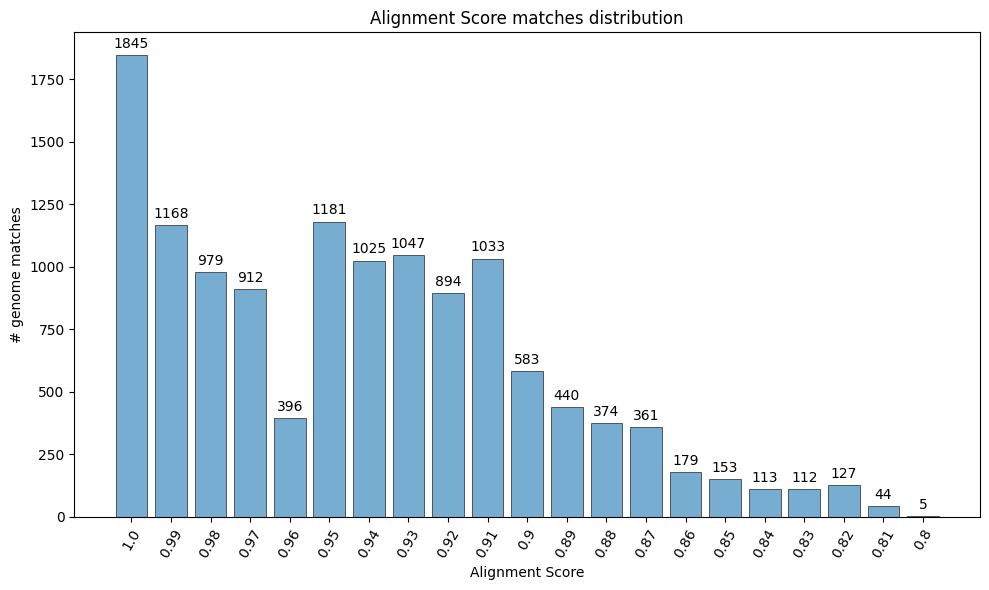

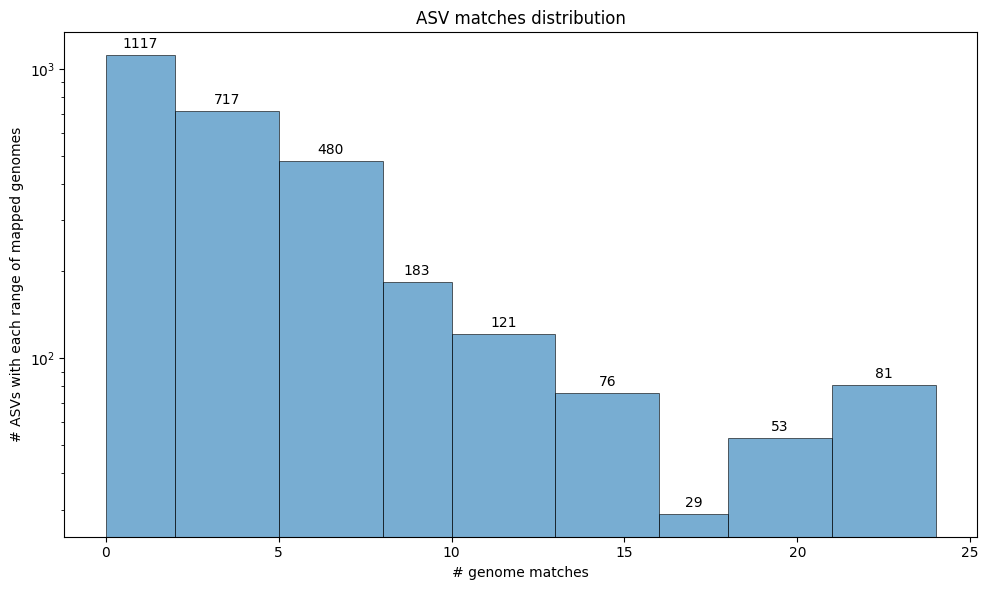

In [17]:
matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))

# examining matches per score
scoreMatches = {}
ASVMatches = {}
for ASV, content in matches_to_get.items():
    ASVMatches.setdefault(ASV, [])
    for score, md5s in content.items():
        ASVMatches[ASV].extend(md5s)
        scoreMatches.setdefault(score, [])
        scoreMatches[score].extend(md5s)

print(list(ASVMatches.items())[:2])

import matplotlib.pyplot as plt
from numpy import log10, logspace, linspace

dics = {"Alignment Score": scoreMatches, "ASV": ASVMatches}
for kind, dic in dics.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    dic = {k: len(v) for k,v in dic.items()}
    if kind == "Alignment Score":
        dic = dict(sorted(dic.items(), key=lambda x: float(x[0]), reverse=True))
        # dic = {k: len(v) for k,v in dict(sorted(dic.items(), key=lambda x: float(x[0]), reverse=True)).items()}
        total = sum(dic.values())
        for i, (score, matches) in enumerate(dic.items()):
            print(score, sum(list(dic.values())[:i+1])/total)
        bars = ax.bar(list(dic.keys()), list(dic.values()), alpha=0.6, edgecolor='black', linewidth=0.7)
        ax.set_xlabel(kind)
        ax.set_ylabel('# genome matches')
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
        plt.xticks(rotation=60)
    elif kind == "ASV": 
        # for i, (label, values) in enumerate(dic.items()):
        # bins = [int(x) for x in logspace(0, log10(max(list(dic.values()))), 10)]
        bins = [int(x) for x in linspace(0, max(list(dic.values())), 10)]
        n, bins, patches = ax.hist(dic.values(), bins=bins, alpha=0.6, edgecolor='black', linewidth=0.7)
        ax.set_ylabel("# ASVs with each range of mapped genomes")
        ax.set_xlabel('# genome matches')
        ax.set_yscale('log')
        ax.bar_label(patches, fmt='%d', padding=3, fontsize=10)
        # This is the magic part:
        # ax.set_xscale('log')
        # ax.xaxis.set_major_formatter(plt.ScalarFormatter())   # show numbers, not 10^ 
        # ax.xaxis.set_minor_formatter(plt.ScalarFormatter())
        # ax.ticklabel_format(style='plain', axis='x') #, rotation=60)      # avoid scientific notation
    ax.set_title(f'{kind} matches distribution')
    # ax.legend()
    plt.tight_layout()
    plt.savefig(f'modeling_files/{kind}_distributions.png')
    plt.show()

# Pulling matched genomes from BV-BRC

## Determine ASVsets

In [18]:
from collections import Counter
from numpy import mean, std, array
from pandas import DataFrame
from json import load
from itertools import chain

matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
IDmatches = {ID: list([x for y in matches.values() for x in y]) for ID, matches in matches_to_get.items()}
overlapping = {}
combining = {}
zeros = []
included = []
threshold = 0.2
for ID, matches in IDmatches.items():
    overlapping.setdefault(ID, {})
    for ID2, matches2 in IDmatches.items():
        if ID2 == ID or ID2 in overlapping.keys(): continue # or ID2 in included:   continue
        if len(set(matches)) == 0:  zeros.append(ID)  ;  continue
        if len(set(matches2)) == 0:  zeros.append(ID2)  ;  continue
        overlapping[ID][ID2] = len(set(matches) & set(matches2)) / len(set(matches) | set(matches2))
        if overlapping[ID][ID2] >= threshold:
            # print(ID, ID2, overlapping[ID][ID2])
            combining.setdefault(ID, [])
            combining[ID].append(ID2)
            # included.append(ID2)

# allocate an ASV to its best hitting ASVset
inverted_best = {}
for ID1, ID2s in combining.items():
    for ID2 in ID2s:
        score = overlapping.get(ID1, {}).get(ID2, float('-inf'))
        if score > overlapping.get(inverted_best.get(ID2, ''), {}).get(ID2, float('-inf')):
            inverted_best[ID2] = ID1
combining = {}
for ID2, ID1 in inverted_best.items():
    combining.setdefault(ID1, []).append(ID2)
    
combining_lengths = [len(v) for k,v in combining.items()]
print("ASVset stats:", round(mean(combining_lengths), 2), "+/-", round(std(combining_lengths), 2), "max", max(combining_lengths))
# display(combining)
dump(combining, open("modeling_files/ASV_sets.json", 'w'), indent=3)

print(len(zeros), len(set(zeros)), set(zeros))
overlapping_df = DataFrame.from_dict(overlapping)
overlaps = overlapping_df.to_numpy().flatten()
overlaps = overlaps[overlaps > 0]
# display(dict(sorted(Counter(overlaps).items(), key=lambda item: item[1], reverse=True)))
counted = dict(sorted(Counter(overlaps).items(), key=lambda item: item[0], reverse=True))
display(counted)
# print(round(mean(overlaps), 2), round(std(overlaps), 2), max(overlaps))

ASVset stats: 1.94 +/- 2.01 max 32
107825 38 {'2c76f558846fa9aa57c59ddacefeacb2', 'a012a92141e089dd0e178bc46889f8bd', '36f3b6d6951a802a6906a07bed8168bb', '26cbd70e0eb0b0a14e93c0970b305ef1', '6a639263c07c310881a6085392276536', 'd3648f626f4aadacf25eb043bdc62c58', '245b33b8928a2d472035cfcc336caddb', '26c822a9da99f48bc5eabddbeda2a1e8', '1f42391a983ba3af940e541d110a8432', '92862fbe6ff344c8964156b2a0b424cc', '475578087d74506dfa16ebf79e182c28', '60ec6b41425f294ba92e7b2f8cc23289', '0674e7934525d446c54c31dc9b8e33d5', '172df84126559d3703a3b6184b45a0ee', '822e596ebee53d4dcd5ffe3e26ec43d4', '2c8630b0baf30f2cc97a2f0b4bc96aca', '608bdffdf9263f1b123d069d10e69f9a', 'ad7b37d7259f65ae5d2d898c539a6297', '03a6a6d84a7be4b11b6467c91ca79d57', 'c2b43f5fc401b8ae942e9f83213eef32', '02541e05438ebd6cd913200972ef5e4b', '72c6706063e2325bd12c28ea8b23e872', 'df24931eef177828ec0d0b347ec6cf02', '6e252cae9e8ff5755e0cfa5c52a78beb', '593b39ccba286d62eba7872e07c45354', 'e61e6021af25969dd347b921fc6389a4', '46bd23bd0fd9dba10

{np.float64(1.0): 1778,
 np.float64(0.9333333333333333): 1,
 np.float64(0.9): 1,
 np.float64(0.8888888888888888): 7,
 np.float64(0.8823529411764706): 1,
 np.float64(0.875): 35,
 np.float64(0.8571428571428571): 48,
 np.float64(0.8333333333333334): 80,
 np.float64(0.8181818181818182): 7,
 np.float64(0.8076923076923077): 1,
 np.float64(0.8): 21,
 np.float64(0.7894736842105263): 1,
 np.float64(0.7857142857142857): 1,
 np.float64(0.7777777777777778): 10,
 np.float64(0.75): 179,
 np.float64(0.7368421052631579): 1,
 np.float64(0.7272727272727273): 10,
 np.float64(0.7142857142857143): 101,
 np.float64(0.7058823529411765): 1,
 np.float64(0.7): 32,
 np.float64(0.6923076923076923): 1,
 np.float64(0.6875): 3,
 np.float64(0.6666666666666666): 194,
 np.float64(0.6538461538461539): 1,
 np.float64(0.6470588235294118): 1,
 np.float64(0.6428571428571429): 3,
 np.float64(0.6363636363636364): 17,
 np.float64(0.631578947368421): 2,
 np.float64(0.6296296296296297): 1,
 np.float64(0.625): 97,
 np.float64(0.6

In [16]:
from json import load, dump
from numpy import mean, std, array

matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
IDmatches = {ID: list([x for y in matches.values() for x in y]) for ID, matches in matches_to_get.items()}

ASV_sets = load(open("modeling_files/ASV_sets.json", 'r'))
redunant_asvs = {v:k for k,vs in ASV_sets.items() for v in vs}

# NOTE: This captures ASVsets
md5_ID = load(open("model_inputs/16S_md5_ID.json", 'r'))
ASV_genomes, ASV_genomeIDs = {}, {}
for ASV, contents in matches_to_get.items():
    ASV_genomes.setdefault(redunant_asvs.get(ASV, ASV), []).extend([x for xs in contents.values() for x in xs])
    ASV_genomeIDs.setdefault(redunant_asvs.get(ASV, ASV), []).extend(
        [md5_ID[x].split("|")[1].split(".rna")[0] for xs in contents.values() for x in xs])
print(list(ASV_genomes.items())[0], "\n\n")
dump(ASV_genomes, open("modeling_files/ASV_genomes.json", 'w'), indent=2)
dump(ASV_genomeIDs, open("modeling_files/ASV_genomeIDs.json", 'w'), indent=2)
    
print(len(redunant_asvs), len(redunant_asvs)/len(ASV_sets), mean(list(map(len, ASV_sets.values())))) #, redunant_asvs)
print(len(set(redunant_asvs)), f"ASVs are redundant, from", len(IDmatches), "total, and will be combined into", len(ASV_sets),
      "ASVsets, which will result in", len(IDmatches)-len(ASV_sets), len(ASV_genomes), "unique ASVs")
list(ASV_sets.items())[:2]

('0fec351445f84bd482075ceda6123f46', ['8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba', '8919b57c55462472be46d7f4558dc68f', '271534eefd04da5c51a9f5523a87a45d', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', '27fee1316bda01e72e5e087721ee5d82', 'f19e6bdd5844ed3cb29bb1ebf488c149', '64300e7cd4d4a22317770eb0e63020ba', '8919b57c55462472be46d7f4558dc68f', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', 'f19e6bdd5844ed3cb29bb1ebf488c149', '8919b57c55462472be46d7f4558dc68f', 'e2868484d4a7db6de599887368eba1c0', '17c560e843b457ca17880fb276a00b52', 'f19e6bdd5844ed3cb29bb1ebf488c149', '33694ba394cb9bcdf5d83c55b14549ad', '273846522f3916e1b62aa5f67ddb0006', '271534eefd04da5c51a9f5523a87a45d', '27fee1316bda01e72e5e087721ee5d82', '6a71bd4cf6652e8da42eb63ed

[('0fec351445f84bd482075ceda6123f46',
  ['2c1453fb27de0eb5e19ae61028df3294',
   '534d7b1bce2cf035866320576094f81e',
   '136c27e1efa2b99fb71cdff938615daa',
   '0e941c919146c9d562604083a4eeadc8',
   '1d808a941e29c1b4f33534431001dd27']),
 ('534d7b1bce2cf035866320576094f81e',
  ['9e67f564a732feffc50f5fc690ec2e71',
   'b4ac0621ed68fda2b501520e951949e1',
   'c6d0e484e529a485ffc0b1f08f1fb158',
   'c1795fae23a34030462cf6e6267b85b3',
   'a214ccee6e9a8749c048daa053ae51dc',
   '4e39e7f278e094156ebfcc28868dd7dd',
   'e04d49b3a01d91878d1c27f4e22b074e',
   '3ab03e560dde34c45b0a4e71c809c190',
   '48583aa878619934f2f6d8583cccae68',
   '50f6937d35cf193c1881b6fb7c273225',
   'a049ac86c03db7991ef693a1bb025681',
   '7c6299b064794dfea9e563a4645d1bbf',
   'b513381a51c3d1b0d7e568a804954430',
   '270c5d9a2223e0f5d99547e426bc19e4',
   '5c52186b7c44d5709af099adc5dea216',
   '5b02c8639023ea8693ddee6bf1597c70',
   '85a27e670e0e57e67484195e26028b19',
   'be437fdb39ff4822fcaf0522cbd7c1e0',
   '451f992938efa5e0c6523

In [20]:
from json import load, dump

abundances = load(open("model_inputs/abundances.json", 'r'))
ASVset_abundances = {}
skipping, not_skipping = [], []
for sample, content in abundances.items():
    ASVset_abundances[sample] = {}
    for ID, abundance in content.items():
        if abundance < 0.001:
            skipping.append(ID)
            # print(f"skipping {ID} in {sample} with {abundance} abundance")
            continue
        not_skipping.append(ID)
        primaryASV = redunant_asvs.get(ID, ID)
        ASVset_abundances[sample].setdefault(primaryASV, 0)
        ASVset_abundances[sample][primaryASV] += abundance
    # print(len(content), len(ASVset_abundances[sample]))
print(len(skipping), "ASVs were skipped, and", len(not_skipping), "were not skipped")
dump(ASVset_abundances, open("modeling_files/ASVset_abundances.json", 'w'))

46794 ASVs were skipped, and 7489 were not skipped


## visualizing ASVset data

### genome mapping distribution

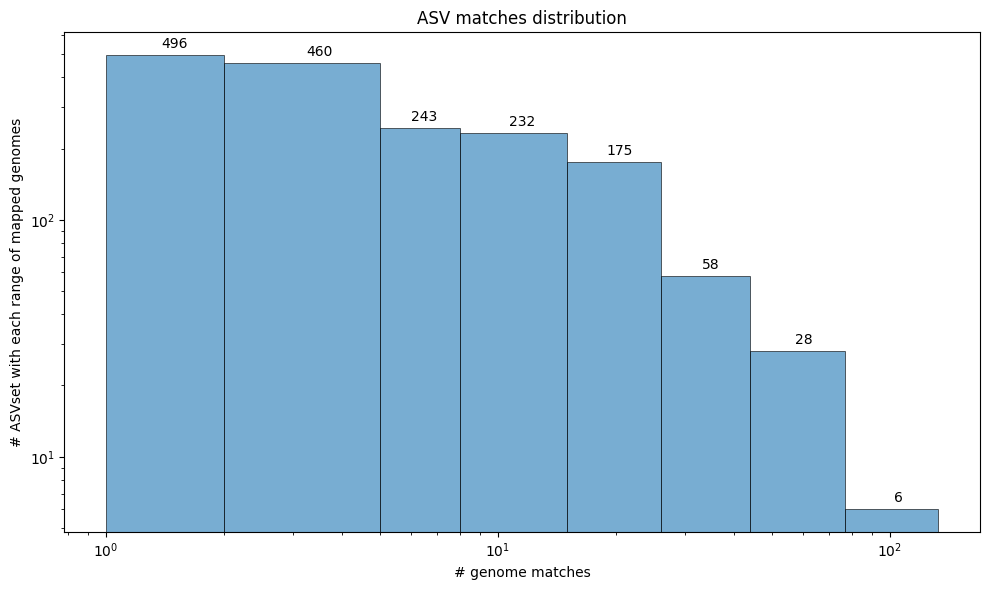

In [21]:
import matplotlib.pyplot as plt
from numpy import linspace
from json import load

ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
dic = {k: len(v) for k,v in ASV_genomes.items()}
bins = [int(x) for x in logspace(0, log10(max(list(dic.values()))), 10)]
fig, ax = plt.subplots(figsize=(10, 6))
# bins = [int(x) for x in linspace(0, max(list(dic.values())), 10)]
n, bins, patches = ax.hist(dic.values(), bins=bins, alpha=0.6, edgecolor='black', linewidth=0.7)
ax.set_ylabel("# ASVset with each range of mapped genomes")
ax.set_xlabel('# genome matches')
ax.set_yscale('log')
ax.set_xscale('log')
ax.bar_label(patches, fmt='%d', padding=3, fontsize=10)
ax.set_title(f'{kind} matches distribution')
# ax.legend()
plt.tight_layout()
plt.savefig(f'modeling_files/ASVset_distributions.png')
plt.show()

### abundance distribution

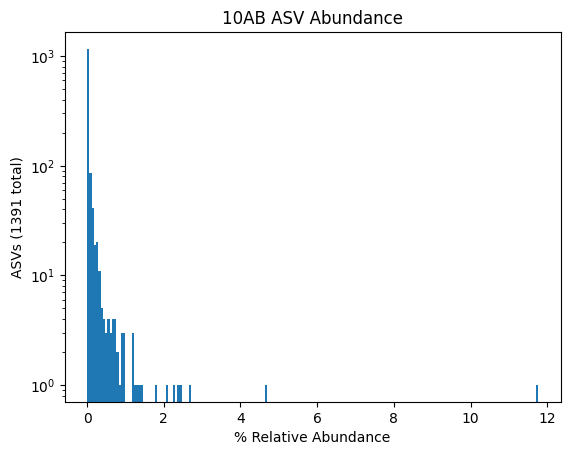

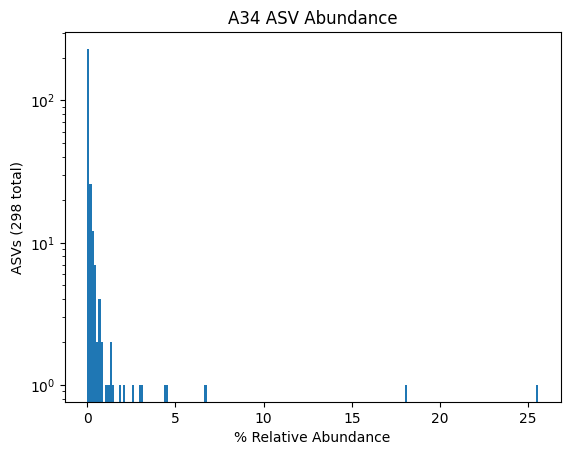

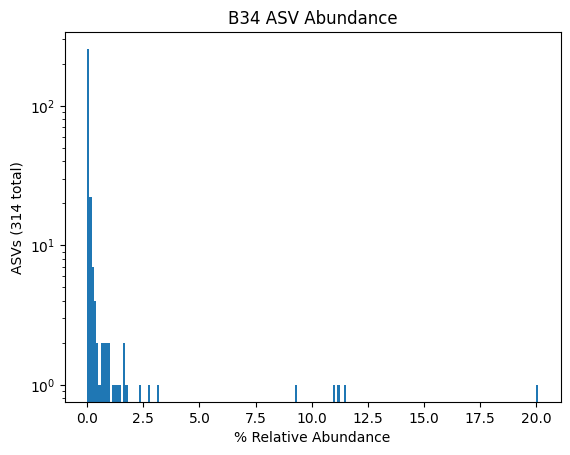

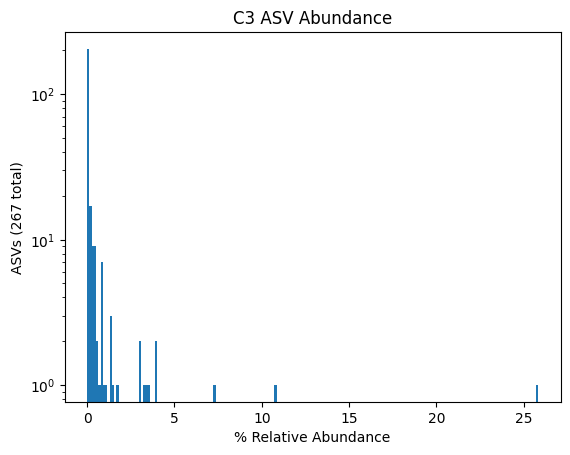

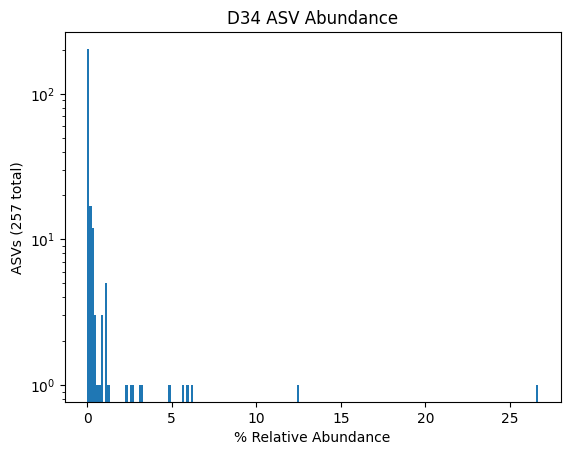

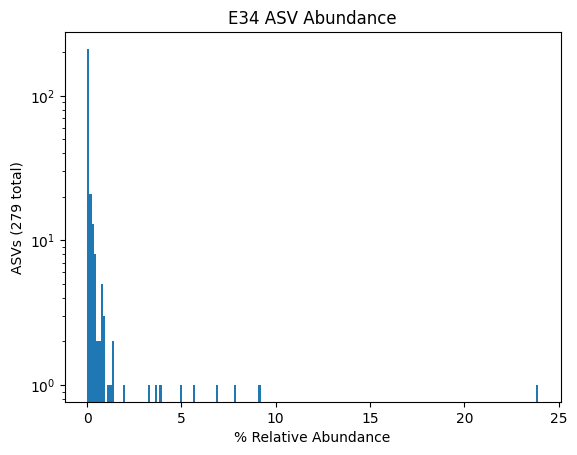

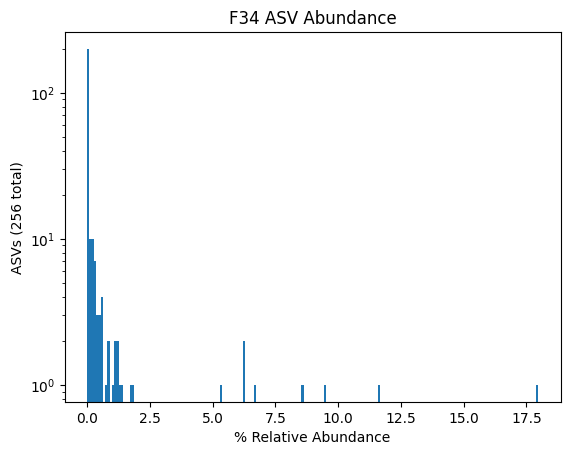

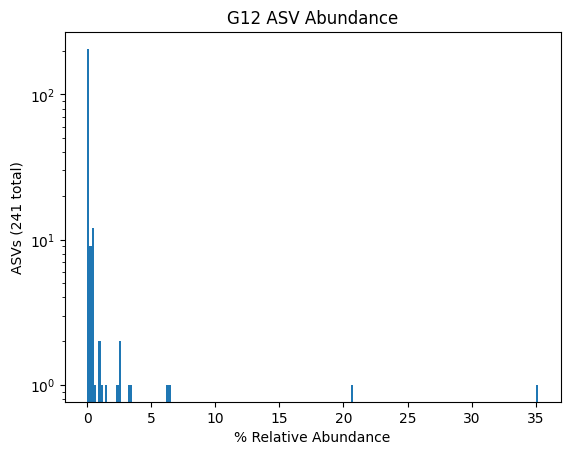

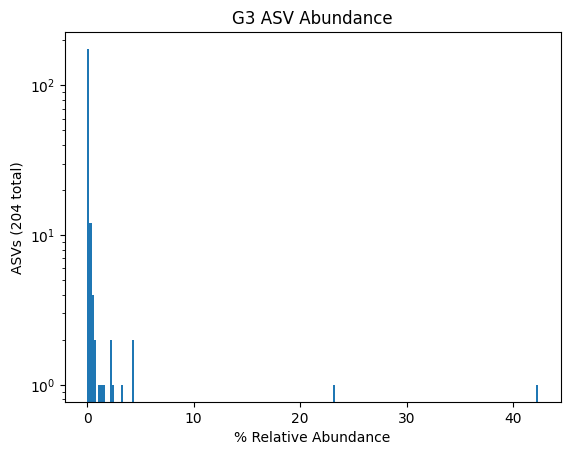

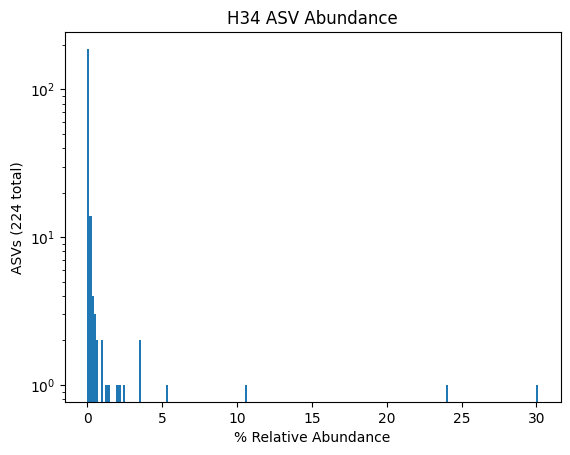

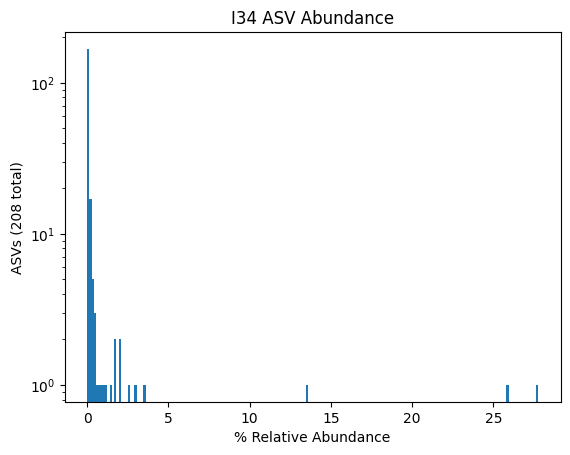

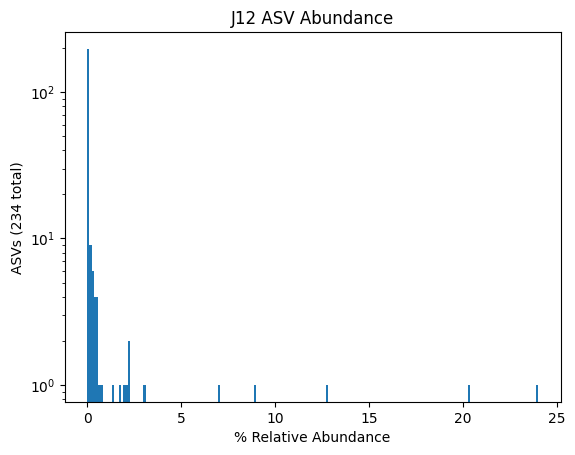

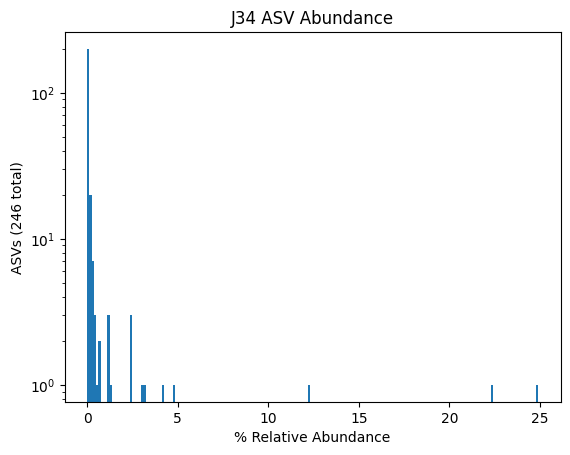

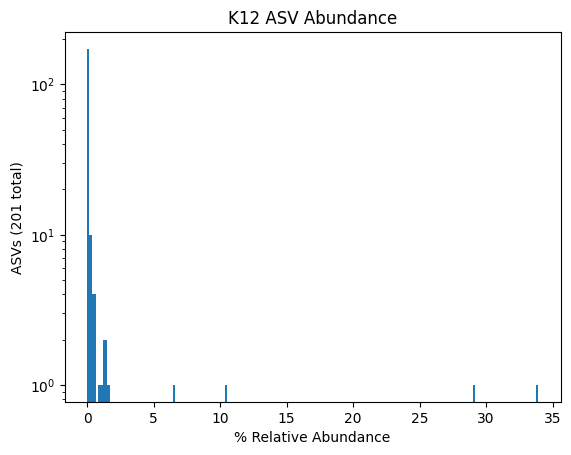

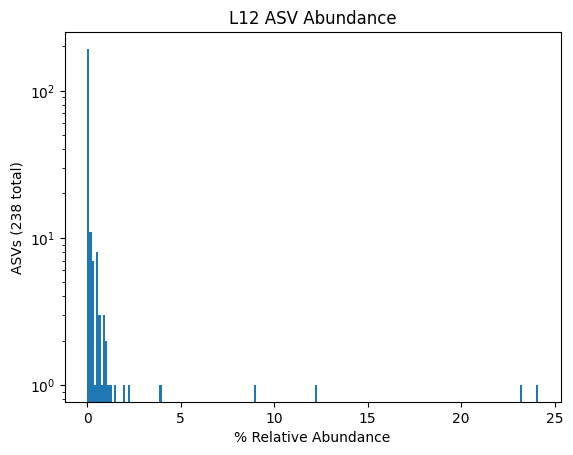

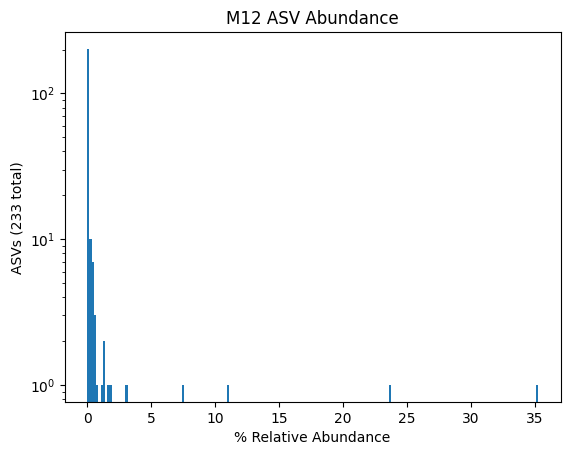

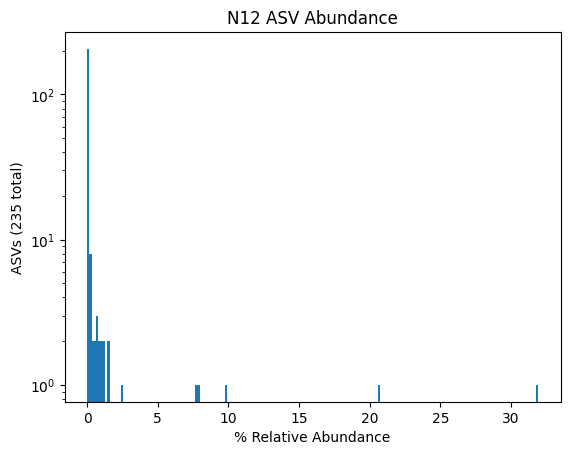

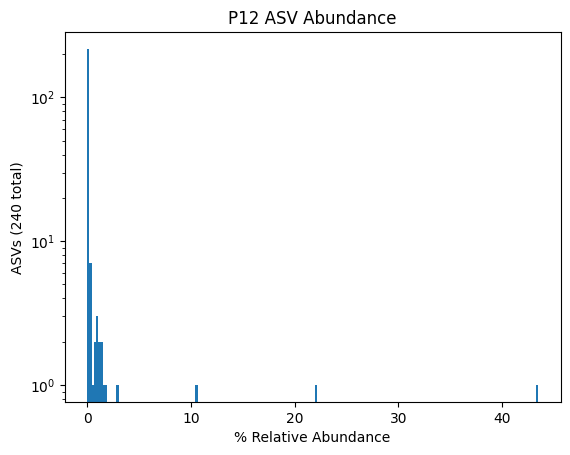

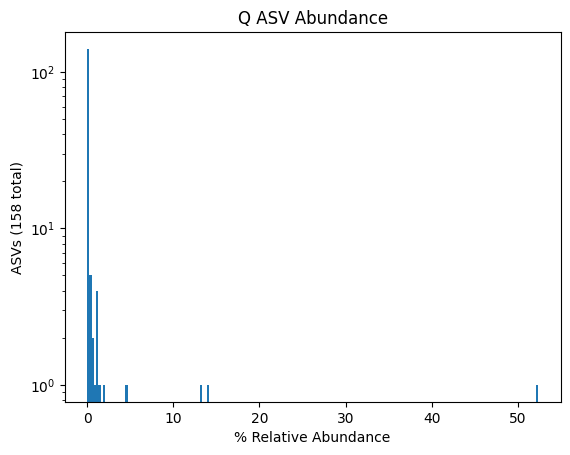

In [22]:
import matplotlib.pyplot as plt
from json import load

ASVset_abundances = load(open("modeling_files/ASVset_abundances.json", 'r'))
for sample, content in ASVset_abundances.items():
    # print(sample)
    abundances = [x for x in list(content.values()) if x > 0]
    plt.hist(abundances, bins=200)

    # Add labels and title
    plt.xlabel('% Relative Abundance')
    plt.ylabel(f'ASVs ({len(abundances)} total)')
    plt.yscale('log')
    plt.title(f'{sample} ASV Abundance')

    # Display the plot
    plt.savefig(f'abundance_distributions/{sample}_ASVset_abundance.png')
    plt.show()

# downloading genomes and features

In [2]:
from json import load,dump
from tqdm import tqdm
import urllib.parse as parse
import requests
import time, os

md5_ID = load(open("model_inputs/16S_md5_ID.json", 'r'))
# ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
ASV_genomeIDs = load(open("modeling_files/ASV_genomeIDs.json", 'r'))
all_genomes = set([g for ASV, IDs in ASV_genomeIDs.items() for g in IDs])
print(len(all_genomes), "total genomes")

empty = []

# for genomeID in tqdm(all_genomes, total=len(all_genomes)):
def pull_content(genomeID):
    # genomeID = genomeID.split("|")[1].split(".rna")[0]
    
    # Metadata (Taxonomy)
    url_genomeID = parse.quote(genomeID, safe='')
    if os.path.exists(f"genome_metadata/{genomeID}.json"):
        return
    genome_url = (f"https://www.bv-brc.org/api/genome/"
                f"?eq(genome_id,{url_genomeID})")
                # "&select(kingdom,phylum,class,order,family,genus,species)"
                # "&limit(20000)&http_accept=application/json")
    try:
        genome = requests.get(genome_url).json()
    except:
        try:
            # Wait 5 seconds
            time.sleep(2)
            genome = requests.get(genome_url).json()
        except:
            print(f"The {genomeID} features page cannot opened again")
            return #continue
    dump(genome[0], open(f"genome_metadata/{genomeID}.json", 'w'))
    
    # Genome sequence
    if os.path.exists(f"genomes/{genomeID}.fna"):
        return #continue
    # print(genomeID, url_genomeID)
    url = (
        "https://www.bv-brc.org/api/genome_sequence/"
        f"?eq(genome_id,{url_genomeID})"
        "&select(accession,sequence)"
        "&limit(100000)"
    )
    r = requests.get(url, headers={"Accept": "application/json"})
    try:
        r.raise_for_status()
    except:
        print(f"The {genomeID} genome page cannot open: {r.url}")
        try:
            r = requests.get(url, headers={"Accept": "application/json"})
        except:
            print(f"The {genomeID} genome page cannot open again")
            return #continue
    # print(r.text)
    content = r.json()
    if not content:
        empty.append(genomeID)
    display([x.keys() for x in content])

    ## Write FASTA
    with open(f"genomes/{genomeID}.fna", "w") as out:
        for c in content:
            # print(c)
            out.write(f">{c['accession']}\n{c['sequence']}\n")

    # Features
    if os.path.exists(f"features/{genomeID}.json"):
        # print("existing features")
        return #continue
    feat_url = (f"https://www.bv-brc.org/api/genome_feature/"
                f"?eq(genome_id,{genomeID})"
                "&select(patric_id,pgfam_id,plfam_id,figfam_id,product,feature_type,annotation)"
                "&limit(20000)&http_accept=application/json")
    try:
        feats = requests.get(feat_url).json()
    except:
        try:
            # Wait 5 seconds
            time.sleep(2)
            feats = requests.get(feat_url).json()
        except:
            print(f"The {genomeID} features page cannot opened again")
            return #continue
    dump(feats, open(f"features/{genomeID}.json", 'w'))


parallelize = False
if parallelize:
    # parallelize the effort
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(pull_content, all_genomes)
else:
    for ID in tqdm(all_genomes):
        output = pull_content(ID)
        # print(output)
        # break

5430 total genomes


100%|██████████| 5430/5430 [11:43<00:00,  7.71it/s]   


In [9]:
# from glob import glob 
# from json import load

# features = glob(f"features/*.json")
# missing_features = []
# for path in features:
#     genomeID = path.split("/")[-1].replace(".json", '')
#     if genomeID not in all_genomes:
#         missing_features.append(genomeID)
# print(len(missing_features), "are extra from", len(features), "features")

# genomes = glob(f"genomes/*.fna")
# missing_genomes = []
# for path in genomes:
#     genomeID = path.split("/")[-1].replace(".fna", '')
#     if genomeID not in all_genomes:
#         missing_genomes.append(genomeID)
# print(len(missing_genomes), "are missing from", len(genomes), "genomes")

# print(set(missing_features).symmetric_difference(set(missing_genomes)))

## determining feature probabilities

In [3]:
from collections import Counter
from glob import glob
from json import load
from numpy import mean

ASV_genomeIDs = load(open("modeling_files/ASV_genomeIDs.json", "r"))
# no_features = []
# errors = []
for att in ["product", "pgfam_id", "plfam_id"]:
    probabilities = {}
    maxes = []
    for ASV, IDs in ASV_genomeIDs.items():
        probabilities[ASV] = []
        features = []
        hits = len(IDs)
        for ID in IDs:
            genome_path = f"features/{ID}.json"
            if not os.path.exists(genome_path):
                print("missing", genome_path)
                continue
            with open(genome_path, 'r') as json_file:
                try:
                    feats = set([f.get(att, None) for f in load(json_file)])
                    feats.remove(None)
                    features.extend(list(feats))
                except Exception as e:
                    # errors.append((genomeID, str(e)))
                    # print(f"Error loading features for {genomeID}: {e}")
                    pass
    
        counted = Counter(features)
        probabilities[ASV] = {k:v/hits for k,v in counted.items()}
        if len(probabilities[ASV]) == 0:
            # no_features.append(amplicon)
            continue
        # print(list(probabilities[amplicon].values())[:5])
        maxes.append(max(probabilities[ASV].values()))
        # print(amplicon, hits, len(features), max(probabilities[amplicon].values()), min(probabilities[amplicon].values()))
        # break
    
    dump(probabilities, open(f"modeling_files/{att}_probabilities.json", 'w'), indent=2)

product_probabilities 8219463 total entries
mean product_probabilities probability 0.47 +/- 0.37 ; range 0.01 - 1.0

pgfam_id_probabilities 6408022 total entries
mean pgfam_id_probabilities probability 0.44 +/- 0.39 ; range 0.01 - 1.0

plfam_id_probabilities 5474107 total entries
mean plfam_id_probabilities probability 0.29 +/- 0.32 ; range 0.01 - 1.0



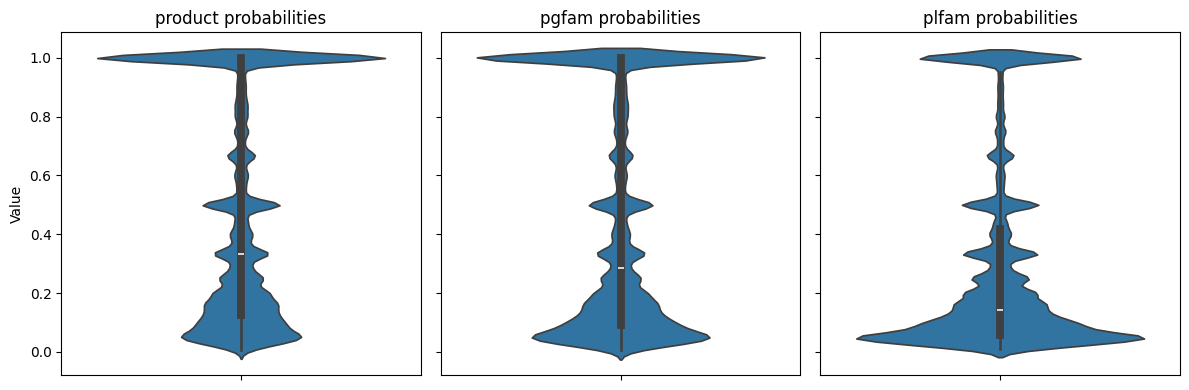

In [4]:
import matplotlib.pyplot as plt
from json import load, dump
from numpy import mean, std
from numpy import array
from glob import glob
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, prob_path in enumerate(glob(f"modeling_files/p*_probabilities.json")):
    f = load(open(prob_path, 'r'))
    att = prob_path.split("/")[-1].split(".")[0]
    probs = [p for ASV,v in f.items() for enzyme, p in v.items()]
    
    print(att, len(probs), "total entries")
    print(f"mean {att} probability", round(mean(probs),2), "+/-", round(std(probs),2),
          "; range", round(min(probs),2), "-", round(max(probs),2))
    print()

    # Create subplots
    sns.violinplot(y=probs, ax=axes[i])
    axes[i].set_title(f"{att.replace('_', ' ').replace('id ', '')}")
    # axes[i].set_xlabel("")
    # axes[i].set_ylabel("")

axes[0].set_ylabel("Value")  # only left-most gets y-label
plt.tight_layout()
plt.savefig("modeling_files/probability_distributions")
plt.show()

### Processing protein family probabilities

# creating synthetic genomes

In [2]:
from collections import Counter
from json import dump, load
midas_taxonomy = load(open("model_inputs/taxonomy.json",'r'))

# ASV_genera = {ASV: taxa["Genus"] for ASV, taxa in midas_taxonomy.items()}
# display(ASV_genera)
# display({k:v for k,v in Counter(ASV_genera.values()).most_common() if v > 2})
genera_counts = Counter([x["Genus"] for x in midas_taxonomy.values()]) 
display({k:v for k,v in genera_counts.most_common() if v > 2})

# TODO: should ASVs that map to the same Genus be combined?
## literature suggests that metabolism is only related to this level

# create an iterative counted name for each ASV according to redundant Genuses
iterativeIDs = {}
for ASV, taxa in midas_taxonomy.items():
    best_level = "Kingdom"
    for level, taxon in taxa.items():
        # print(level, taxon)
        if not isinstance(taxon, str) or level == "Species":
            break
        best_level = level
    # if not isinstance(genus, str):  continue
    taxon = taxa[best_level]
    # print(best_level, taxon)
    taxon += ".1"
    while taxon in iterativeIDs:
        taxon, count = taxon.split(".")
        taxon = f"{taxon}.{int(count)+1}"
    # print(genus)
    iterativeIDs[taxon] = ASV

# iterativeIDs = {ASV: taxa["Genus"] + "_" + str(Counter(ASV_genera.values()).most_common().index(taxa["Genus"])) for ASV, taxa in midas_taxonomy.items()}
iterativeIDs = {v:k for k,v in iterativeIDs.items()}
display(list(iterativeIDs.items())[:5])
dump(iterativeIDs, open("modeling_files/iterativeIDs.json", 'w'))

{nan: 537,
 'Methanobacterium': 100,
 'Christensenellaceae_R-7_group': 94,
 'Syntrophomonas': 28,
 'Proteiniphilum': 22,
 'Petrimonas': 20,
 'Ruminiclostridium': 20,
 'Legionella': 20,
 'Sedimentibacter': 20,
 'Lentimicrobium': 19,
 'Caldicoprobacter': 19,
 'Hyphomicrobium': 17,
 'Anaerovorax': 16,
 'Alcaligenes': 16,
 'Dethiobacter': 16,
 'Bacillus': 16,
 'midas_g_75908': 16,
 'Syner-01': 15,
 'Mycobacterium': 15,
 'Neochlamydia': 15,
 'HN-HF0106': 15,
 'Monoglobus': 14,
 'Ercella': 13,
 'Aminivibrio': 12,
 'Microbacterium': 12,
 'midas_g_1799': 12,
 'Desulfosporosinus': 11,
 'Clostridium_sensu_stricto_1': 11,
 'JGI-0000079-D21': 10,
 'Gordonia': 10,
 'Leucobacter': 10,
 'Paracoccus': 10,
 'Devosia': 10,
 'midas_g_249': 10,
 'Erysipelothrix': 9,
 'Thermovirga': 9,
 'Oscillibacter': 9,
 'Pirellula': 9,
 'Desulfitibacter': 9,
 'Terrisporobacter': 9,
 'Lachnoclostridium': 9,
 'Mesotoga': 8,
 'Desulfovibrio': 8,
 'midas_g_36215': 8,
 'Romboutsia': 8,
 'midas_g_98124': 8,
 'Methanosarcina'

[('0fec351445f84bd482075ceda6123f46', 'Methanobacterium.1'),
 ('7f78afb7e1d45cd528fe9cd909c93fb5', 'Methanobacterium.2'),
 ('63f37ee4b481fccdffca10160ed5b944', 'Methanobacteriaceae.1'),
 ('d3cf08daefed96f494257ceff63a6cf8', 'Mesotoga.1'),
 ('c55a8101fb6c187736f0af61f720cb92', 'Lentimicrobium.1')]

## Claude version

[]  have no genomeIDs
2 will be processed
('0fec351445f84bd482075ceda6123f46', ['2202153.375', '2026739.1030', '176233.32', '2164.119', '171292.32', '1915467.3', '3240853.3', '2202153.375', '2026739.1030', '176233.32', '2164.119', '171292.32', '1915467.3', '3240853.3', '2202153.375', '176233.32', '2164.119', '1915467.3', '2202153.375', '176233.32', '2164.119', '1915467.3', '176233.37', '176233.17', '2026739.1030', '171292.32', '2026714.15', '3240853.3', '2202153.375', '2026739.1030', '176233.32', '2164.119', '171292.32', '1915467.3', '3240853.3', '2202153.375', '2026739.1030', '176233.32', '2164.119', '171292.32', '1915467.3', '3240853.3'])
Methanobacterium.1
Methanobacterium.1

Creating synthetic genome: Methanobacterium.1
Successfully loaded 42 source genomes
Aggregating taxonomies from 42 source genomes...

DEBUG for Methanobacterium.1:
Family: ['Methanobacteria', 'Methanobacteriota archaeon', 'Candidatus Bathyarchaeota archaeon', 'Mycobacteriales', 'Thermodesulfobacteriota bacteriu

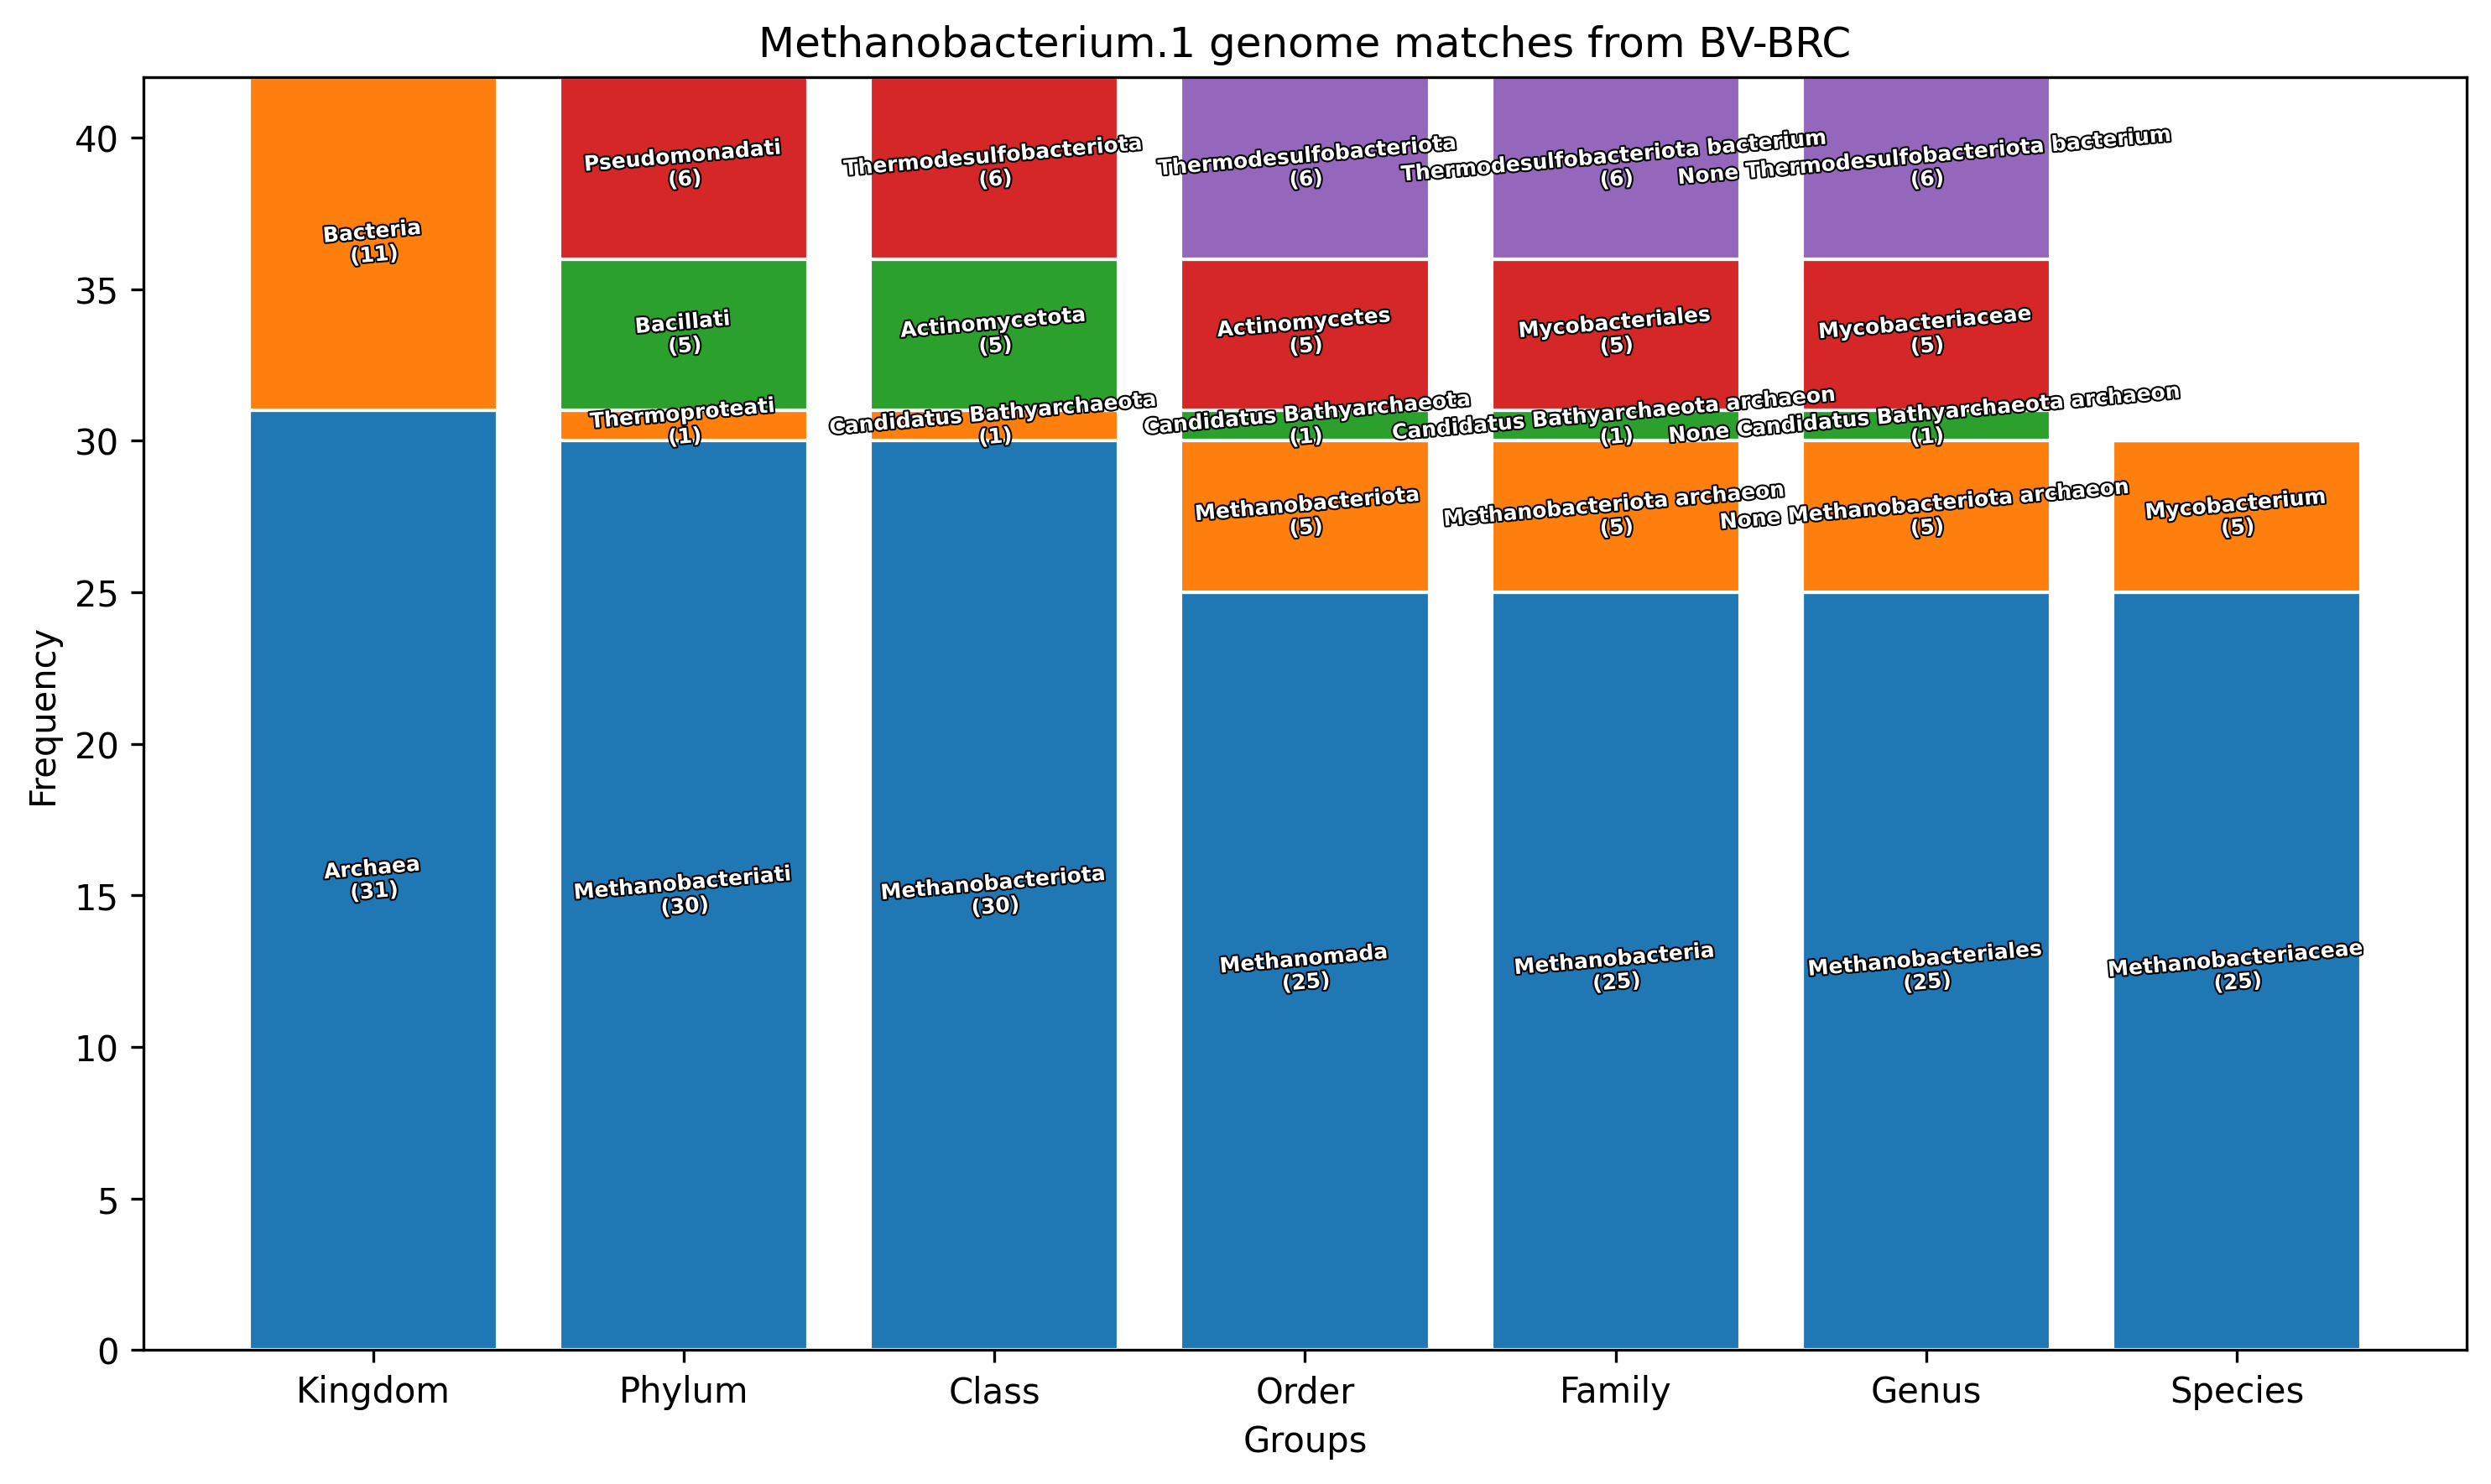

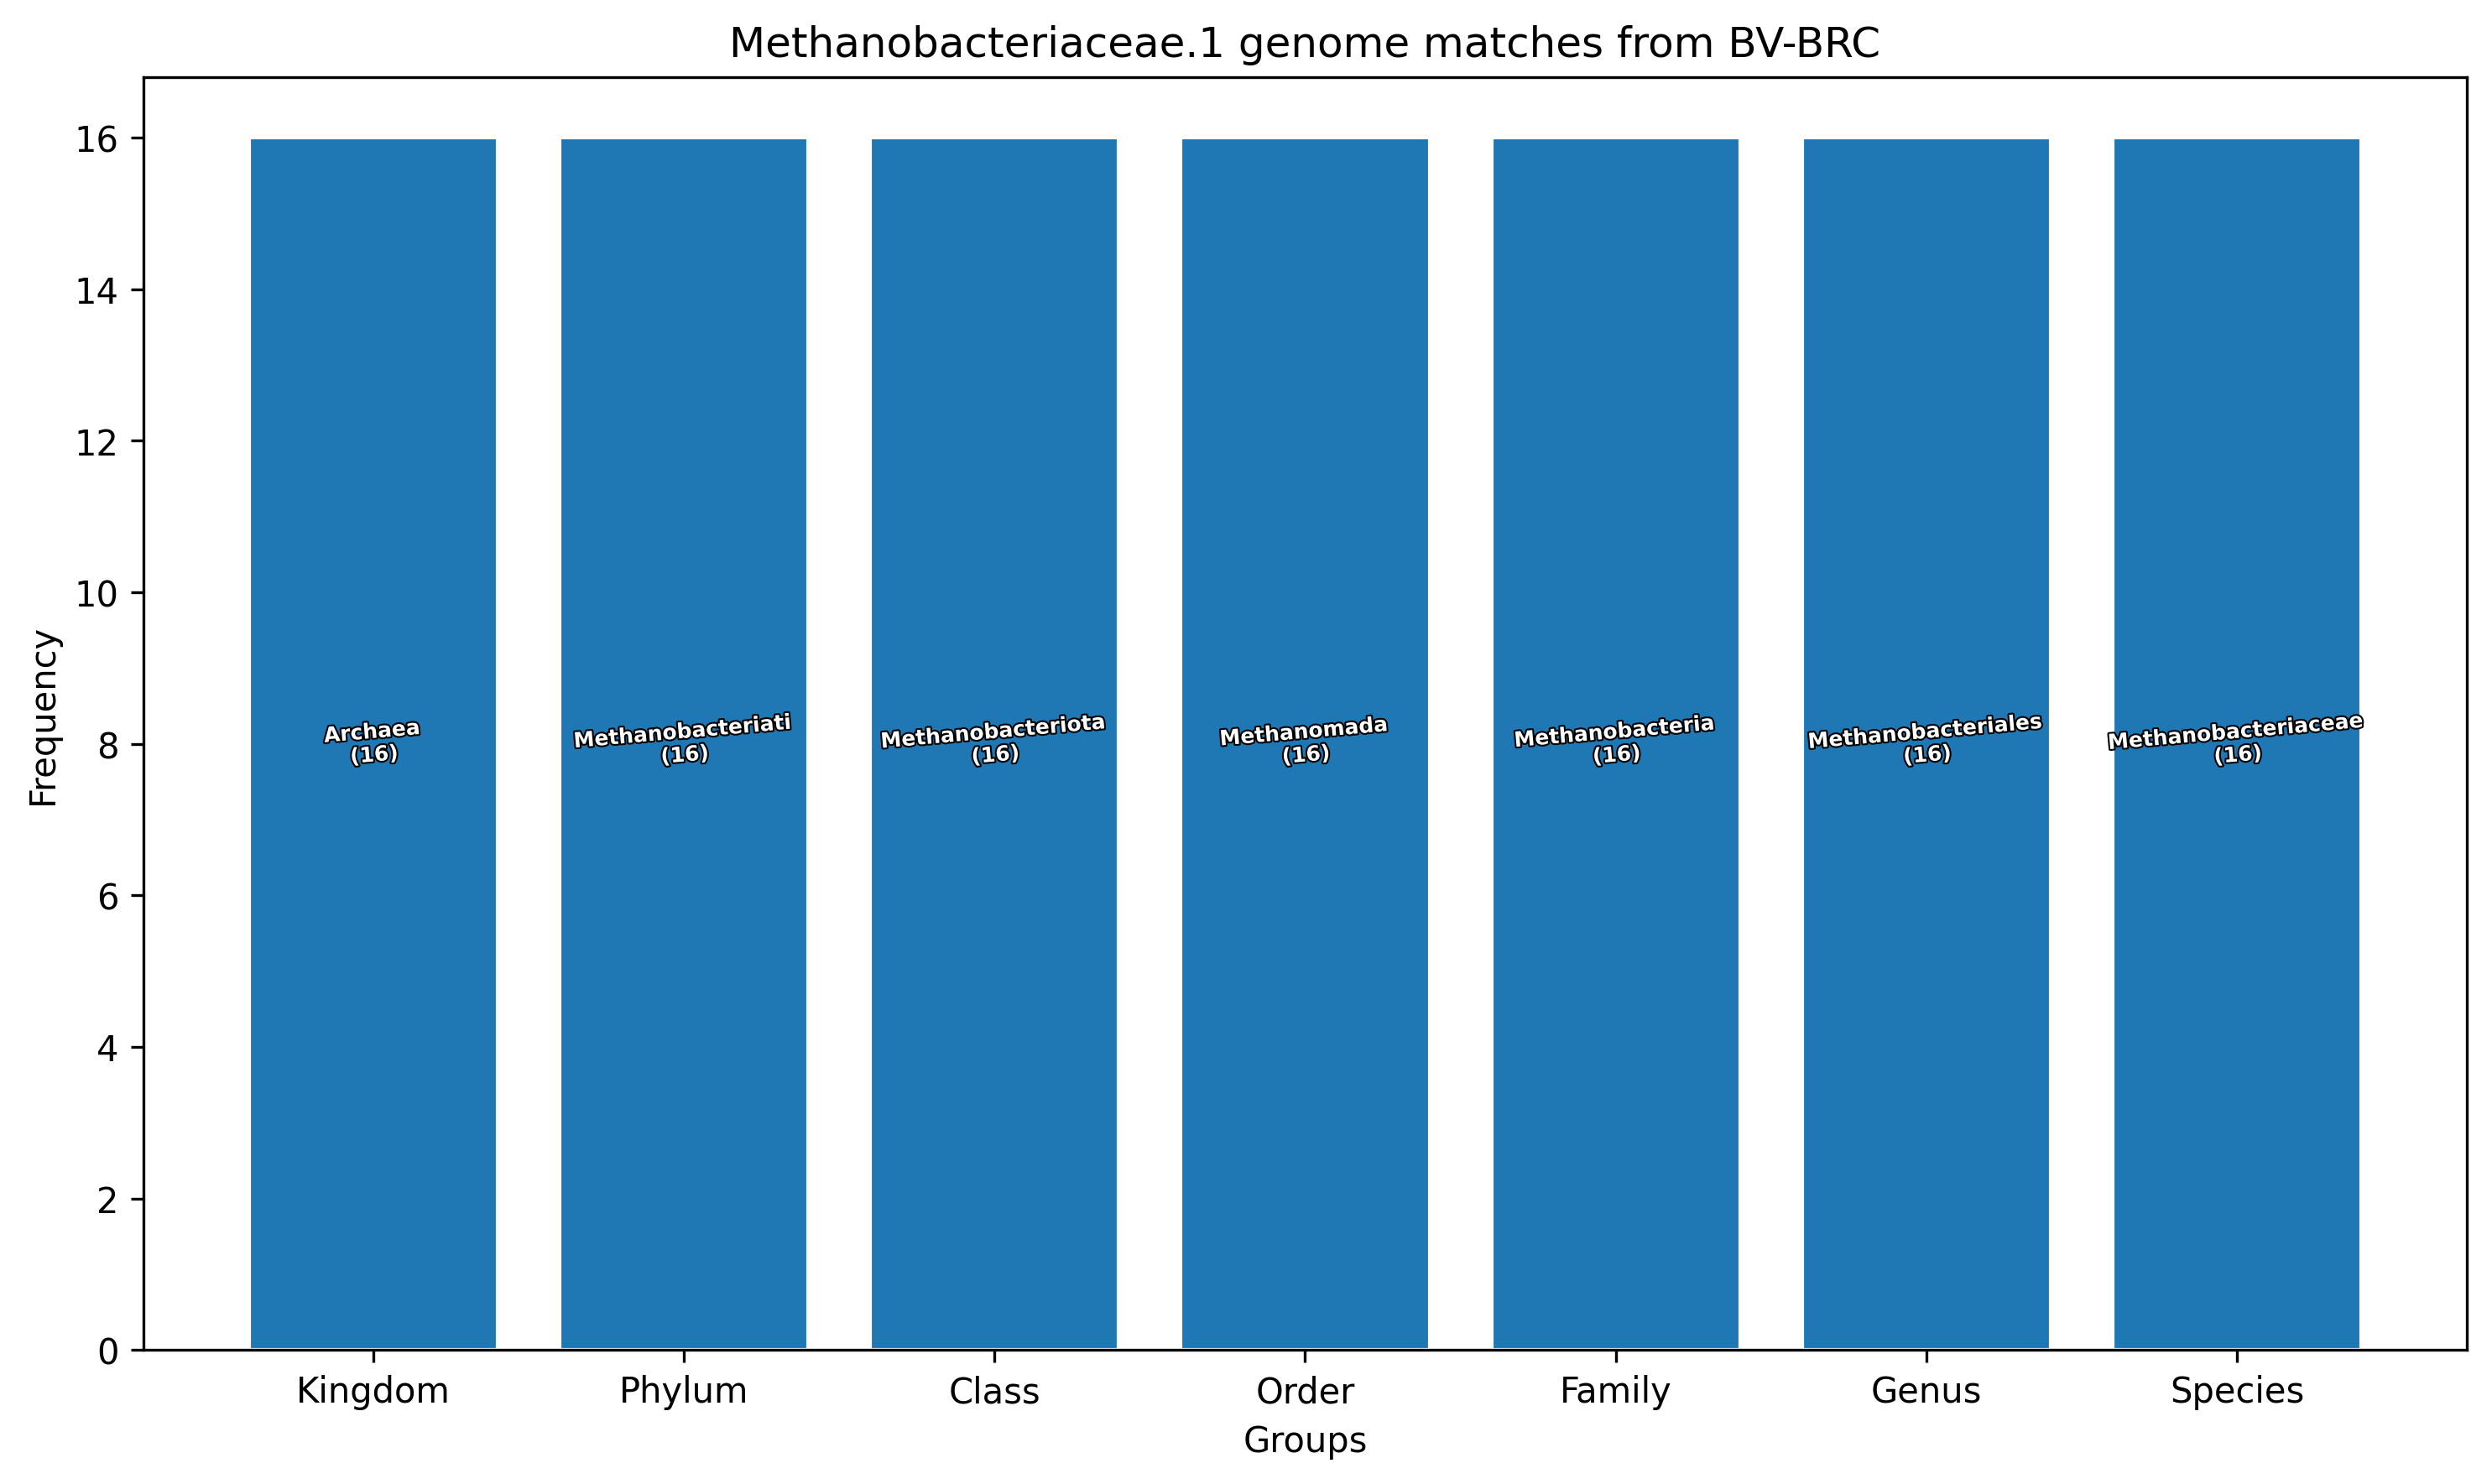

In [4]:
from bvbrc_to_kbase_genome import LocalGenomeConverter
from json import load
import os

ASV_genomeIDs = load(open('modeling_files/ASV_genomeIDs.json', 'r'))
iterativeIDs = load(open('modeling_files/iterativeIDs.json', 'r'))
# ASV_genomes = load(open('modeling_files/ASV_genomes.json', 'r'))
# md5_ID = load(open("model_inputs/md5_ID.json", 'r'))
# all_genomes = set([md5_ID[g] for ASV, md5s in ASV_genomes.items() for g in md5s])

converter = LocalGenomeConverter()
missing_iterativeIDs, missing_IDs = [], []
# for asv_md5, IDs in list(ASV_genomes.items()):
missing_genomes = []
def create_synthetic_genome(item):
    (asv_md5, IDs) = item
    asv_id = iterativeIDs.get(asv_md5)
    print(asv_id)
    if os.path.exists(f"genome_objects/{asv_id}.json"):
        return
    if len(IDs) == 0:
        missing_genomes.append(asv_md5)
        return
    print(asv_id)
    if "." not in IDs[0]:
        for i, ID in enumerate(IDs):
            if ID not in md5_ID:
                missing_IDs.append(ID)
                return #continue
            IDs[i] = md5_ID[ID]
    if not asv_id:
        missing_iterativeIDs.append(asv_md5)
        # return # continue
    # genome_files = [f'genomes/{gid}.json' for gid in genome_ids]
    try:
        synthetic = converter.create_synthetic_genome(
            asv_id=asv_id,
            genome_ids=IDs,
            taxonomy='Bacteria',  # Update with actual taxonomy
            template_file="modeling_inputs/TemplateGenome.json"
        )
        print(f"Created {asv_id}: {len(synthetic['features'])} unique features")
    except Exception as e:
        print(f"Failed {asv_id}: {e}")


print(missing_genomes, " have no genomeIDs")

# parallelize the effort
args = list(ASV_genomeIDs.items())[:2]
print(len(args), "will be processed")
parallelize = False
if parallelize:
    from multiprocess import Pool
    from os import cpu_count
    
    cpus = int(cpu_count()/8)
    print(f"{cpus} cores are being used.  The first argument is {args[0]}")
    pool = Pool(cpus)
    outputs = pool.map(create_synthetic_genome, args)
    
    print(f"missing iterativeIDs", missing_iterativeIDs)
    print(f"missing IDs", missing_IDs)
else:
    for arg in args:
        print(arg)
        create_synthetic_genome(arg)

## Evaluating the ASV taxonomical labelings

#### code moved to the bvbrc_to_kbase_genome script

/tmp/ipykernel_759778/2696834392.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

KeyboardInterrupt



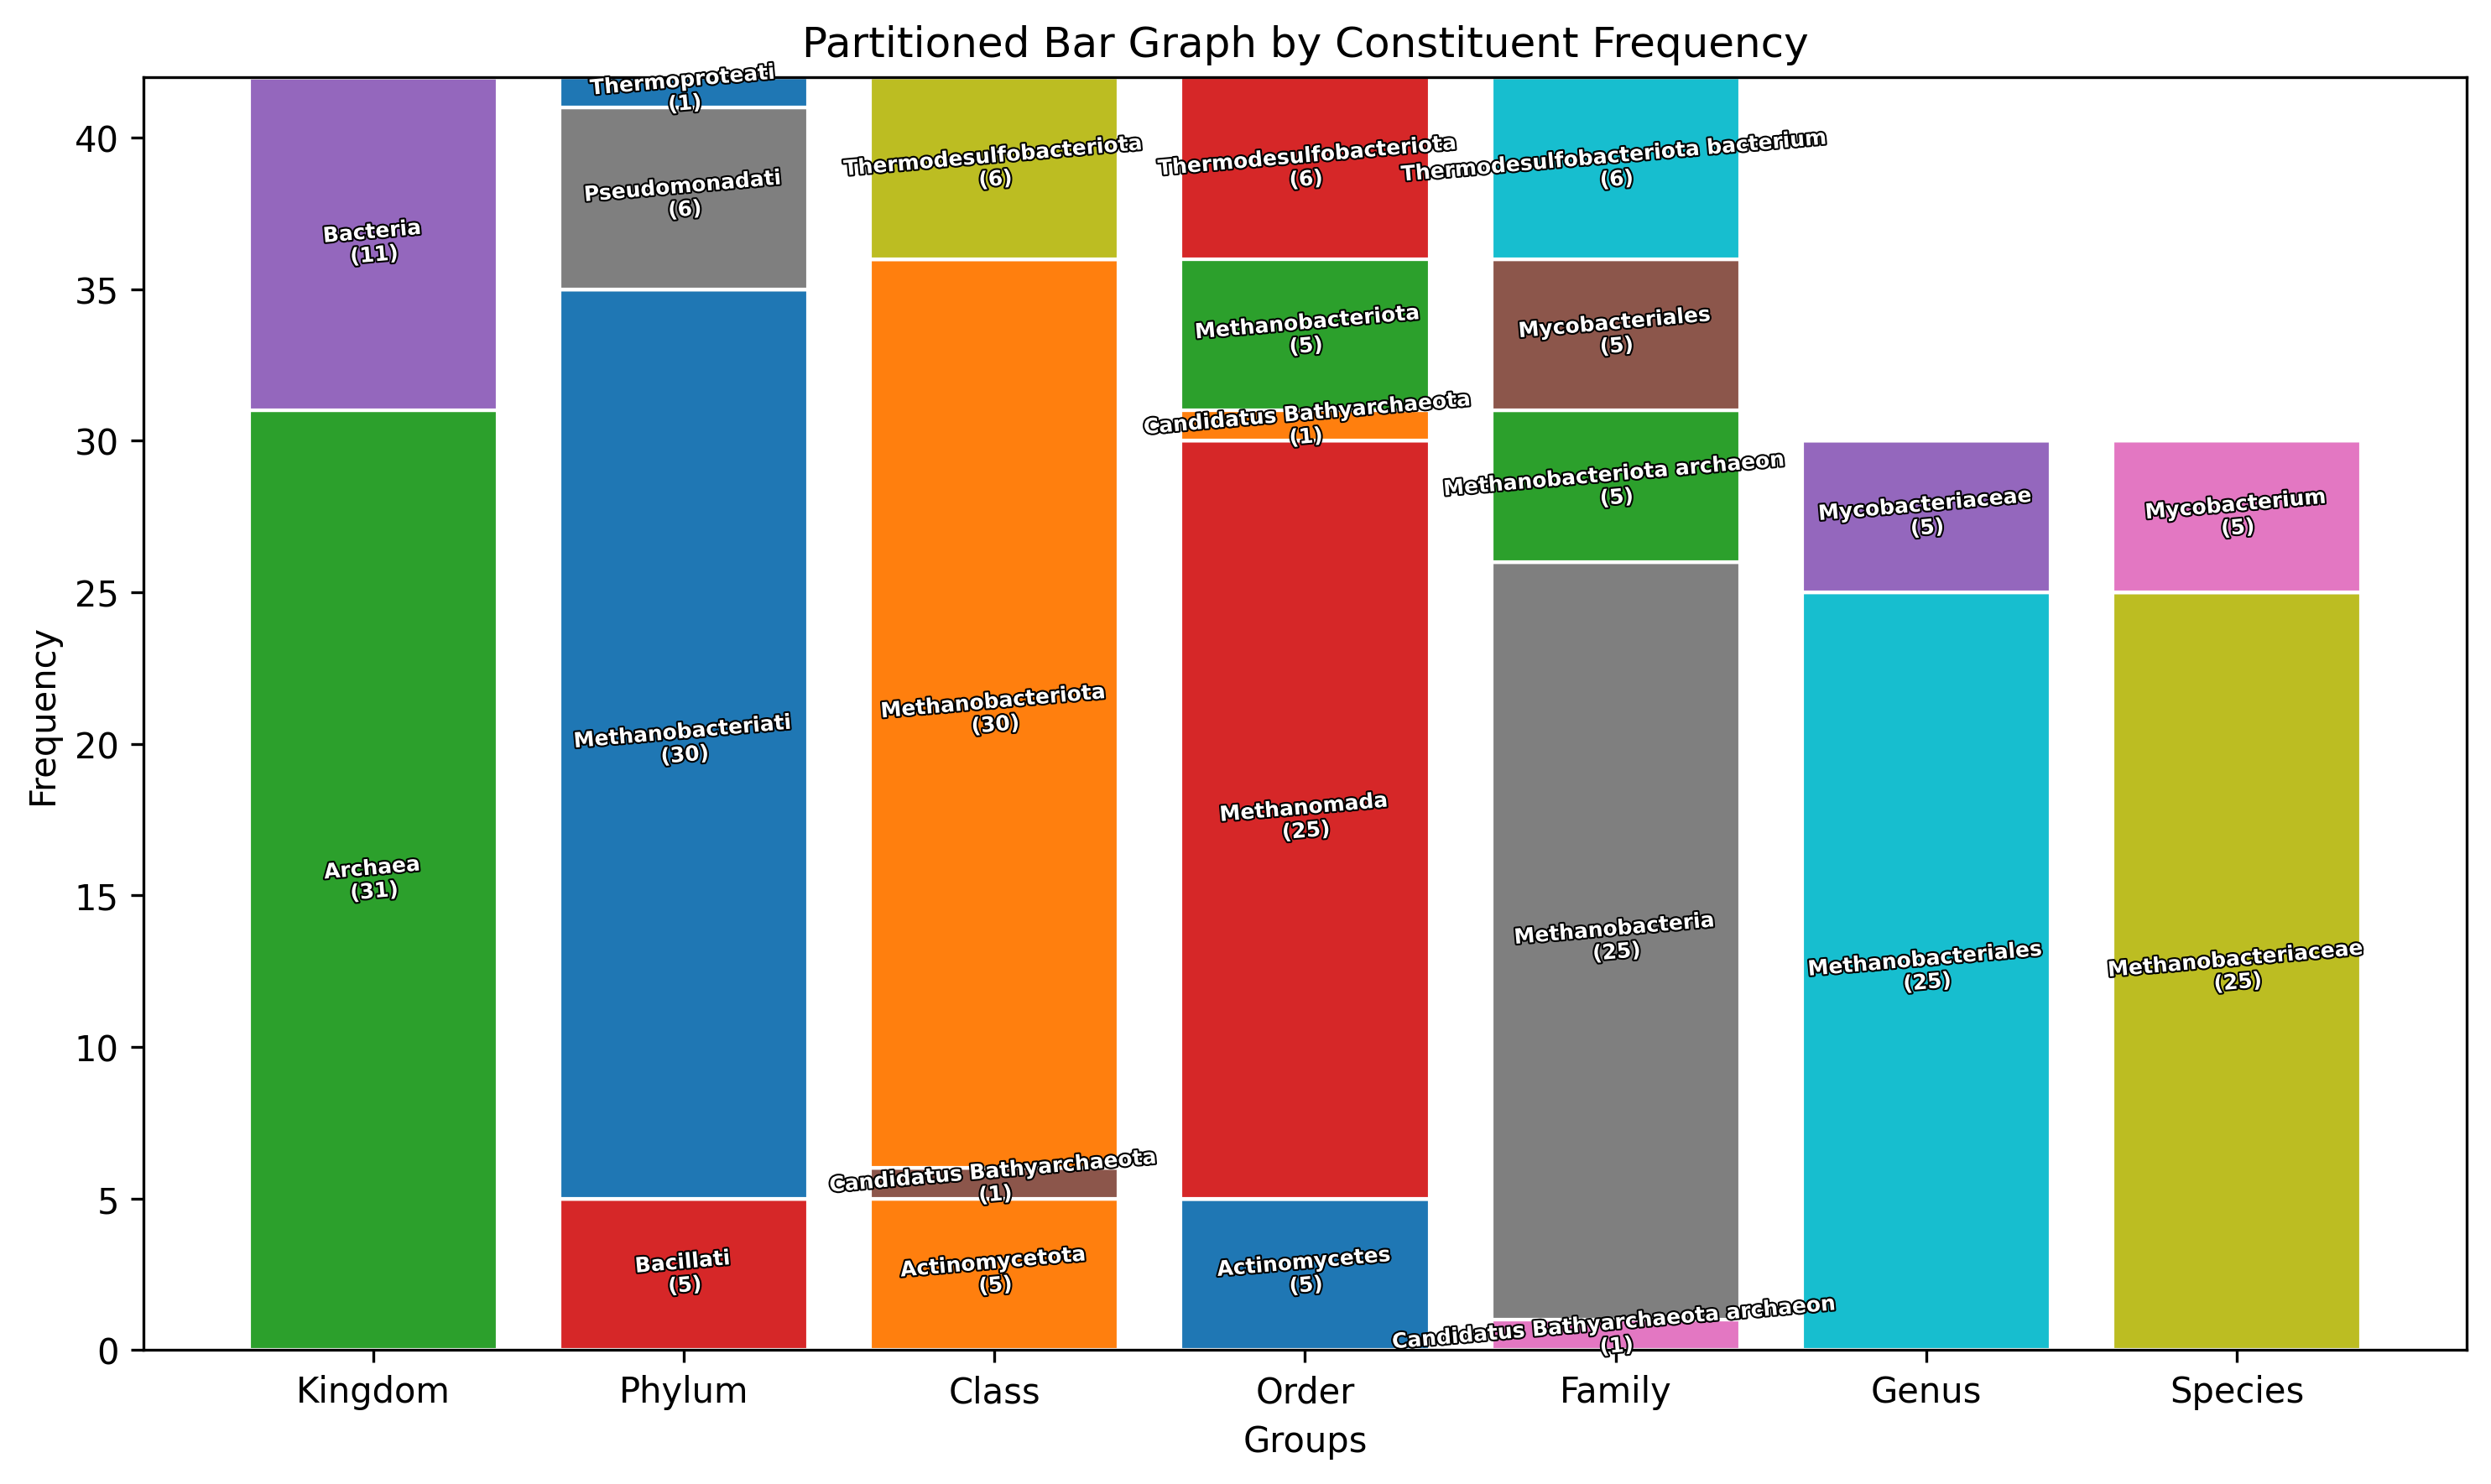

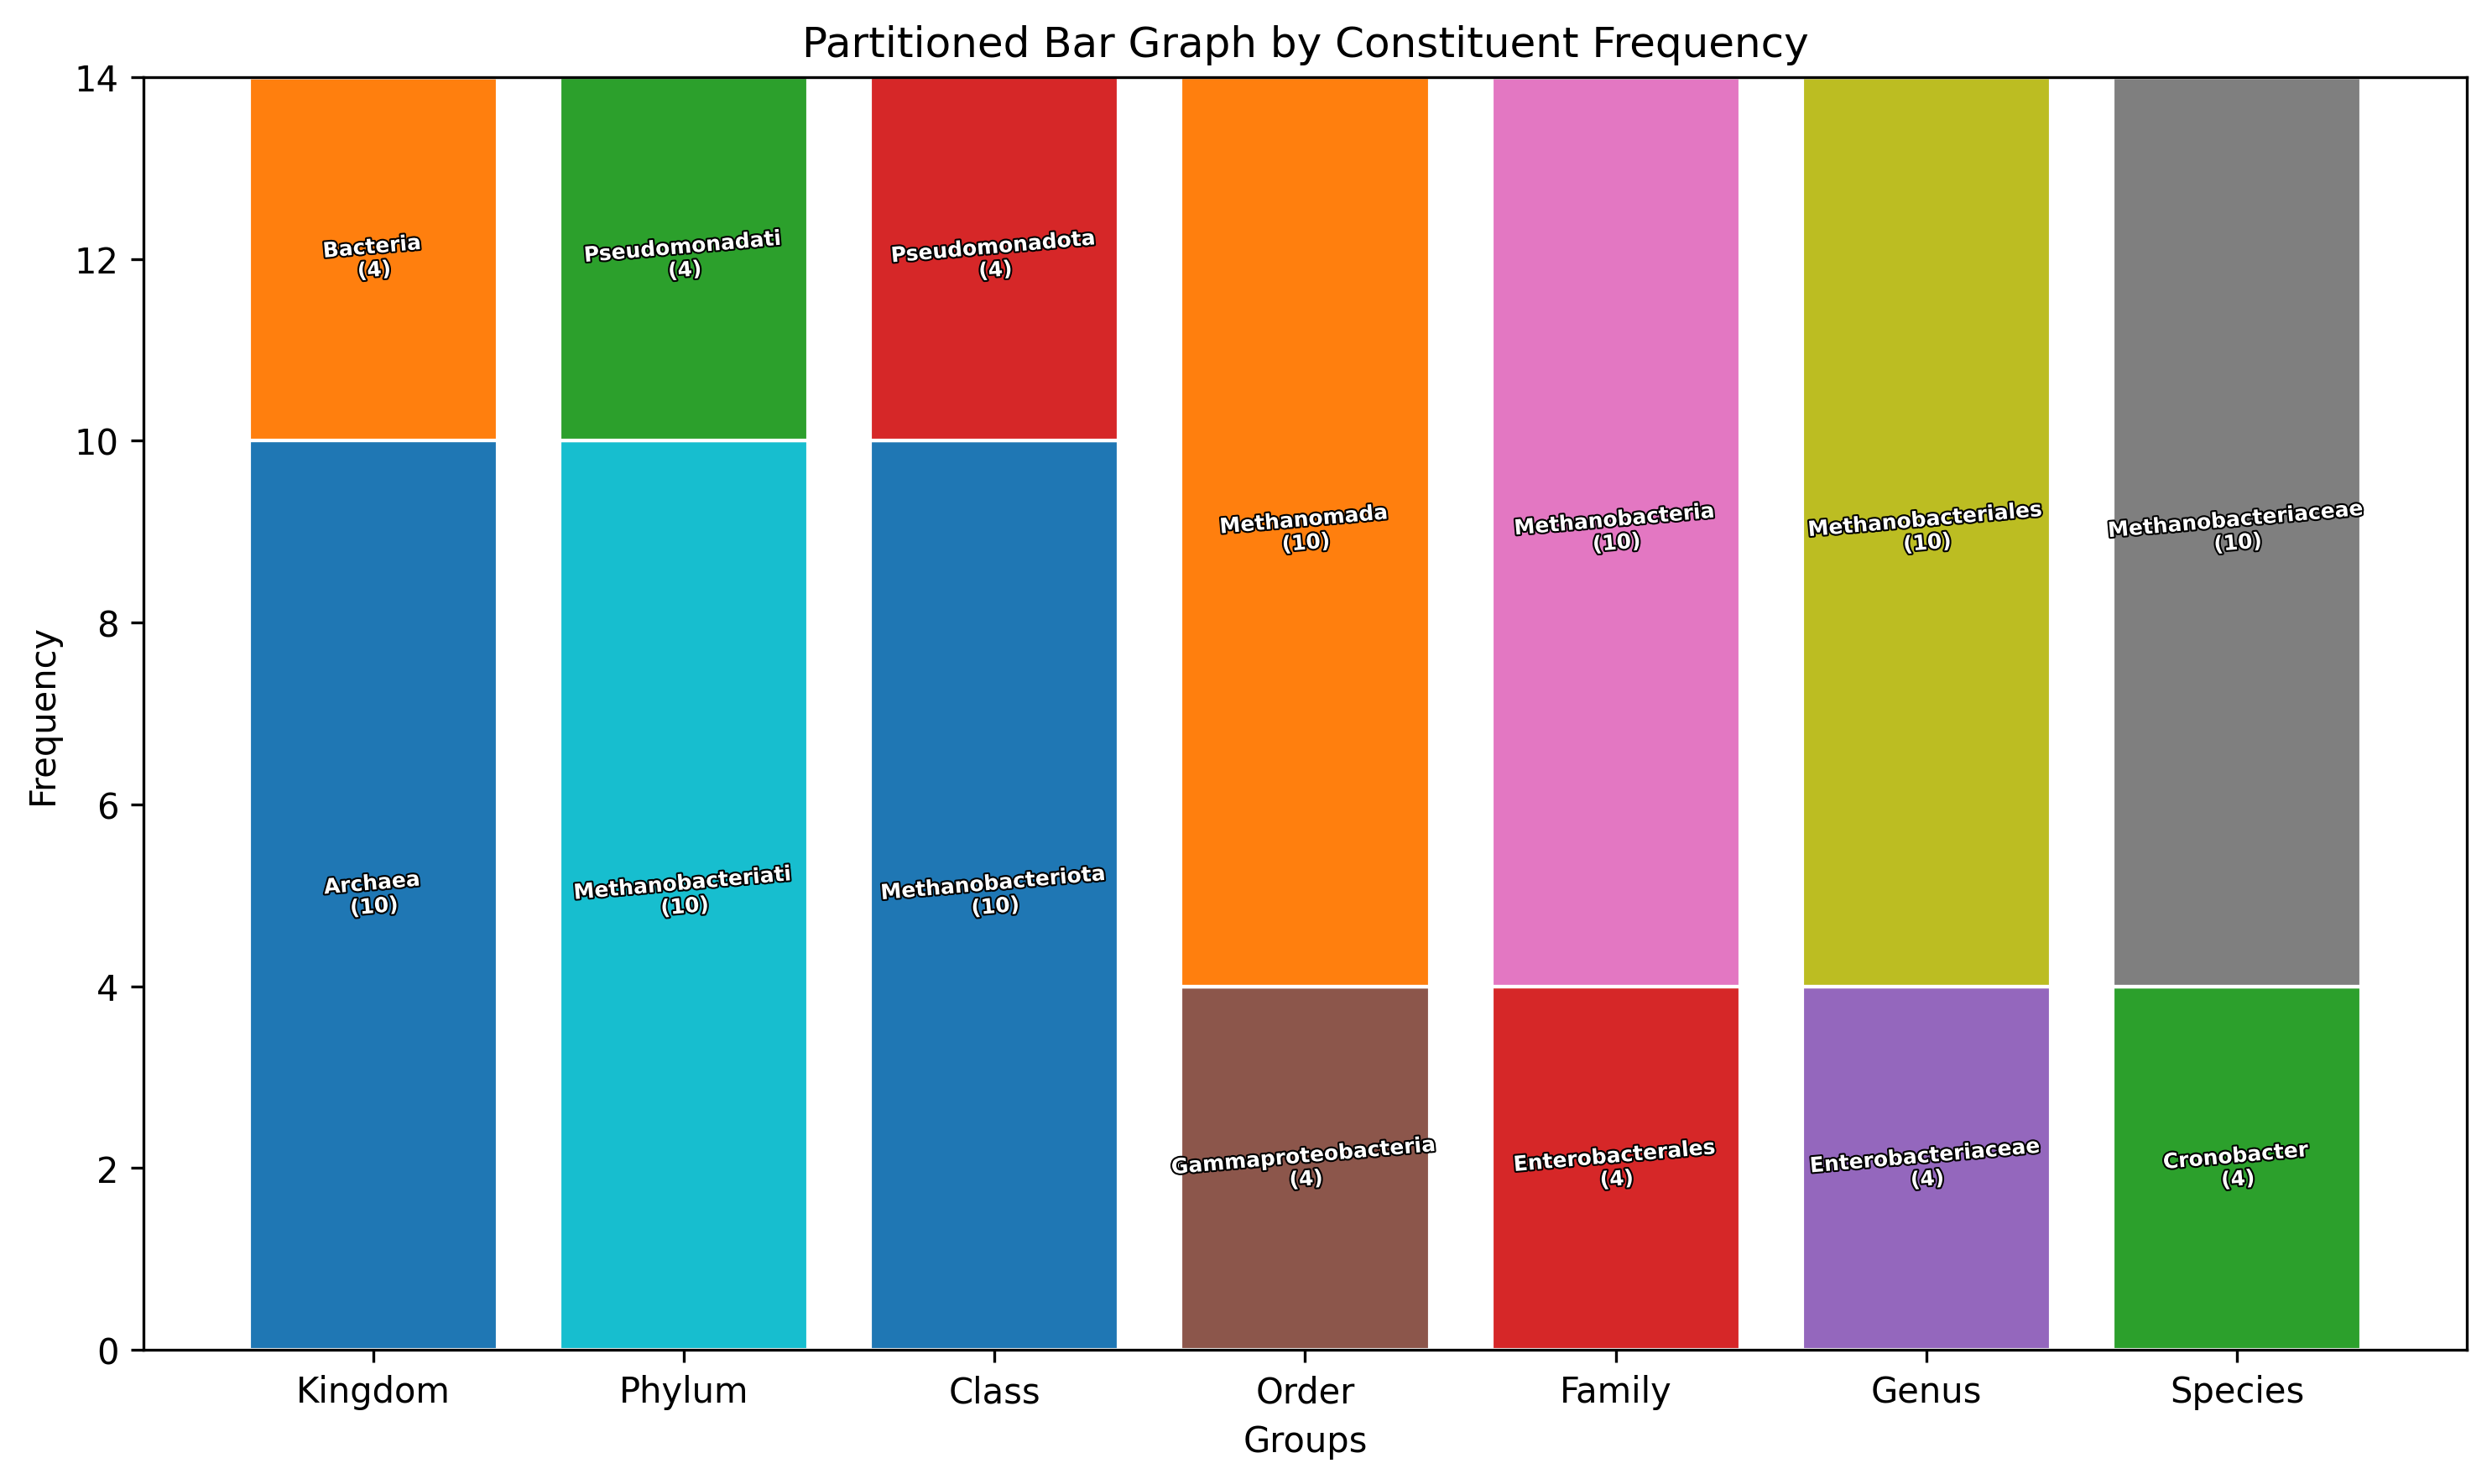

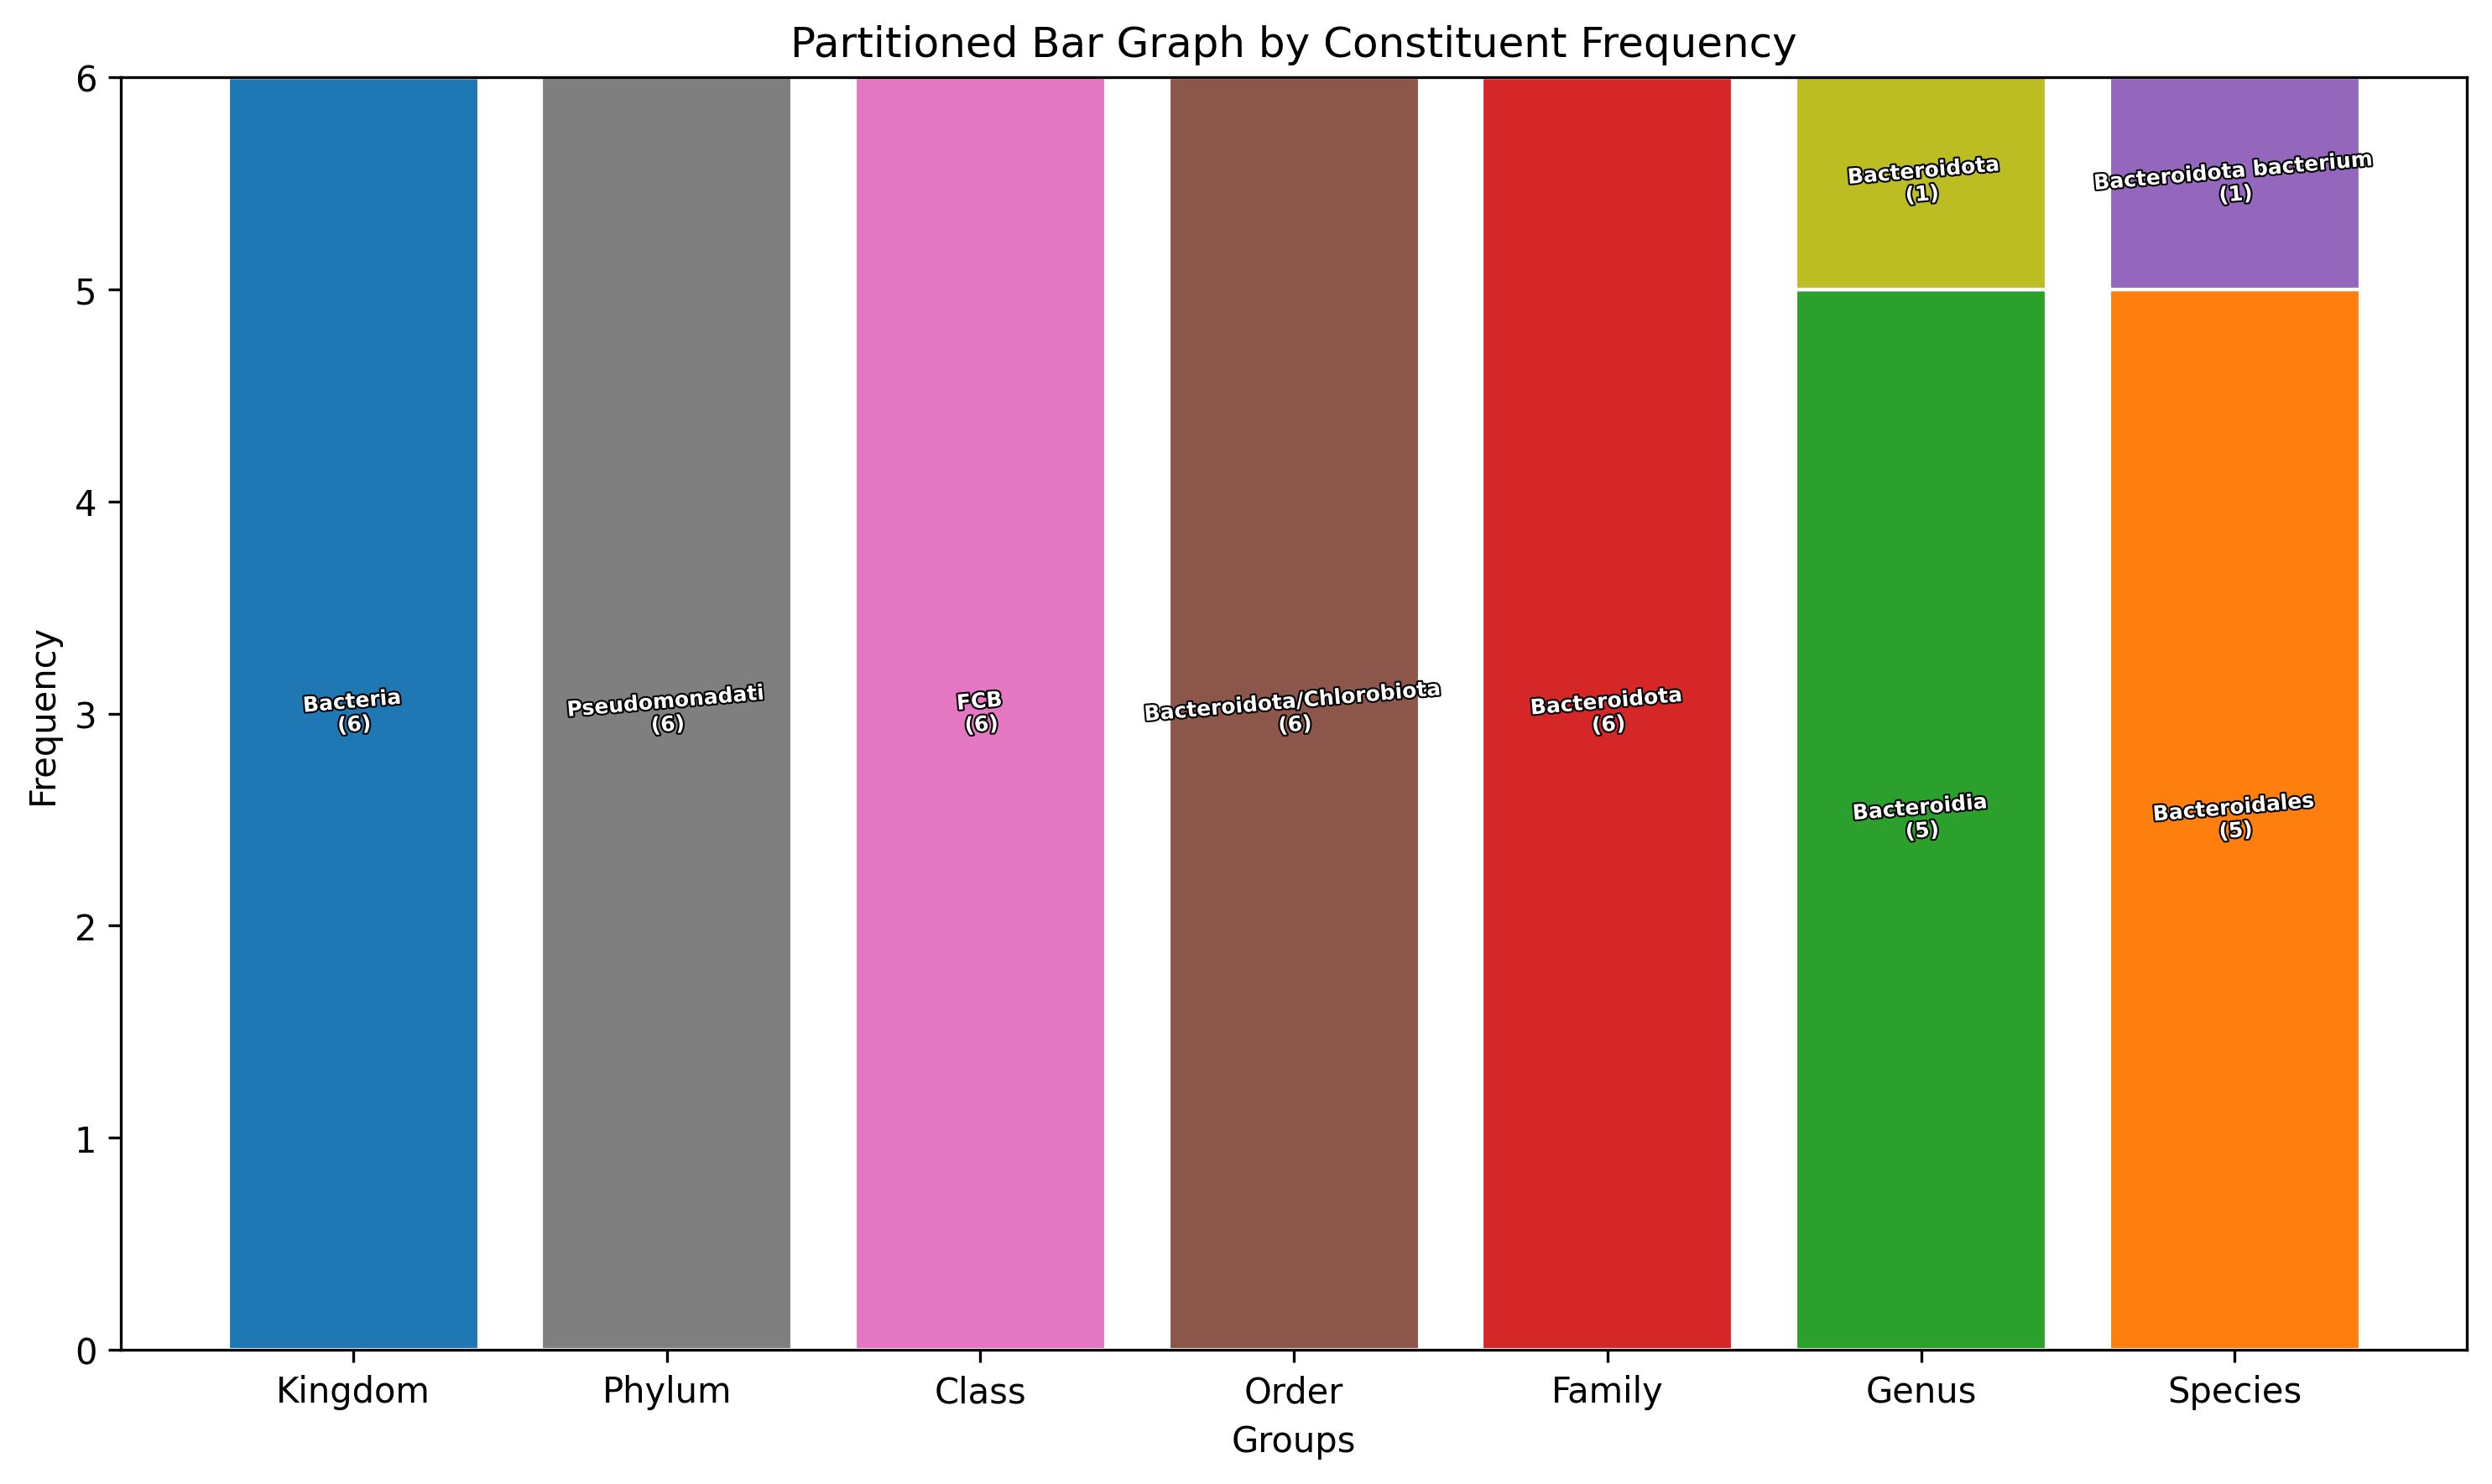

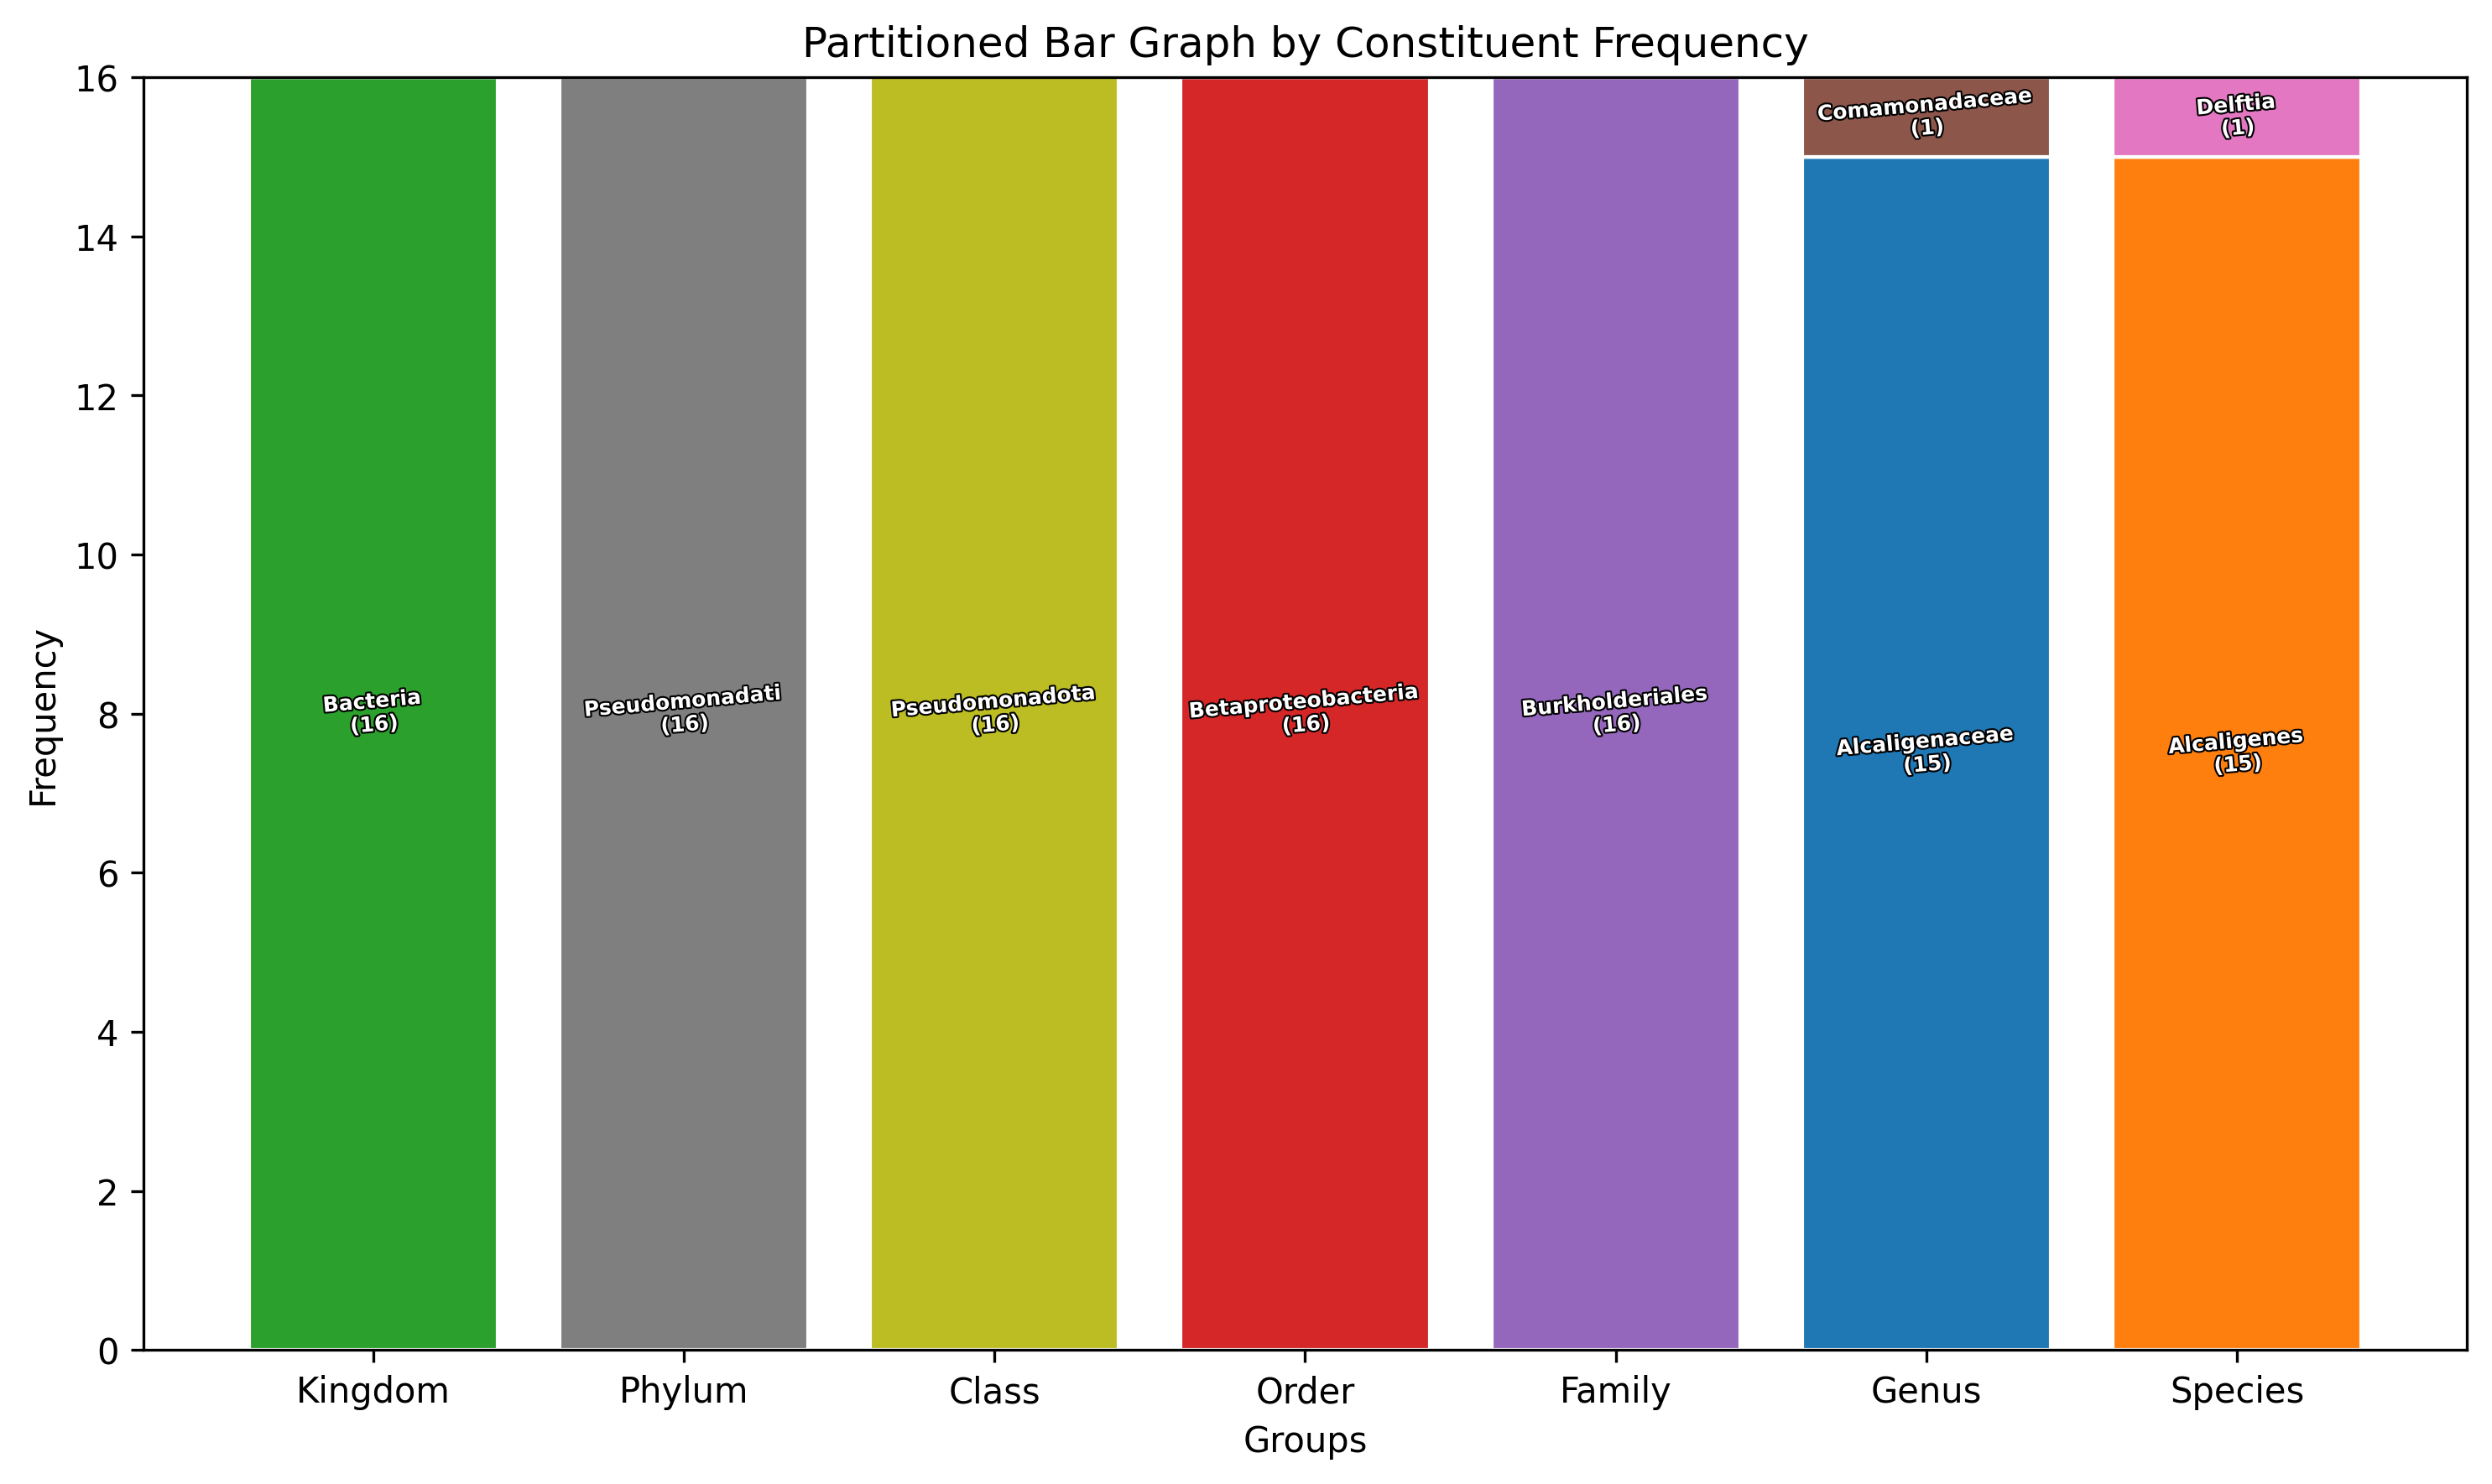

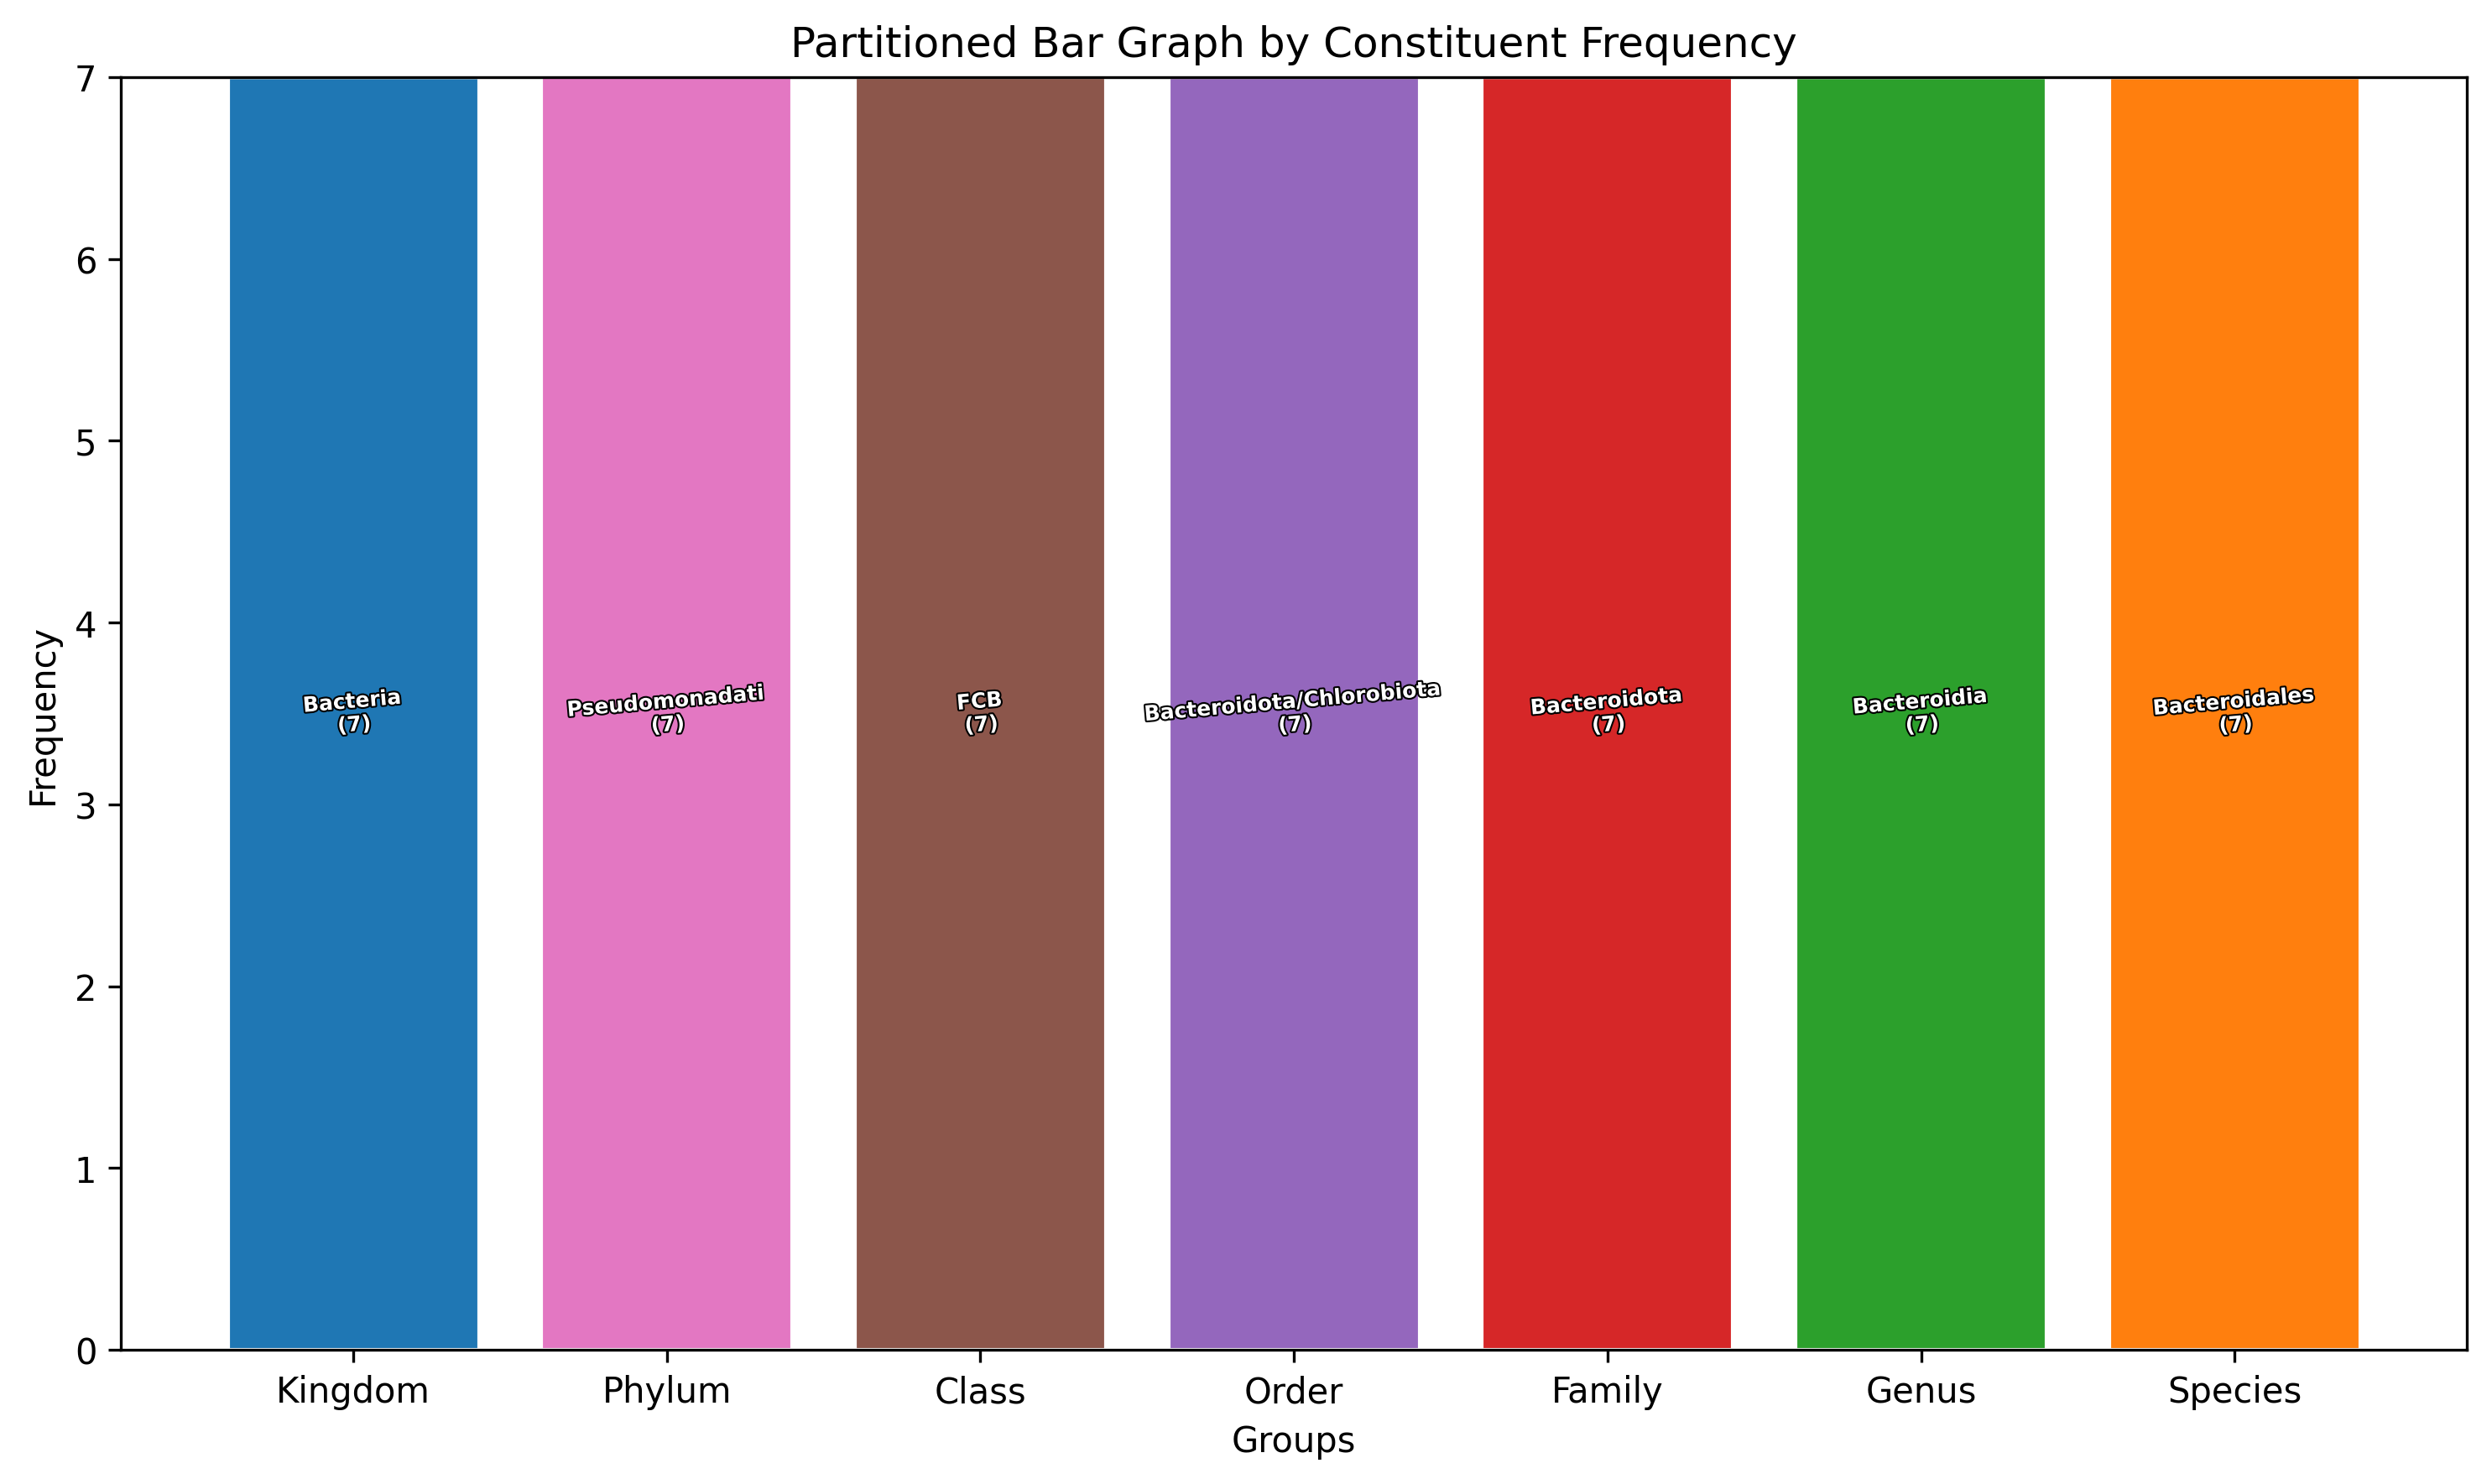

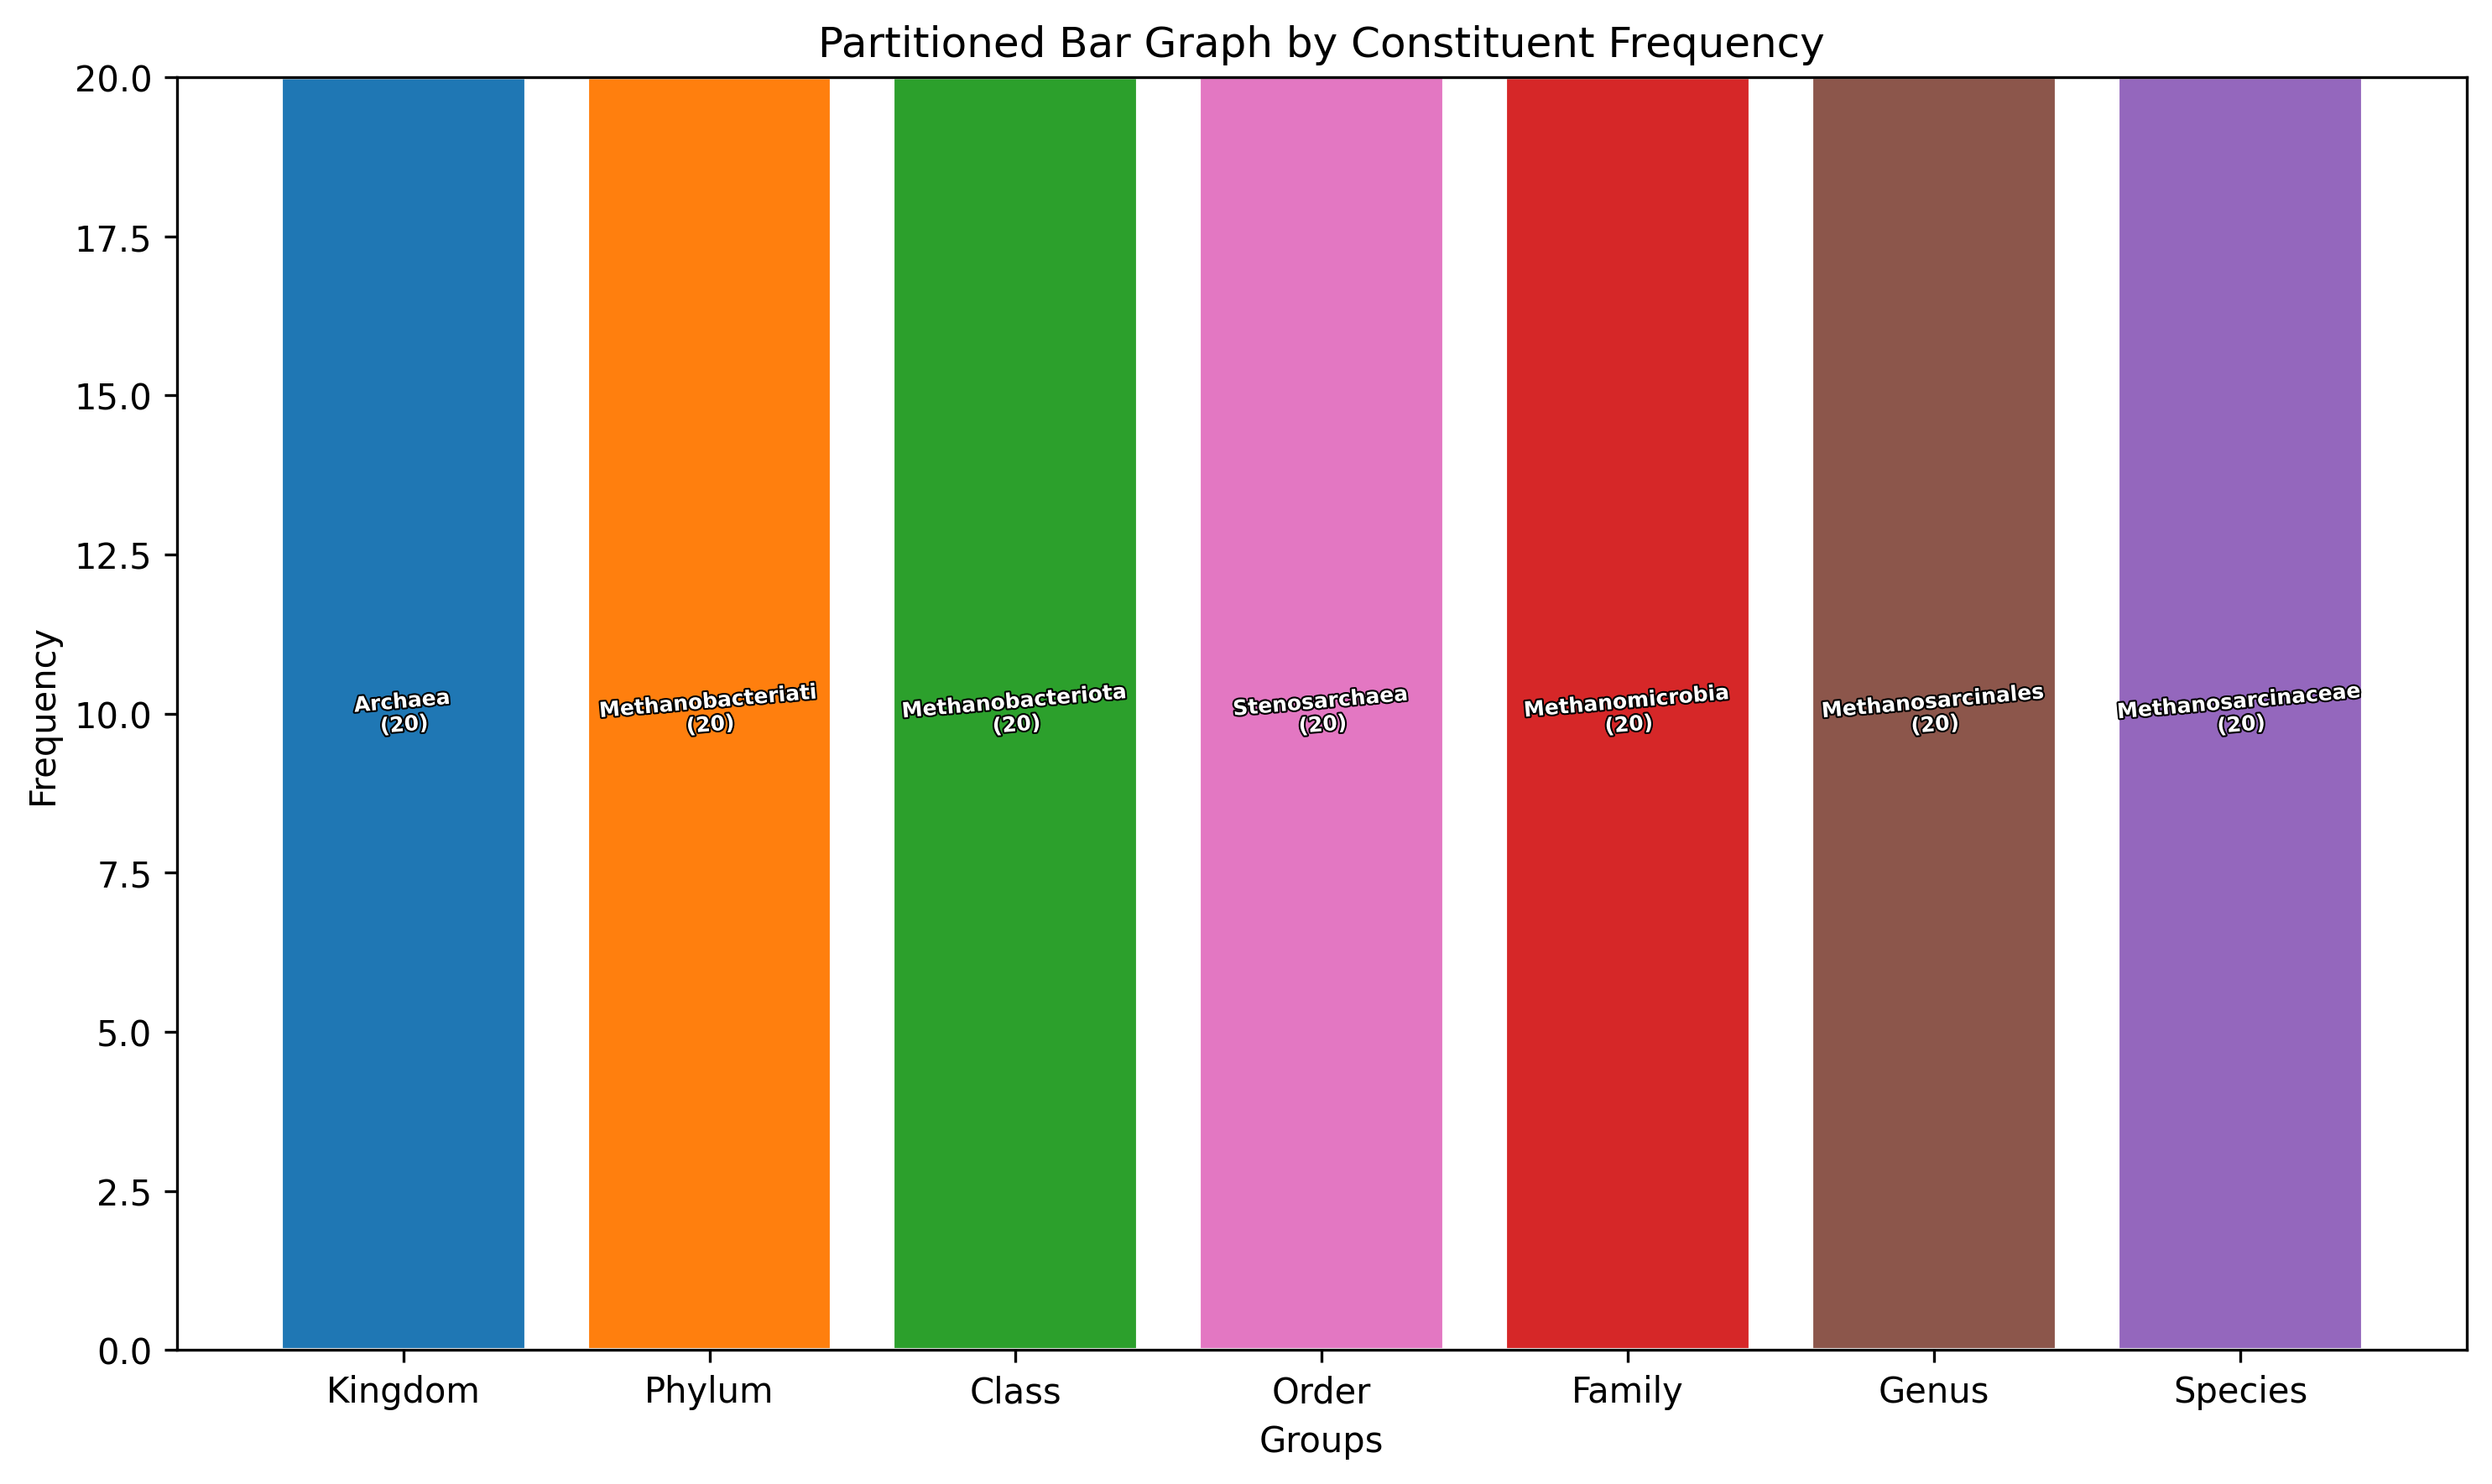

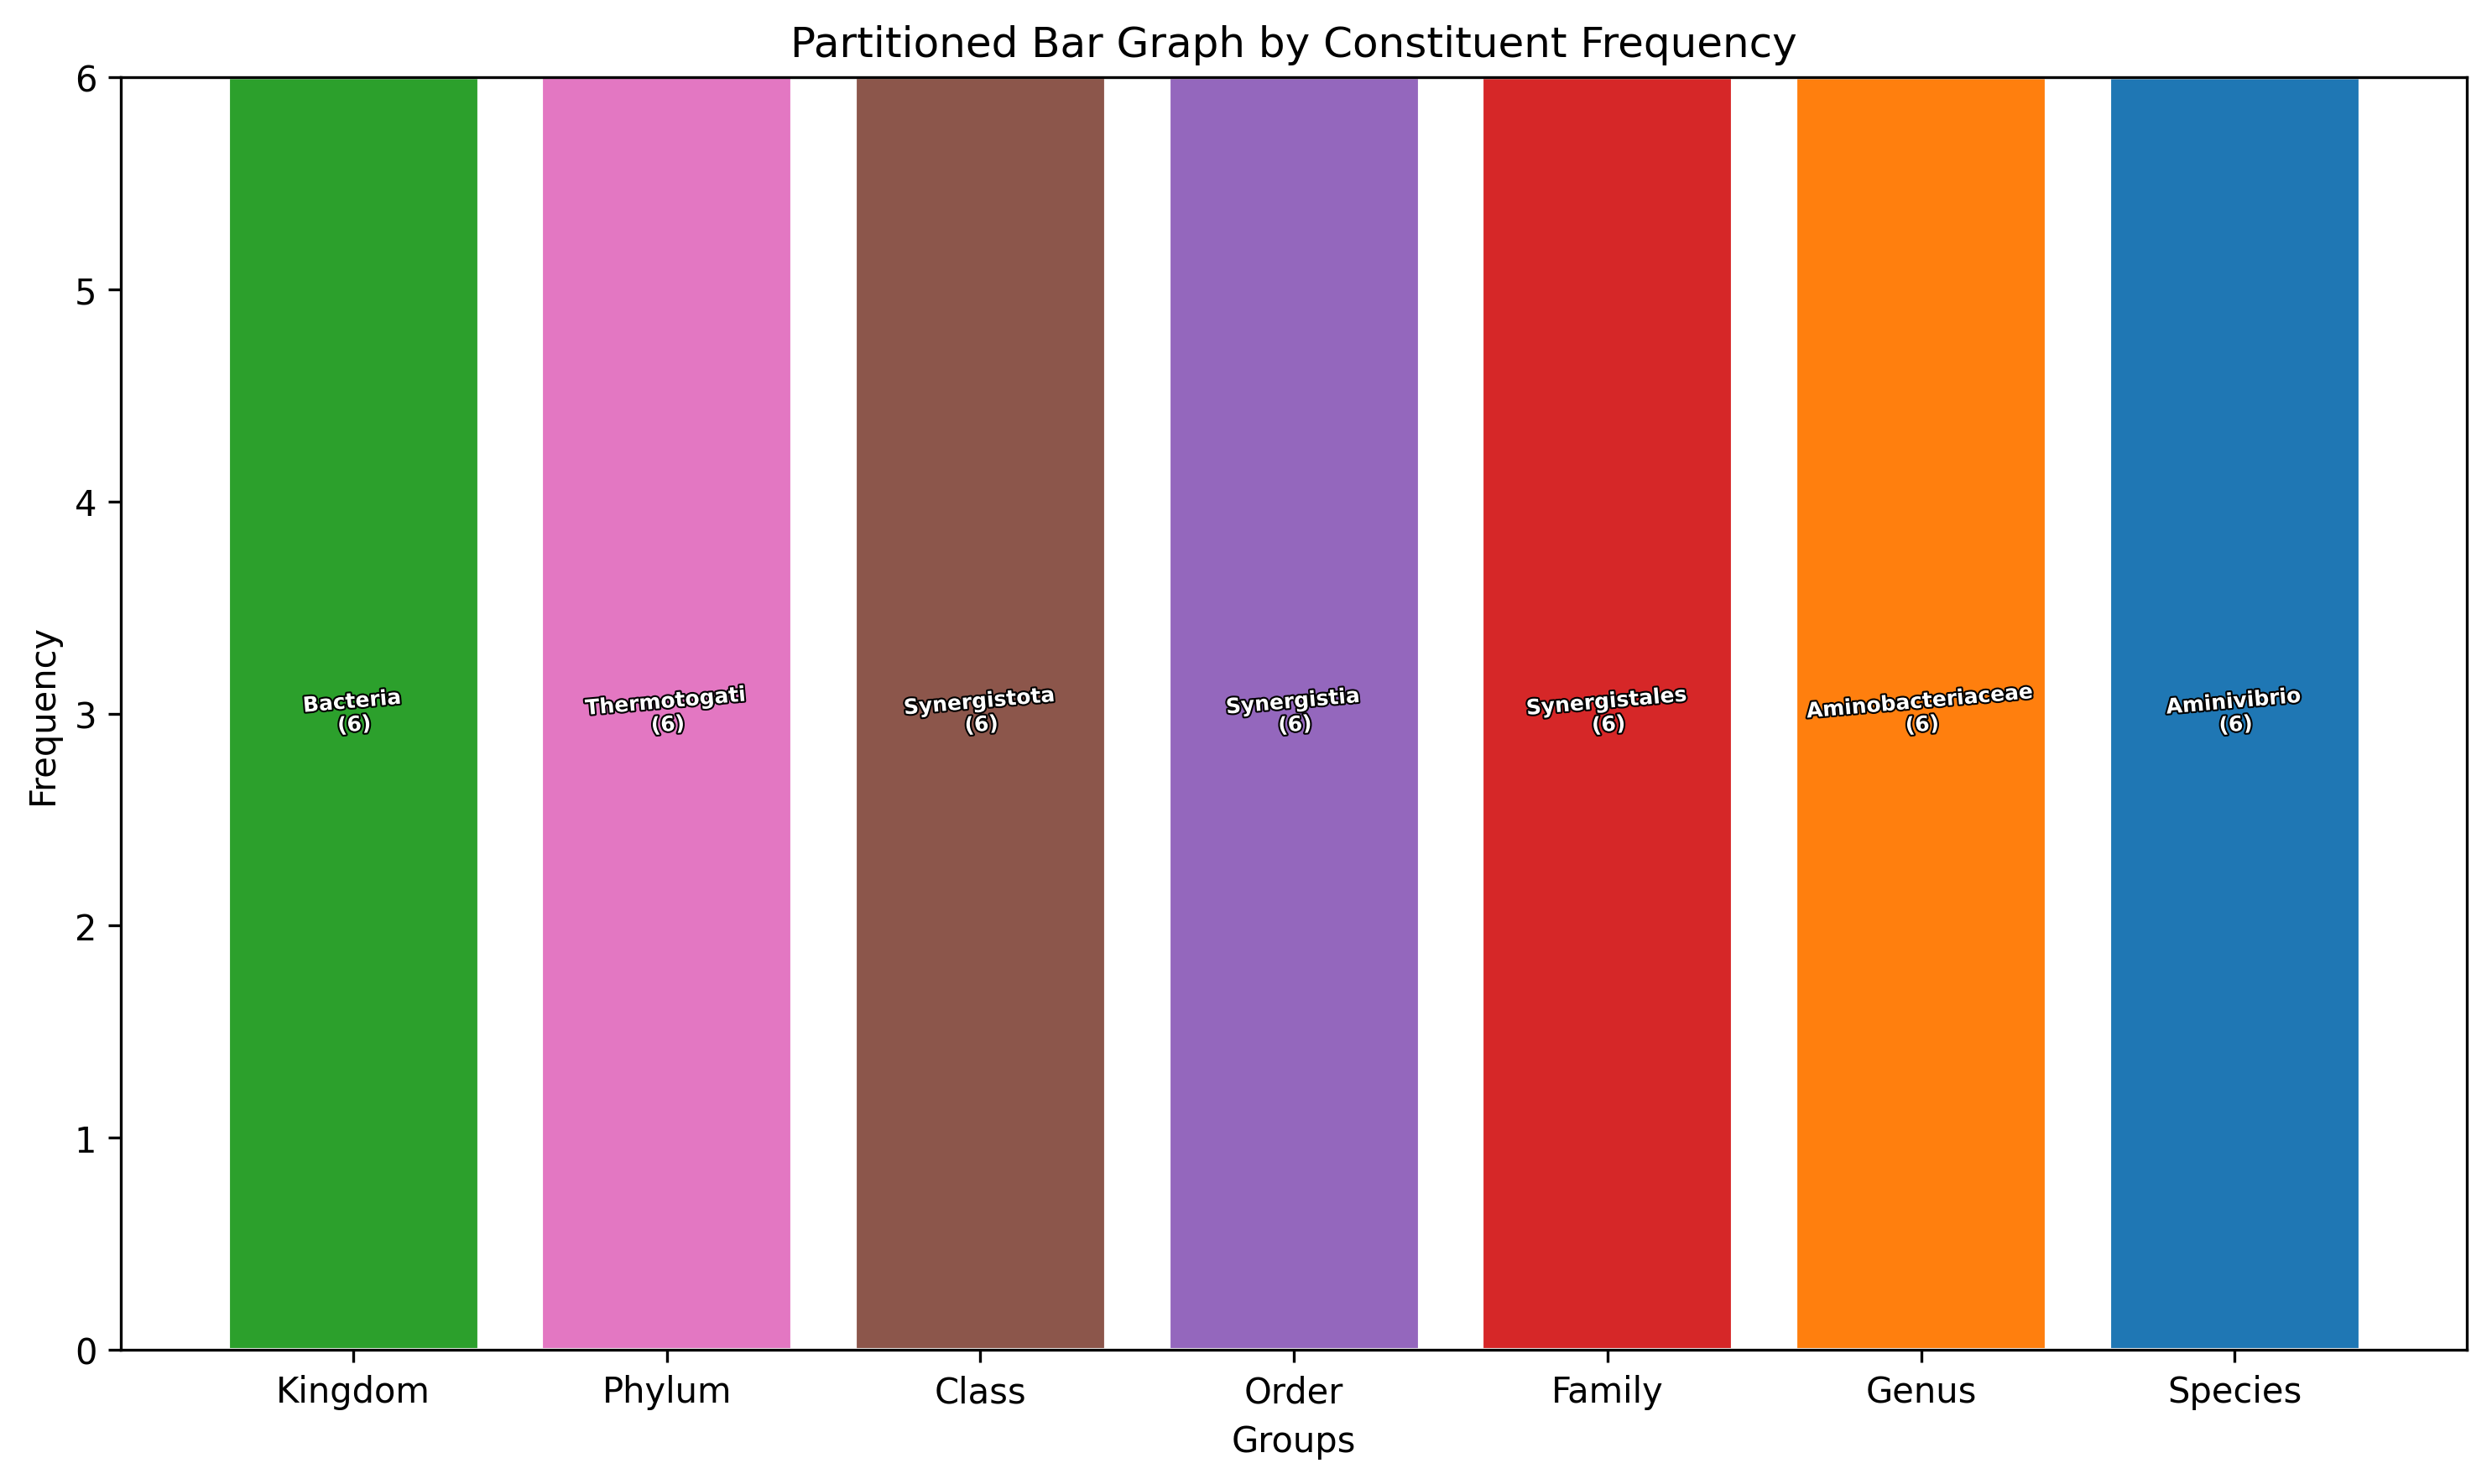

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from collections import Counter
# from json import load
# from glob import glob
# import matplotlib.patheffects as path_effects

# for genome_path in glob("ASVset_taxonomies/*"):
#     genomeID = genome_path.split("/")[-1].replace(".json", '')
#     taxonomy = load(open(genome_path, 'r'))
#     counts = {level: Counter(taxa) for level, taxa in taxonomy.items()}

#     # Extract all possible unique sub-elements (for consistent stacking order)
#     all_sub_elements = sorted({item for c in counts.values() for item in c})
    
#     # Prepare stacked bar data
#     group_names = list(counts.keys())
#     group_values = np.zeros((len(all_sub_elements), len(group_names)))
    
#     for j, group in enumerate(group_names):
#         total = sum(counts[group].values())
#         for i, sub in enumerate(all_sub_elements):
#             group_values[i, j] = counts[group].get(sub, 0) #/total
    
#     # Plotting
#     fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
#     bottom = np.zeros(len(group_names))
#     colors = plt.cm.tab10.colors  # Nice distinct palette
    
#     # Draw stacked bars with embedded labels
#     for i, sub in enumerate(all_sub_elements):
#         # print(group_values[i])
#         bars = ax.bar(group_names, group_values[i], bottom=bottom,
#                       color=colors[i % len(colors)], edgecolor='white')
    
#         # Add labels inside each subbar
#         for j, bar in enumerate(bars):
#             val = int(counts[group_names[j]].get(sub, 0))  # correct lookup
#             if val == 0: continue # Only label visible bars
#             sub = sub.replace('unclassified', '').replace(' group', '')
#             txt = ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 bar.get_y() + bar.get_height() / 2,
#                 f"{sub}\n({int(val)})",
#                 ha='center', va='center', rotation=5,
#                 fontsize=6, color='white', weight='bold'
#             )
#             # Add black stroke (outline) for readability
#             txt.set_path_effects([
#                 path_effects.Stroke(linewidth=1, foreground='black'),
#                 path_effects.Normal()
#             ])
    
#         bottom += group_values[i]
    
#     # Style & labeling
#     ax.set_ylabel("Frequency")
#     ax.set_xlabel("Groups")
#     #TODO:  add the MiDAS iterativeID in the title for comparison, and highlight the "majority" opinion of the genus
#     ax.set_title("Partitioned Bar Graph by Constituent Frequency")
#     # ax.legend(title="Elements", bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.tight_layout()
#     plt.savefig(genome_path.replace(".json", ".png"))
#     # plt.show()
#     # break


TypeError: unhashable type: 'dict'

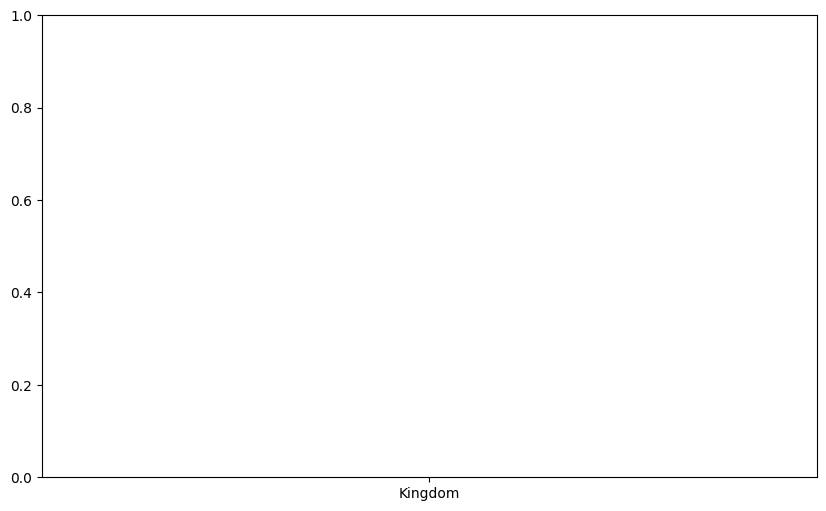

In [16]:
import matplotlib.pyplot as plt
from numpy import zeros, array
from collections import Counter
from json import load
from glob import glob

for genome_path in glob("ASVset_taxonomies/*"):
    genomeID = genome_path.split("/")[-1].replace(".json", '')
    taxonomy = load(open(genome_path, 'r'))
    counts = {level: Counter(taxa) for level, taxa in taxonomy.items()}
    # all_sub_elements = sorted({item for c in counts.values() for item in c})
    
    # Prepare stacked bar data
    group_names = list(counts.keys())
    fig, ax = plt.subplots(figsize=(10, 6))
    # group_values = zeros((len(all_sub_elements), len(group_names)))
    for level, counted_taxa in counts.items():
        total = sum(counted_taxa.values())
        # group_values[level] = 
        ax.bar(level, {k:v/total for k,v in counted_taxa.items()}) #, bottom=bottom, label=sub)
    
    # for j, group in enumerate(group_names):
    #     total = sum(counts[group].values())
    #     for i, sub in enumerate(all_sub_elements):
    #         group_values[i, j] = counts[group].get(sub, 0) / total
    
    # Plotting
    # fig, ax = plt.subplots(figsize=(10, 6))
    # # bottom = zeros(len(group_names))
    # for i, sub in enumerate(all_sub_elements):
    #     ax.bar(group_names, group_values[i], bottom=bottom, label=sub)
        # bottom += group_values[i]
    # for i, sub in enumerate(all_sub_elements):
    #     ax.bar(group_names, group_values[i], bottom=bottom, label=sub)
    #     bottom += group_values[i]
    
    # Style & labeling
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Groups")
    ax.set_title("Partitioned Bar Graph by Constituent Frequency")
    ax.legend(title="Elements", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Local version

In [ ]:
#Now building asv genome objects and saving to file (will be loaded to KBase)
# from cobrakbase.core.kbasegenome.genome import KBaseGenome
from numpy import mean
from json import load
from os import path
from tqdm import tqdm

# def determine_GC(genomes):
#     sequence = sequence.upper()
#     g_count = sequence.count('G')
#     c_count = sequence.count('C')
#     total = len(sequence)
    
#     # Avoid division by zero (empty sequence)
#     if total == 0:
#         return 0.0
    
#     return (g_count + c_count) / total * 100

midas_taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
# genome_hash = load(open("/Users/andrewfreiburger/Documents/Research/sludge/data/genome_hash.json", 'r'))    # genome_hash = util.load("genome_hash")
iterativeIDs = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/iterativeIDs.json", 'r'))

# functions = util.load("functions")  #??
# feature_aliases = util.load("feature_aliases")
feature_probabilities = load(open("modeling_files/product_probabilities.json", 'r'))
features = {}
ws_client = util.ws_client()
genomes_nar = 221042
#The 1352.8344 organism errored-out in the RAST annotation pipeline

for ASV_md5, genomesIDs in tqdm(ASV_genomes.items()):
    # asv_genus = midas_taxonomy[ASV]["Genus"]
    if ASV_md5 not in iterativeIDs:
        print(f"The {ASV_md5} is missing in iterativeIDs")
        continue
    asv_genus = iterativeIDs[ASV_md5]
    if (path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/datacache/Assemblies/{asv_genus}.fasta")
        and path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/data/genomes/{asv_genus}.json")):
        print(f"{asv_genus} has already been processed and will be skipped")
        continue
    genre = asv_genus.split(".")[0]
    print("Processing ", asv_genus)
    #Loading template genome
    template_genome = load(open("model_inputs/TemplateGenome.json", 'r'))
    #Setting metadata
    genomes = [g+"__sludge_genomes.RAST" for g in genomesIDs]
    template_genome.update({
        "assembly_ref": f"{genomes_nar}/{asv_genus}.assembly",
        "dna_size": 0,
        "scientific_name": midas_taxonomy[ASV_md5],
        "taxonomy": midas_taxonomy[ASV_md5],
        "gc_content": mean([float(genome_hash[g][10]["GC content"]) for g in genomes]),
        "id": asv_genus,
        "contig_ids": [],
        "contig_lengths": [],
        "num_contigs": 0,
        "source": "Sludge",
        "warnings": ["Artificial genome created to support ASV modeling"],
        "features": [],
        "cdss": [],
        "source_id": "|".join(genomes),
        "molecule_type": "ASV derived genome",
        "genome_type": "ASV derived genome",
        "domain": midas_taxonomy[ASV_md5]["Kingdom"],
        "ontologies_present": {},
        "ontology_events": []
    })

    md5_list = []
    functions.setdefault(asv_genus,{})
    for genomeID in tqdm(genomes):
        if genomeID not in genome_hash:  continue
        # info = genome_hash[genomeID]
        # genome = util.msrecon.kbase_api.get_object(genomeID, genomes_nar)

        genome_functions = {}
        for ftr in genome["features"]:
            if "functions" not in ftr:  continue
            for function in ftr["functions"]:
                if function not in functions[asv_genus]:
                    ftrid = f"{asv_genus}_{len(template_genome['contig_ids'])+1}"
                    ##updating the template_genome
                    template_genome["contig_ids"].append(ftrid+".contig")
                    template_genome["contig_lengths"].append(len(ftr["dna_sequence"]))
                    template_genome["num_contigs"] += 1
                    template_genome["dna_size"] += len(ftr["dna_sequence"])

                    protein_md5 = hashlib.md5(ftr["protein_translation"].encode()).hexdigest()
                    md5_list.append(protein_md5)
                    functions[asv_genus][function] = {"ftrid":ftrid, "probability":1}

                    ##updating the features
                    features[ftrid] = {
                        "aliases": [],
                        "cdss": [ftrid+".CDS"],
                        "functions":[function],
                        "dna_sequence": ftr["dna_sequence"],
                        "dna_sequence_length": len(ftr["dna_sequence"]),
                        "id": ftrid,
                        "location": [[ftrid+".contig", 1, "+", len(ftr["dna_sequence"])]],
                        "md5": hashlib.md5(ftr["dna_sequence"].encode()).hexdigest(),
                        "ontology_terms": {},
                        "protein_md5": protein_md5,
                        "protein_translation": ftr["protein_translation"],
                        "protein_translation_length": len(ftr["protein_translation"]),
                        "warnings": []
                    }
                    cdsftr = features[ftrid].copy()
                    del cdsftr["cdss"]
                    cdsftr["id"] = f"{ftrid}.CDS"
                    cdsftr["parent_gene"] = ftrid
                    template_genome["cdss"].append(cdsftr)
                elif function not in genome_functions:  #Don't want to count same function twice in a genome
                    ftrid = functions[asv_genus][function]["ftrid"]
                    functions[asv_genus][function]["probability"] += 1
                
                if "aliases" not in ftr or len(ftr["aliases"]) < 1:  continue
                features[ftrid]["aliases"].append(["gene", f"{info[6]}/{info[0]}.{ftr['aliases'][0][1]}"])
                if function not in functions[asv_genus]:
                    template_genome["features"].append(features[ftrid])
                feature_aliases.setdefault(ftrid, []).append(ftr["aliases"][0][1])
                genome_functions[function] = True
        for func in functions[asv_genus]:
            functions[asv_genus][func]["probability"] /= len(genomes)
            feature_probabilities[functions[asv_genus][func]["ftrid"]] = functions[asv_genus][func]["probability"]
        template_genome["feature_counts"] = {
            "CDS": len(template_genome["features"]),
            "gene": len(template_genome["features"]),
            "non_coding_features": 0,
            "protein_encoding_gene": len(template_genome["features"])
        }                    
        md5_list.sort()
        result = hashlib.md5(";".join(md5_list).encode())
        template_genome["md5"] = result.hexdigest()

        #Writing FASTA
        ofile = open("datacache/Assemblies/"+asv_genus+".fasta", "w")
        for func in functions[asv_genus]:
            ofile.write(">" + functions[asv_genus][func]["ftrid"] + "\n" +features[functions[asv_genus][func]["ftrid"]]["dna_sequence"] + "\n")
        ofile.close()

        print(asv_genus)

        #Saving genome
        util.save(f"genomes/{asv_genus}", template_genome)
        util.save("feature_aliases", feature_aliases)
        util.save("functions", functions)
        util.save("feature_probabilities", feature_probabilities)     

## KBase version

In [ ]:
#Now building asv genome objects and saving to file (will be loaded to KBase)
# from cobrakbase.core.kbasegenome.genome import KBaseGenome
from numpy import mean
from json import load
from os import path
from tqdm import tqdm

midas_taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
ASV_genomes = load(open("modeling_files/ASV_genomes.json", 'r'))
# genome_hash = load(open("/Users/andrewfreiburger/Documents/Research/sludge/data/genome_hash.json", 'r'))    # genome_hash = util.load("genome_hash")
iterativeIDs = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/iterativeIDs.json", 'r'))

# functions = util.load("functions")  #??
# feature_aliases = util.load("feature_aliases")
feature_probabilities = load(open("modeling_files/product_probabilities.json", 'r'))
features = {}
ws_client = util.ws_client()
genomes_nar = 221042
#The 1352.8344 organism errored-out in the RAST annotation pipeline

for ASV_md5, genomesIDs in tqdm(ASV_genomes.items()):
    # asv_genus = midas_taxonomy[ASV]["Genus"]
    if ASV_md5 not in iterativeIDs:
        print(f"The {ASV_md5} is missing in iterativeIDs")
        continue
    asv_genus = iterativeIDs[ASV_md5]
    if (path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/datacache/Assemblies/{asv_genus}.fasta")
        and path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/data/genomes/{asv_genus}.json")):
        print(f"{asv_genus} has already been processed and will be skipped")
        continue
    genre = asv_genus.split(".")[0]
    print("Processing ", asv_genus)
    #Loading template genome
    template_genome = load(open("model_inputs/TemplateGenome.json", 'r'))
    #Setting metadata
    genomes = [g+"__sludge_genomes.RAST" for g in genomesIDs]
    template_genome.update({
        "assembly_ref": f"{genomes_nar}/{asv_genus}.assembly",
        "dna_size": 0,
        "scientific_name": midas_taxonomy[ASV_md5],
        "taxonomy": midas_taxonomy[ASV_md5],
        "gc_content": mean([float(genome_hash[g][10]["GC content"]) for g in genomes]),
        "id": asv_genus,
        "contig_ids": [],
        "contig_lengths": [],
        "num_contigs": 0,
        "source": "Sludge",
        "warnings": ["Artificial genome created to support ASV modeling"],
        "features": [],
        "cdss": [],
        "source_id": "|".join(genomes),
        "molecule_type": "ASV derived genome",
        "genome_type": "ASV derived genome",
        "domain": midas_taxonomy[ASV_md5]["Kingdom"],
        "ontologies_present": {},
        "ontology_events": []
    })

    md5_list = []
    functions.setdefault(asv_genus,{})
    for genomeID in tqdm(genomes):
        if genomeID not in genome_hash:  continue
        info = genome_hash[genomeID]
        genome = util.msrecon.kbase_api.get_object(genomeID, genomes_nar)

        genome_functions = {}
        for ftr in genome["features"]:
            if "functions" not in ftr:  continue
            for function in ftr["functions"]:
                if function not in functions[asv_genus]:
                    ftrid = f"{asv_genus}_{len(template_genome['contig_ids'])+1}"
                    ##updating the template_genome
                    template_genome["contig_ids"].append(ftrid+".contig")
                    template_genome["contig_lengths"].append(len(ftr["dna_sequence"]))
                    template_genome["num_contigs"] += 1
                    template_genome["dna_size"] += len(ftr["dna_sequence"])

                    result = hashlib.md5(ftr["protein_translation"].encode())
                    md5 = result.hexdigest()
                    result = hashlib.md5(ftr["dna_sequence"].encode())
                    dnamd5 = result.hexdigest()
                    md5_list.append(md5)
                    functions[asv_genus][function] = {"ftrid":ftrid, "probability":1}

                    ##updating the features
                    features[ftrid] = {
                        "aliases": [],
                        "cdss": [ftrid+".CDS"],
                        "functions":[function],
                        "dna_sequence": ftr["dna_sequence"],
                        "dna_sequence_length": len(ftr["dna_sequence"]),
                        "id": ftrid,
                        "location": [[ftrid+".contig", 1, "+", len(ftr["dna_sequence"])]],
                        "md5": dnamd5,
                        "ontology_terms": {},
                        "protein_md5": md5,
                        "protein_translation": ftr["protein_translation"],
                        "protein_translation_length": len(ftr["protein_translation"]),
                        "warnings": []
                    }
                    cdsftr = features[ftrid].copy()
                    del cdsftr["cdss"]
                    cdsftr["id"] = f"{ftrid}.CDS"
                    cdsftr["parent_gene"] = ftrid
                    template_genome["cdss"].append(cdsftr)
                elif function not in genome_functions:  #Don't want to count same function twice in a genome
                    ftrid = functions[asv_genus][function]["ftrid"]
                    functions[asv_genus][function]["probability"] += 1
                
                if "aliases" not in ftr or len(ftr["aliases"]) < 1:  continue
                features[ftrid]["aliases"].append(["gene", f"{info[6]}/{info[0]}.{ftr['aliases'][0][1]}"])
                if function not in functions[asv_genus]:
                    template_genome["features"].append(features[ftrid])
                feature_aliases.setdefault(ftrid, []).append(ftr["aliases"][0][1])
                genome_functions[function] = True
        for func in functions[asv_genus]:
            functions[asv_genus][func]["probability"] /= len(genomes)
            feature_probabilities[functions[asv_genus][func]["ftrid"]] = functions[asv_genus][func]["probability"]
        template_genome["feature_counts"] = {
            "CDS": len(template_genome["features"]),
            "gene": len(template_genome["features"]),
            "non_coding_features": 0,
            "protein_encoding_gene": len(template_genome["features"])
        }                    
        md5_list.sort()
        result = hashlib.md5(";".join(md5_list).encode())
        template_genome["md5"] = result.hexdigest()

        #Writing FASTA
        ofile = open("datacache/Assemblies/"+asv_genus+".fasta", "w")
        for func in functions[asv_genus]:
            ofile.write(">" + functions[asv_genus][func]["ftrid"] + "\n" +features[functions[asv_genus][func]["ftrid"]]["dna_sequence"] + "\n")
        ofile.close()

        print(asv_genus)

        #Saving genome
        util.save(f"genomes/{asv_genus}", template_genome)
        util.save("feature_aliases", feature_aliases)
        util.save("functions", functions)
        util.save("feature_probabilities", feature_probabilities)     

In [4]:
from datetime import datetime
now = datetime.now()
timestamp = str(datetime.timestamp(now))
# import kbdevutils

#Loading clade genomes to KBase using annotation API, which contains an SDK callback
from json import load, dump
matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
iterativeIDs = load(open("modeling_files/iterativeIDs.json", 'r'))
feature_probabilities = load(open("modeling_files/feature_probabilities.json", 'r'))
genomes_nar = 233212
anno = util.anno_client(native_python_api=True)
for ASV_md5 in matches_to_get:
    asv_genus = iterativeIDs.get(ASV_md5)
    if asv_genus is None:
        # print(f"The {ASV_md5} is missing in iterativeIDs")
        continue
    if path.exists(f"genome_objects/{asv_genus}.gto.json"):
        print(f"{asv_genus} has already been processed and will be skipped")
        continue
    genre = asv_genus.split(".")[0]
    print("Processing:", asv_genus)
    # try:
    genome = load(open(f"genomes/{asv_genus}", 'r'))
    # except Exception as e:
    #     print(f"Failed to load {asv_genus}: {e}")
    #     continue
    genome["assembly_ref"] = f"{genomes_nar}/{asv_genus}.assembly"
    genome["source_id"] = asv_genus
    events = [{
        "id": "SSO",
        "event_id":f"RAST:SSO:{timestamp}",
        "description": "RAST annotation of clade genome",
        "ontology_id": "SSO",
        "method": "RAST",
        "method_version": "1.9.5",
        "timestamp": timestamp,
        "ontology_terms": {},
    }]
    for ftr in genome["features"]:
        events[0]["ontology_terms"][ftr["id"]] = [{"term":"SSO:"+ftr["functions"][0],"evidence":{"scores":{"pgprob":feature_probabilities[ftr["id"]]}}}]
    
    output = anno.add_annotation_ontology_events({
        "output_workspace": genomes_nar,
        "events":events,
        "overwrite_matching":True,
        "object":genome,
        "type":"KBaseGenomes.Genome",
        "output_name":asv_genus+".ASV",
        "save":0
    })
    dump(output["object"], f"genome_objects/{asv_genus}.gto")

Processing: Methanobacterium.1


FileNotFoundError: [Errno 2] No such file or directory: 'genomes/Methanobacterium.1'

### genome_hash

In [4]:
taxonomical_codes = {'d': 'Domain', 'k': 'Kingdom', 'p': 'Phylum', 'c': 'Class', 'o': 'Order', 'f': 'Family', 'g': 'Genus', 's': 'Species'}

ws_client = util.ws_client()
genomes_nar = 221042
output = ws_client.list_objects({
    "ids":[genomes_nar],
    "includeMetadata":1,
    "type":"KBaseGenomes.Genome"
})
genome_hash = {item[1]:item for item in output}
util.save("genome_hash", genome_hash)

gtdb_taxonomy = {}
for asv, info in genome_hash.items():
    gtdb_taxonomy.setdefault(asv, {})
    for p in info[10]["Taxonomy"].split(';'): 
        if "unclassified" in p.lower():
            value = p.lower().replace("unclassified", "").strip().capitalize()
            if value == "": continue
            print(p)
            level = "Domain"
        else:
            level, value = p.split('__')
            # print(content)
            level = taxonomical_codes[level] 
        # print('\n')
        # print(dict(content))
        gtdb_taxonomy[asv][level] = value

print(gtdb_taxonomy["1352.8344__sludge_genomes.RAST"])
display(list(gtdb_taxonomy.items())[:4])

from json import dump
dump(gtdb_taxonomy, open("modeling_files/gtdb_taxonomy.json", "w"), indent=3)

Unclassified Archaea
Unclassified Bacteria
Unclassified Archaea
Unclassified Bacteria
Unclassified Bacteria
Unclassified Bacteria
{'Domain': 'Bacteria', 'Phylum': 'Bacillota', 'Class': 'Bacilli', 'Order': 'Lactobacillales', 'Family': 'Enterococcaceae', 'Genus': 'Enterococcus_B', 'Species': 'Enterococcus_B lactis'}


[('1352.8344__sludge_genomes.RAST',
  {'Domain': 'Bacteria',
   'Phylum': 'Bacillota',
   'Class': 'Bacilli',
   'Order': 'Lactobacillales',
   'Family': 'Enterococcaceae',
   'Genus': 'Enterococcus_B',
   'Species': 'Enterococcus_B lactis'}),
 ('1443434.7__sludge_genomes.RAST',
  {'Domain': 'Bacteria',
   'Phylum': 'Pseudomonadota',
   'Class': 'Alphaproteobacteria',
   'Order': 'Caulobacterales',
   'Family': 'Caulobacteraceae',
   'Genus': 'Brevundimonas',
   'Species': 'Brevundimonas abyssalis'}),
 ('28141.185__sludge_genomes.RAST',
  {'Domain': 'Bacteria',
   'Phylum': 'Pseudomonadota',
   'Class': 'Gammaproteobacteria',
   'Order': 'Enterobacterales',
   'Family': 'Enterobacteriaceae',
   'Genus': 'Cronobacter',
   'Species': 'Cronobacter sakazakii'}),
 ('1035191.3__sludge_genomes.RAST',
  {'Domain': 'Bacteria',
   'Phylum': 'Pseudomonadota',
   'Class': 'Alphaproteobacteria',
   'Order': 'Caulobacterales',
   'Family': 'Caulobacteraceae',
   'Genus': 'Brevundimonas',
   'Species

### Sum abundances in each ASVset

In [154]:
from pandas import DataFrame, Series
from collections import Counter
from json import load, dump

matches_to_get = load(open("modeling_files/matches_to_get.json", 'r'))
md5_geneIDs = load(open("model_inputs/16S_md5_ID.json", 'r'))
taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
# midas_taxonomy = load(open("/Users/andrewfreiburger/Documents/Research/MicrobiomeNotebooks/digestor/new_taxonomy.json", 'r'))

# Identify the genome IDs and their taxa
match_genomes_counts = {}
match_genomes = {}
level = "Family"
for ASV, contents in matches_to_get.items():
    print(ASV)
    match_genomes_counts.setdefault(ASV, [])
    match_genomes.setdefault(ASV, [])
    for score, md5s in contents.items():
        for md5 in md5s:
            genomeID = md5_geneIDs.get(md5, None)
            if genomeID is None:
                print(md5, "is missing from md5_ID")
            # genomeID = md5_geneIDs[md5].split("|")[1].split(".rna")[0]
            taxa = taxonomy.get(md5)
            if not taxa:
                print(md5, "is missing taxonomy")
                continue
            taxa_level = taxa.get(level)
            if not taxa_level:
                print(genomeID, "is missing the", level, "taxonomical level")
                continue
            print(taxa_level)
            match_genomes_counts[ASV].append(taxa_level)
            match_genomes[ASV].append(genomeID)
    match_genomes_counts[ASV] = dict(Counter(match_genomes_counts[ASV]).most_common())
dump(match_genomes, open("modeling_files/match_genomes.json"))

# Create the genome counts for each ASV
midas_taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
match_genomes_df = DataFrame({k: Series(v) for k, v in match_genomes_counts.items()}).T
match_genomes_df.index = [midas_taxonomy[i][level] for i in match_genomes_df.index]
match_genomes_df.index.name = f"Midas {level}"
match_genomes_df = match_genomes_df.groupby(level=0).sum()
# match_genomes_df = DataFrame(match_genomes)
display(match_genomes_df)

match_genomes_js = {}
for midas, content in match_genomes_df.T.to_dict().items():
    series = Series(content)
    series = series[series > 0]
    match_genomes_js[midas] = {k: int(v) for k, v in sorted(series.to_dict().items(), key=lambda item: item[1], reverse=True)}

display(match_genomes_js)
util.save("match_genomes_counts", match_genomes_js)


list(match_genomes.items())[:5]
# list(matches_to_get.items())

0fec351445f84bd482075ceda6123f46
27fee1316bda01e72e5e087721ee5d82 is missing taxonomy
8919b57c55462472be46d7f4558dc68f is missing taxonomy
e2868484d4a7db6de599887368eba1c0 is missing taxonomy
64300e7cd4d4a22317770eb0e63020ba is missing taxonomy
f19e6bdd5844ed3cb29bb1ebf488c149 is missing taxonomy
271534eefd04da5c51a9f5523a87a45d is missing taxonomy
17c560e843b457ca17880fb276a00b52 is missing taxonomy
fde5fbd4507f68a2eabc92fb449d9965
27a062f922bded59d3b23b7fa1e795c8 is missing taxonomy
8981f075601bb29bc509349b86893b36 is missing taxonomy
eee9204f870283fcf12379436083d26f is missing taxonomy
61f1f0387b65fef56e5fe387cd3b2656 is missing taxonomy
eb083d7bba3367cd8bfe6d46bef00067 is missing taxonomy
6dfb37081ab360eecac487a17b707ab4 is missing taxonomy
f7159dd456a134b8b2ae6927eda4987a is missing taxonomy
533524cf4c1fab9a4f2ffb8fa00e9d2c is missing taxonomy
e1383292bf5686497e5364425ff3c681 is missing taxonomy
2786ac09a35e70d06d8c47bd54593de0 is missing taxonomy
0709277372b3816e3986842fb10c8e96


FileNotFoundError: [Errno 2] No such file or directory: 'modeling_files/match_genomes.json'

### create ASVset taxonomy

## assign genus-level IDs to each ASV

## feature_probabilities

In [18]:
%run util.py

#Now building asv genome objects and saving to file (will be loaded to KBase)
# from cobrakbase.core.kbasegenome.genome import KBaseGenome
from numpy import mean
from json import load
from os import path
from tqdm import tqdm

midas_taxonomy = load(open("model_inputs/taxonomy.json", 'r'))
#TODO:  combine the mapped genomes of ASVs into a single ASV in a different code cell and then 
asv_sets = load(open("modeling_files/ASV_sets.json", 'r'))   # asvset_asvs = util.load("asvset_asvs")
match_genomes = load(open("modeling_files/match_genomes.json", 'r'))
#asvset_genomes = util.load("asvset_genomes")
# asvset_names = util.load("asvset_names")
# genre_genomes = util.load("genre_genomes")
genome_hash = load(open("modeling_files/genome_hash.json", 'r'))    # genome_hash = util.load("genome_hash")
iterativeIDs = load(open("modeling_files/iterativeIDs.json", 'r'))

# functions = util.load("functions")  #??
# feature_aliases = util.load("feature_aliases")
feature_probabilities = load(open("modeling_files/feature_probabilities.json", 'r'))
# template_genome = util.load("TemplateGenome")
features = {}
# ws_client = util.ws_client()
genomes_nar = 221042
#The 1352.8344 organism errored-out in the RAST annotation pipeline

for ASV_md5, genomesIDs in tqdm(match_genomes.items()):
    # asv_genus = midas_taxonomy[ASV]["Genus"]
    if ASV_md5 not in iterativeIDs:
        print(f"The {ASV_md5} is missing in iterativeIDs")
        continue
    asv_genus = iterativeIDs[ASV_md5]
    if (path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/datacache/Assemblies/{asv_genus}.fasta")
        and path.exists(f"/Users/andrewfreiburger/Documents/Research/sludge/data/genomes/{asv_genus}.json")):
        print(f"{asv_genus} has already been processed and will be skipped")
        continue
    genre = asv_genus.split(".")[0]
    print("Processing ", asv_genus)
    #Loading template genome
    template_genome = util.load("TemplateGenome")
    #Setting metadata
    genomes = [g+"__sludge_genomes.RAST" for g in genomesIDs]
    template_genome.update({
        "assembly_ref": f"{genomes_nar}/{asv_genus}.assembly",
        "dna_size": 0,
        "scientific_name": midas_taxonomy[ASV_md5],
        "taxonomy": midas_taxonomy[ASV_md5],
        "gc_content": mean([float(genome_hash[g][10]["GC content"]) for g in genomes]),
        "id": asv_genus,
        "contig_ids": [],
        "contig_lengths": [],
        "num_contigs": 0,
        "source": "Sludge",
        "warnings": ["Artificial genome created to support ASV modeling"],
        "features": [],
        "cdss": [],
        "source_id": "|".join(genomes),
        "molecule_type": "ASV derived genome",
        "genome_type": "ASV derived genome",
        "domain": midas_taxonomy[ASV_md5]["Kingdom"],
        "ontologies_present": {},
        "ontology_events": []
    })

    md5_list = []
    functions.setdefault(asv_genus,{})
    for genomeID in tqdm(genomes):
        if genomeID not in genome_hash:  continue
        info = genome_hash[genomeID]
        genome = util.msrecon.kbase_api.get_object(genomeID, genomes_nar)

        genome_functions = {}
        for ftr in genome["features"]:
            if "functions" not in ftr:  continue
            for function in ftr["functions"]:
                if function not in functions[asv_genus]:
                    ftrid = f"{asv_genus}_{len(template_genome['contig_ids'])+1}"
                    ##updating the template_genome
                    template_genome["contig_ids"].append(ftrid+".contig")
                    template_genome["contig_lengths"].append(len(ftr["dna_sequence"]))
                    template_genome["num_contigs"] += 1
                    template_genome["dna_size"] += len(ftr["dna_sequence"])

                    result = hashlib.md5(ftr["protein_translation"].encode())
                    md5 = result.hexdigest()
                    result = hashlib.md5(ftr["dna_sequence"].encode())
                    dnamd5 = result.hexdigest()
                    md5_list.append(md5)
                    functions[asv_genus][function] = {"ftrid":ftrid, "probability":1}

                    ##updating the features
                    features[ftrid] = {
                        "aliases": [],
                        "cdss": [ftrid+".CDS"],
                        "functions":[function],
                        "dna_sequence": ftr["dna_sequence"],
                        "dna_sequence_length": len(ftr["dna_sequence"]),
                        "id": ftrid,
                        "location": [[ftrid+".contig", 1, "+", len(ftr["dna_sequence"])]],
                        "md5": dnamd5,
                        "ontology_terms": {},
                        "protein_md5": md5,
                        "protein_translation": ftr["protein_translation"],
                        "protein_translation_length": len(ftr["protein_translation"]),
                        "warnings": []
                    }
                    cdsftr = features[ftrid].copy()
                    del cdsftr["cdss"]
                    cdsftr["id"] = f"{ftrid}.CDS"
                    cdsftr["parent_gene"] = ftrid
                    template_genome["cdss"].append(cdsftr)
                elif function not in genome_functions:  #Don't want to count same function twice in a genome
                    ftrid = functions[asv_genus][function]["ftrid"]
                    functions[asv_genus][function]["probability"] += 1
                
                if "aliases" not in ftr or len(ftr["aliases"]) < 1:  continue
                features[ftrid]["aliases"].append(["gene", f"{info[6]}/{info[0]}.{ftr['aliases'][0][1]}"])
                if function not in functions[asv_genus]:
                    template_genome["features"].append(features[ftrid])
                feature_aliases.setdefault(ftrid, []).append(ftr["aliases"][0][1])
                genome_functions[function] = True
        for func in functions[asv_genus]:
            functions[asv_genus][func]["probability"] /= len(genomes)
            feature_probabilities[functions[asv_genus][func]["ftrid"]] = functions[asv_genus][func]["probability"]
        template_genome["feature_counts"] = {
            "CDS": len(template_genome["features"]),
            "gene": len(template_genome["features"]),
            "non_coding_features": 0,
            "protein_encoding_gene": len(template_genome["features"])
        }                    
        md5_list.sort()
        result = hashlib.md5(";".join(md5_list).encode())
        template_genome["md5"] = result.hexdigest()

        #Writing FASTA
        ofile = open("datacache/Assemblies/"+asv_genus+".fasta", "w")
        for func in functions[asv_genus]:
            ofile.write(">" + functions[asv_genus][func]["ftrid"] + "\n" +features[functions[asv_genus][func]["ftrid"]]["dna_sequence"] + "\n")
        ofile.close()

        print(asv_genus)

        #Saving genome
        util.save(f"genomes/{asv_genus}", template_genome)
        # util.save("feature_aliases", feature_aliases)
        # util.save("functions", functions)
        dump(feature_aliases, open(f"modeling_files/feature_aliases.json", 'w'))
        dump(functions, open(f"modeling_files/functions.json", 'w'))
        dump(feature_probabilities, open(f"modeling_files/feature_probabilities2.json", 'w'))
        # util.save("feature_probabilities", feature_probabilities)

python version 3.12.3


['/home/afreiburger/repos/cobrakbase',
 '/home/afreiburger/repos/KBBaseModules',
 '/home/afreiburger/repos/chenry_utility_module/lib',
 '/home/afreiburger/repos/cb_annotation_ontology_api/lib',
 '/home/afreiburger/repos/KB-ModelSEEDReconstruction/lib',
 '/home/afreiburger/repos/MergeMetabolicAnnotations/lib',
 '/home/afreiburger/repos/codiffusion_bioreactor',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/afreiburger/repos/.venv/lib/python3.12/site-packages',
 '/home/afreiburger/repos']

KBBaseModules 0.0.1
modelseedpy 0.3.3
cobrakbase 0.3.1
Output files printed to:/home/afreiburger/repos/codiffusion_bioreactor/Sludge/nboutput when using KBDevUtils.output_dir


FileNotFoundError: [Errno 2] No such file or directory: 'modeling_files/match_genomes.json'

### assigning and visualizing gene probabilities

617 undefined iterative ASVs ['c0accb6471609a9265cb168064555980', '8b35589e4e1ef82328d78d533f5fa1a1', 'ee4ac6545a6964811ec188369b533ff7', '63f37ee4b481fccdffca10160ed5b944', 'e7fedde48db99c6379c14aea36d0e5d2', 'e17dcd58f6ca08bacf65afcde751be53', 'f42aeaf1c13130f1fdfc8bafa43ded29', 'faea8df7b37bdc2fd653a1c156baf7db', 'eca00dcc9a01255b6cb66fbd5b3bd285', 'ea4234d46b05a73fb2775aca82c702a2', '0a052939cf0cfd20acc22c826676e32c', 'b4ddae050e7f8cb4e050ab8c7595731c', 'b64cf0e9dea8cef6b9500b364c179b98', '520e1fc076185aa3704e9367026eabde', 'df20ccfbfc0741ee313d9e9433dbac01', '0eff2f70a09cbdfd1a1684adcb990931', '44292adaa0ea18b1b38d7e38695a72b1', '01a7c19fe64d4300e6e5a8a7280a10bb', '9579787280965385b425a1d323e3c6d3', 'c4f3196c3b0c08f6f808e3ee3465b781', 'b0d26647a7f6153005ecd3ce5683ef89', '39e25be575139fbcbcacc15a872bdbad', '23a68909643e167f508a7baac78d7026', 'ac535b64f804c2eee5084adc741f7839', '475e27bf3e60bc624563dd2d438e0a64', 'a67c7071b283c3513d9aa4cf63879d6e', 'cac0146ef6e3485fd6a9f6cd8f6ccb06'

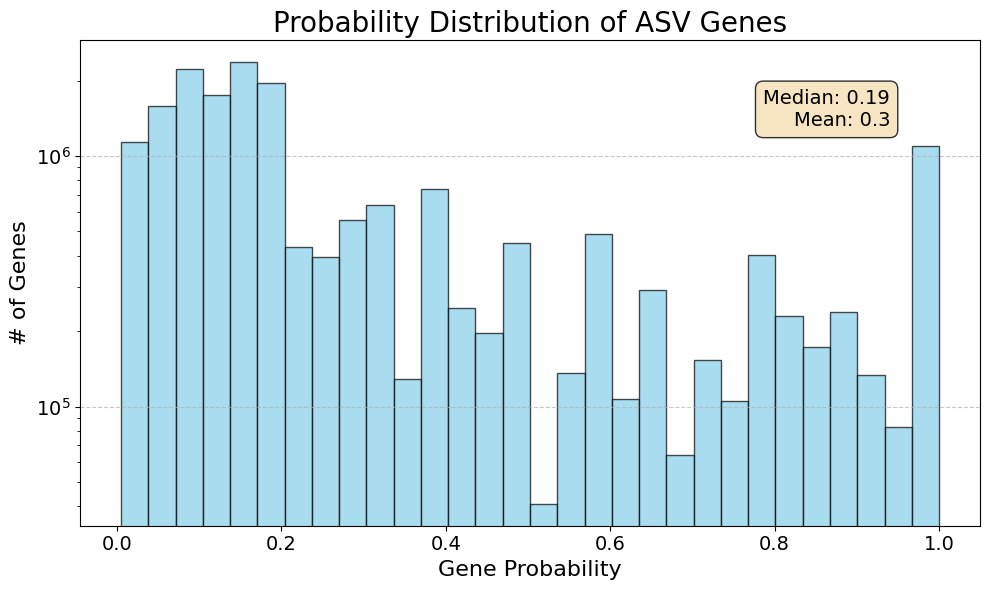

In [162]:
from numpy import array, where
from statistics import median, mean
from json import load

iterativeIDs = load(open("modeling_files/iterativeIDs.json", 'r'))
feature_probabilities = load(open("modeling_files/feature_probabilities.json", "r"))
genomes = ['Proteiniphilum.5', 'Proteiniphilum.4', 'Pseudomonas.1', 'Christensenellaceae_R-7_group.11', 'Thermovirga.4', 'Christensenellaceae_R-7_group.10', 'midas_g_36215.2', 'midas_g_12.1', 'midas_g_36215.3', 'Azoarcus.2', 'Alcaligenes.2', 'JGI-0000079-D21.1', 'Desulfovibrio.1', 'Leucobacter.1', 'Trichloromonas.1', 'midas_g_91392.1', 'Brevundimonas.2', 'Brevundimonas.3', 'Methanobacterium.4', 'Methanobacterium.5', 'Lentimicrobium.7', 'Pir4_lineage.1', 'Lentimicrobium.6', 'Methanobacterium.17', 'Methanobacterium.16', 'Ca_Cloacimonas.1', 'Pseudarcobacter.1', 'midas_g_94288.1', 'Sedimentibacter.3', 'Sedimentibacter.2', 'Lachnoclostridium.1', 'midas_g_98017.1', 'Bacteroides.2', 'Rhodobacter.1', 'Desulfosporosinus.1', 'Enterococcus.1', 'midas_g_25828.2', 'Methanothrix.1', 'midas_g_156.1', 'midas_g_110683.1', 'midas_g_75908.1', 'Aminivibrio.2', 'Alkaliphilus_oremlandii_OhILAs.1', 'midas_g_4325.2', 'Rhodococcus.1', 'Acinetobacter.1', 'Intestinibacter.1', 'Anaerosalibacter.2', 'Terrisporobacter.2', 'Dehalobacter.1', 'Syntrophomonas.1', 'Mangroviflexus.1', 'Sphingopyxis.5', 'Sphingopyxis.4', 'Enhydrobacter.1', 'midas_g_61343.1', 'LNR_A2-18.3', 'LNR_A2-18.2', 'Christensenellaceae_R-7_group.4', 'Christensenellaceae_R-7_group.5', 'Methanomassiliicoccus.1', 'midas_g_77817.1', 'Paraclostridium.1', 'midas_g_109927.1', 'Methanosarcina.2', 'Methanosarcina.3', 'Anaerovorax.1', 'midas_g_399.3', 'midas_g_399.2', 'midas_g_75.1', 'midas_g_116109.1', 'midas_g_2178.2', 'midas_g_249.1', 'Bacillus.6', 'Acetobacterium.2', 'Acetobacterium.3', 'Aquamicrobium.3', 'midas_g_6187.2', 'midas_g_6187.3', 'Aquamicrobium.2', 'midas_g_1251.1', 'Bosea.1', 'Clostridium_sensu_stricto_13.4', 'midas_g_669.1', 'Petrimonas.4', 'EBM-39.2', 'EBM-39.3', 'midas_g_7.1', 'Anaerocolumna.2', 'midas_g_36376.1', 'midas_g_93469.1', 'Sphaerochaeta.1', 'Pseudaminobacter.1', 'Angelakisella.1', 'Sphingopyxis.2', 'Sphingopyxis.3', 'Parvibaculum.1', 'Pannonibacter.1', 'Desulfomicrobium.1', 'Comamonas.1', 'midas_g_109803.1', 'Fonticella.1', 'Christensenellaceae_R-7_group.3', 'Christensenellaceae_R-7_group.2', 'midas_g_112829.1', 'midas_g_3595.1', 'midas_g_2296.1', 'Dysgonomonas.1', 'midas_g_119665.1', 'Camelimonas.2', 'Dechlorobacter.1', 'Syntrophobacter.1', 'Methanosarcina.4', 'Anaerovorax.6', 'Anaerovorax.7', 'Bacillus.1', 'midas_g_31962.1', 'Desulfobulbus.1', 'Pelotomaculum.1', 'Intestinimonas.1', 'Afipia.1', 'Christensenellaceae_R-7_group.9', 'Erysipelothrix.1', 'Christensenellaceae_R-7_group.8', 'midas_g_10303.1', 'Thiopseudomonas.1', 'Fastidiosipila.1', 'midas_g_6187.4', 'Petrimonas.3', 'midas_g_97954.1', 'Petrimonas.2', 'Clostridium_sensu_stricto_13.3', 'Ca_Ovatusbacter.1', 'Clostridium_sensu_stricto_13.2', 'Thauera.1', 'Dethiobacter.2', 'HN-HF0106.1', 'Hydrogenophaga.2', 'Sulfurospirillum.2', 'Christensenellaceae_R-7_group.16', 'Thermovirga.3', 'Christensenellaceae_R-7_group.17', 'Thermovirga.2', 'Corynebacterium.1', 'midas_g_36215.5', 'midas_g_36215.4', 'midas_g_101467.1', 'Proteiniphilum.2', 'Proteiniphilum.3', 'Proteiniclasticum.1', 'Tissierella.2', 'Desulfovibrio.6', 'Desulfovibrio.7', 'midas_g_1799.2', 'Fermentimonas.2', 'Fermentimonas.3', 'midas_g_3409.2', 'Ruminiclostridium.2', 'Lentimicrobium.1', 'midas_g_8129.1', 'Methanobacterium.10', 'Aminiphilus.1', 'Methanobacterium.11', 'midas_g_90293.1', 'Ca_Phosphitivorax.1', 'midas_g_2901.1', 'UCG-009.2', 'midas_g_4042.1', 'midas_g_1220.1', 'Methanobacterium.3', 'Methanobacterium.2', 'Monoglobus.1', 'Sedimentibacter.4', 'Achromobacter.2', 'Sedimentibacter.5', 'Achromobacter.3', 'Colidextribacter.1', 'Romboutsia.1', 'midas_g_4301.2', 'Clostridium_sensu_stricto_1.1', 'Acetoanaerobium.1', 'midas_g_9269.2', 'midas_g_9269.3', 'Oscillibacter.2', 'Caproiciproducens.3', 'Caproiciproducens.2', 'Syner-01.1', 'midas_g_343.1', 'Pseudochelatococcus.1', 'Methanobacterium.9', 'Methanobacterium.8', 'midas_g_497.1', 'Smithella.1', 'Microbacterium.1', 'Stenotrophomonas.1', 'Ochrobactrum.2', 'Gordonia.2', 'Gordonia.3', 'Mycobacterium.2', 'Anaerostignum.1', 'Methanosarcina.1', 'Anaerovorax.2', 'Anaerovorax.3', 'midas_g_77817.2', 'midas_g_399.1', 'Tuzzerella.1', 'midas_g_2178.1', 'Syntrophorhabdus.1', 'midas_g_114295.1', 'Mesotoga.1', 'Bacillus.4', 'Bacillus.5', 'midas_g_6187.1', 'Aquamicrobium.1', 'midas_g_93128.1', 'Acetobacterium.1', 'Bosea.2', 'Desulfurispora.1', 'Erysipelothrix.4', 'Leptolinea.1', 'RBG-16-49-21.1', 'EBM-39.1', 'Anaerocolumna.1', 'midas_g_52.1', 'midas_g_669.2', 'midas_g_669.3', 'Chryseobacterium.1', 'midas_g_75908.3', 'midas_g_75908.2', 'DMER64.1', 'Epulopiscium.1', 'midas_g_5426.1', 'midas_g_4325.1', 'Aminivibrio.1', 'midas_g_92370.1', 'Sphaerochaeta.4', 'Acinetobacter.2', 'Acinetobacter.3', 'Terrisporobacter.1', 'Anaerosalibacter.1', 'Actinomyces.1', 'LNR_A2-18.1', 'Christensenellaceae_R-7_group.7', 'Christensenellaceae_R-7_group.6', 'Thermobrachium.1', 'Ca_Cloacimonas.2', 'Methanobacterium.20', 'Sedimentibacter.1', 'midas_g_30443.1', 'midas_g_94288.2', 'Lachnoclostridium.3', 'Lachnoclostridium.2', 'midas_g_98017.2', 'Syner-01.4', 'Christensenellaceae_R-7_group.18', 'Syner-01.5', 'midas_g_33659.1', 'midas_g_765.1', 'Clostridium_sensu_stricto_11.1', 'midas_g_114992.1', 'midas_g_107376.1', 'Ca_Soleaferrea.1', 'Bacteroides.1', 'Methanoculleus.1', 'midas_g_25828.1', 'Enterococcus.3', 'Soehngenia.1', 'Enterococcus.2', 'Clostridium_sensu_stricto_7.1', 'Stenotrophomonas.4', 'midas_g_2455.1', 'midas_g_515.1', 'midas_g_4387.1', 'Christensenellaceae_R-7_group.12', 'Christensenellaceae_R-7_group.13', 'midas_g_36215.1', 'Pseudomonas.3', 'Pseudomonas.2', 'midas_g_94069.1', 'Alcaligenes.1', 'Azoarcus.1', 'Ercella.1', 'Dehalobacterium.1', 'midas_g_82137.1', 'Desulfitibacter.1', 'Desulfovibrio.2', 'Desulfovibrio.3', 'Methanobacterium.7', 'Methanobacterium.6', 'midas_g_91392.2', 'Brevundimonas.1', 'Andreesenia_angusta.1', 'Methanobacterium.14', 'Methanobacterium.15', 'Lentimicrobium.4', 'Lentimicrobium.5', 'Achromobacter.1', 'midas_g_5574.1', 'Sedimentibacter.7', 'Sedimentibacter.6', 'Romboutsia.3', 'Colidextribacter.2', 'Romboutsia.2', 'Colidextribacter.3', 'Monoglobus.2', 'midas_g_9023.1', 'Acetoanaerobium.2', 'midas_g_9269.1', 'Oscillibacter.1', 'midas_g_4301.1', 'Clostridium_sensu_stricto_1.2', 'Caproiciproducens.1', 'Lachnoclostridium.4', 'Syner-01.3', 'Syner-01.2', 'midas_g_102931.1', 'Enterococcus.4', 'Rummeliibacillus.1', 'Lentimicrobium.9', 'Lentimicrobium.8', 'Methanobacterium.19', 'Methanobacterium.18', 'Stenotrophomonas.2', 'Stenotrophomonas.3', 'Ochrobactrum.1', 'midas_g_19.1', 'Hyphomonas.1', 'Mycobacterium.1', 'Gordonia.1', 'Sporanaerobacter.1', 'Amaricoccus.1', 'Christensenellaceae_R-7_group.15', 'Thermovirga.1', 'Christensenellaceae_R-7_group.14', 'Pseudomonas.4', 'Pseudomonas.5', 'Hydrogenophaga.1', 'Sulfurospirillum.1', 'Proteiniphilum.1', 'midas_g_115459.1', 'midas_g_21833.1', 'Levilinea.1', 'midas_g_1799.1', 'Fermentimonas.1', 'Tissierella.1', 'midas_g_83754.1', 'Desulfovibrio.5', 'Desulfovibrio.4', 'midas_g_112760.1', 'midas_g_3409.1', 'Ruminiclostridium.1', 'Methanobacterium.13', 'Methanobacterium.12', 'midas_g_114252.1', 'Lentimicrobium.3', 'Lentimicrobium.2', 'IMCC26207.1', 'Methanobacterium.1', 'UCG-009.1', 'Dysgonomonas.2', 'midas_g_49937.1', 'Anaerovorax.5', 'Turicibacter.1', 'Anaerovorax.4', 'Camelimonas.1', 'Clostridium_sensu_stricto_5.1', 'midas_g_76594.1', 'Bacillus.3', 'Bacillus.2', 'Thiobacillus.1', 'Proteiniborus.1', 'Pusillimonas.1', 'midas_g_531.1', 'Pelotomaculum.2', 'Desulfobulbus.2', 'Desulfobulbus.3', 'midas_g_112372.1', 'Erysipelothrix.2', 'Erysipelothrix.3', 'Ca_Caldatribacterium.1', 'Brooklawnia.1', 'midas_g_15299.1', 'midas_g_97954.3', 'midas_g_669.5', 'Petrimonas.1', 'midas_g_97954.2', 'midas_g_669.4', 'Dethiobacter.1', 'Clostridium_sensu_stricto_13.1', 'midas_g_75908.4', 'midas_g_269.1', 'midas_g_100.1', 'Taibaiella.1', 'midas_g_2022.1', 'Sphaerochaeta.3', 'Sphaerochaeta.2', 'Stappia.1', 'midas_g_1981.1', 'Sphingopyxis.1', 'NK4A214_group.1', 'midas_g_93666.1', 'Fonticella.2', 'Christensenellaceae_R-7_group.1']

ASV_gene_probs = {}
missing = []
for asv_md5, prob in feature_probabilities.items():
    # print(gene, prob)
    asv = iterativeIDs.get(asv_md5, None)
    if asv is None:
        missing.append(asv_md5)
        continue
    ASV_gene_probs.setdefault(asv, {})
    ASV_gene_probs[asv].update(prob)

print(len(missing), "undefined iterative ASVs", missing)

# print(max([max(ps) for ps in ASV_gene_probs.values()]))
probs = {asv: array(list(content.values())) #/ sum(list(content.values()))
                for asv, content in ASV_gene_probs.items()}
# print(max([max(ps) for ps in probs.values()]))
probs = {asv: where(prob < 1e-5, 0, prob) for asv, prob in probs.items()}

# display(list(ASV_gene_probs.keys()))
probabilities = []
# missing = []
for asv, prob in probs.items():
    # print(max(prob))
    probabilities.extend(list(prob))
probabilities = array(probabilities)
print(len(probabilities[probabilities < 0.5])/len(probabilities))

missing = set(genomes).symmetric_difference(set(probs.keys()))
print("missing", len(missing), missing)

from numpy import mean, std 
print("max:", max(probabilities), "min:", min(probabilities),
        "mean:", mean(probabilities), "+/-", std(probabilities))

from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(probabilities, bins=30, edgecolor='black', color='skyblue', alpha=0.7)

# Coordinates: (x, y) in axes fraction (0=left/bottom, 1=right/top)
ax = plt.gca()
title_font = 20
axis_font = 14
plt.text(0.9, 0.9,
    f'Median: {round(median(probabilities), 2)}\nMean: {round(mean(probabilities), 2)}',
    transform=ax.transAxes,
    fontsize=axis_font,
    # fontweight='bold',
    # color='darkred',
    horizontalalignment='right',     # align text to the right
    verticalalignment='top',         # align text to the top
    bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.8)
)

# Styling
plt.title('Probability Distribution of ASV Genes', fontsize=title_font)
plt.xlabel('Gene Probability', fontsize=16)
plt.ylabel('# of Genes', fontsize=16)
plt.xticks(fontsize=axis_font)
plt.yticks(fontsize=axis_font)
plt.yscale('log')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("modeling_files/feature_probabilities.png")
plt.show()